### Mount Google Drive

To access files stored in your Google Drive, you need to mount it in each Colab session. The following code will prompt you to authenticate and grant Colab access to your Drive.

Thesis Empirical Design

Cell 1: Connect to drive

In [16]:
# ================================================================
# CELL 1 — SETUP + MASTER PANEL CONSTRUCTION
# ================================================================

# Mount Google Drive so we can access all data files stored there
from google.colab import drive
import os
import subprocess
drive.mount('/content/drive')
# Install Excel-reading libraries needed for .xls and .xlsx files
subprocess.run(["pip", "install", "xlrd", "openpyxl", "-q"], capture_output=True)

# Core libraries: pandas for data manipulation, numpy for math,
# matplotlib for figures, statsmodels for regressions, scipy for stats tests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── PATHS ────────────────────────────────────────────────────────
# Define folder paths so every subsequent cell knows where to read
# and write data without hardcoding full paths repeatedly
BASE_DIR   = "/content/drive/MyDrive/NEER THESIS_LAST3"
CLEAN_DIR  = os.path.join(BASE_DIR, "clean_data_last3")      # cleaned input files
OUTPUT_DIR = os.path.join(BASE_DIR, "output_data_last59")     # figures and tables
os.makedirs(OUTPUT_DIR, exist_ok=True)                        # create if not exists

# ── VIRIDIS PALETTE ──────────────────────────────────────────────
# Five fixed colours from the viridis colormap used consistently
# across every figure in the thesis for visual coherence
V1    = "#440154"   # Dark Purple
V2    = "#3B528B"   # Steel Blue
V3    = "#21908C"   # Teal
V4    = "#5DC863"   # Green
V5    = "#FDE725"   # Yellow
VGREY = "#BBBBBB"   # Neutral grey — used for insignificant bars

# Apply a unified academic figure style across all plots:
# serif font, no top/right spines, light dashed grid, white background
plt.rcParams.update({
    "font.family"        : "serif",
    "font.size"          : 10,
    "axes.titlesize"     : 11,
    "axes.labelsize"     : 10,
    "xtick.labelsize"    : 9,
    "ytick.labelsize"    : 9,
    "legend.fontsize"    : 9,
    "figure.dpi"         : 150,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.grid"          : True,
    "grid.alpha"         : 0.25,
    "grid.linestyle"     : "--",
    "axes.facecolor"     : "white",
    "figure.facecolor"   : "white",
})

# ── HELPER FUNCTIONS ─────────────────────────────────────────────
# Converts a p-value into a significance star string (used in all tables)
def sig_label(p):
    if pd.isna(p) or p is None: return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# Saves every figure in both PDF (for thesis) and PNG (for preview)
def save_fig(fig, name):
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.png"), bbox_inches="tight", dpi=200)
    print(f"\nSaved: {name}.pdf / .png")

# Normalises any date series to the first day of its month,
# ensuring all datasets align on the same monthly frequency
def to_month_start(series):
    return pd.to_datetime(series).dt.to_period("M").dt.to_timestamp()

# ── CTOT CONSTRUCTION (from CTOT_all_countries_wide.csv) ──────────
# Maps IMF country names (as they appear in the raw CTOT file)
# to the standardised country names used throughout the panel
CTOT_NAME_MAP = {
    "Argentina"                                                          : "Argentina",
    "Australia"                                                          : "Australia",
    "Belgium"                                                            : "Belgium",
    "Brazil"                                                             : "Brazil",
    "Canada"                                                             : "Canada",
    "Chile"                                                              : "Chile",
    "China, People's Republic of"                                        : "China",
    "Colombia"                                                           : "Colombia",
    "Denmark"                                                            : "Denmark",
    "Finland"                                                            : "Finland",
    "France"                                                             : "France",
    "Germany"                                                            : "Germany",
    "Hong Kong Special Administrative Region, People's Republic of China": "Hong Kong",
    "Hungary"                                                            : "Hungary",
    "India"                                                              : "India",
    "Indonesia"                                                          : "Indonesia",
    "Israel"                                                             : "Israel",
    "Italy"                                                              : "Italy",
    "Japan"                                                              : "Japan",
    "Malaysia"                                                           : "Malaysia",
    "Mexico"                                                             : "Mexico",
    "Netherlands, The"                                                   : "Netherlands",
    "Norway"                                                             : "Norway",
    "Peru"                                                               : "Peru",
    "Philippines"                                                        : "Philippines",
    "Poland, Republic of"                                                : "Poland",
    "Portugal"                                                           : "Portugal",
    "Russian Federation"                                                 : "Russia",
    "Saudi Arabia"                                                       : "Saudi Arabia",
    "South Africa"                                                       : "South Africa",
    "Korea, Republic of"                                                 : "South Korea",
    "Spain"                                                              : "Spain",
    "Sweden"                                                             : "Sweden",
    "Switzerland"                                                        : "Switzerland",
    "Thailand"                                                           : "Thailand",
    "Türkiye, Republic of"                                               : "Turkey",
    "United Kingdom"                                                     : "United Kingdom",
    "United States"                                                      : "United States",
}

# Load the raw CTOT wide file and restrict to the 2000-2023 sample window
ctot_raw = pd.read_csv(os.path.join(CLEAN_DIR, "CTOT_all_countries_wide.csv"))
ctot_raw["DATE"] = pd.to_datetime(ctot_raw["DATE"])
ctot_raw = ctot_raw[
    (ctot_raw["DATE"] >= "2000-01-01") &
    (ctot_raw["DATE"] <= "2023-12-31")
].copy()

# Keep only columns that match our 38-country sample and rename them
ctot_sub = ctot_raw[["DATE"] + [c for c in CTOT_NAME_MAP if c in ctot_raw.columns]].copy()
ctot_sub = ctot_sub.rename(columns=CTOT_NAME_MAP)

# Reshape from wide (one column per country) to long (one row per country-month)
# and compute the monthly percentage change in the CTOT index
ctot_long = ctot_sub.melt(
    id_vars="DATE", var_name="country", value_name="ctot_index"
).rename(columns={"DATE": "date"})
ctot_long["date"] = to_month_start(ctot_long["date"])
ctot_long = ctot_long.sort_values(["country", "date"])
ctot_long["ctot_ret"] = (ctot_long.groupby("country")["ctot_index"]
                         .pct_change() * 100)

# Build a country-level CTOT summary:
# ctot_exposure = -(mean index - 100): positive means net commodity exporter,
# negative means net commodity importer (sign flip because raw series is import-weighted)
# ctot_exposure_z = standardised version used in regression interactions
ctot_country = ctot_long.groupby("country").agg(
    ctot_mean=("ctot_index", "mean")
).reset_index()
ctot_country["ctot_exposure"]   = -(ctot_country["ctot_mean"] - 100)
ctot_country["ctot_exposure_z"] = (
    (ctot_country["ctot_exposure"] - ctot_country["ctot_exposure"].mean())
    / ctot_country["ctot_exposure"].std()
)

print("✓ CTOT built from CTOT_all_countries_wide.csv")

# ── MASTER PANEL CONSTRUCTION ─────────────────────────────────────
# The 38 countries forming our final sample, selected on the basis of
# NEER data availability and at least 10 years of continuous coverage
TARGET_COUNTRIES = [
    "Argentina", "Australia", "Belgium", "Brazil", "Canada",
    "Chile", "China", "Colombia", "Denmark", "Finland",
    "France", "Germany", "Hong Kong", "Hungary", "India",
    "Indonesia", "Israel", "Italy", "Japan", "Malaysia",
    "Mexico", "Netherlands", "Norway", "Peru", "Philippines",
    "Poland", "Portugal", "Russia", "Saudi Arabia", "South Africa",
    "South Korea", "Spain", "Sweden", "Switzerland",
    "Thailand", "Turkey", "United Kingdom", "United States",
]
TARGET_SET = set(TARGET_COUNTRIES)  # set for fast membership testing

print("Loading clean monthly files...")

# Load each monthly file produced by the data-prep notebook
neer_m      = pd.read_csv(os.path.join(CLEAN_DIR, "neer_monthly_clean.csv"),             parse_dates=["date"])
gpr_g       = pd.read_csv(os.path.join(CLEAN_DIR, "gpr_monthly_global_clean.csv"),       parse_dates=["date"])
gpr_c       = pd.read_csv(os.path.join(CLEAN_DIR, "gpr_monthly_country_clean.csv"),      parse_dates=["date"])
brent_m     = pd.read_csv(os.path.join(CLEAN_DIR, "brent_monthly_clean.csv"),            parse_dates=["date"])
vix_m       = pd.read_csv(os.path.join(CLEAN_DIR, "vix_monthly_clean.csv"),              parse_dates=["date"])
kaopen_m    = pd.read_csv(os.path.join(CLEAN_DIR, "kaopen_monthly_clean.csv"),           parse_dates=["date"])
fx_m        = pd.read_csv(os.path.join(CLEAN_DIR, "fx_reserves_monthly_clean.csv"),      parse_dates=["date"])
gvc_tiva_m  = pd.read_csv(os.path.join(CLEAN_DIR, "gvc_tiva_monthly_clean.csv"),         parse_dates=["date"])
ewn_m       = pd.read_csv(os.path.join(CLEAN_DIR, "ewn_monthly_clean.csv"),              parse_dates=["date"])
stdebt_m    = pd.read_csv(os.path.join(CLEAN_DIR, "st_debt_reserves_monthly_clean.csv"), parse_dates=["date"])
inf_m       = pd.read_csv(os.path.join(CLEAN_DIR, "inflation_monthly_clean.csv"),        parse_dates=["date"])
nei_m       = pd.read_csv(os.path.join(CLEAN_DIR, "net_energy_monthly_clean.csv"),       parse_dates=["date"])
gdp_m       = pd.read_csv(os.path.join(CLEAN_DIR, "gdp_growth_monthly_clean.csv"),       parse_dates=["date"])
fb_m        = pd.read_csv(os.path.join(CLEAN_DIR, "fiscal_balance_monthly_clean.csv"),   parse_dates=["date"])
to_m        = pd.read_csv(os.path.join(CLEAN_DIR, "trade_openness_monthly_clean.csv"),   parse_dates=["date"])
irr_m       = pd.read_csv(os.path.join(CLEAN_DIR, "irr_regime_monthly_clean.csv"),       parse_dates=["date"])

# Normalise every date column to month-start so all merges align correctly
for df in [neer_m, gpr_g, gpr_c, brent_m, vix_m,
           kaopen_m, fx_m, gvc_tiva_m, ewn_m, stdebt_m,
           inf_m, nei_m, gdp_m, fb_m, to_m, irr_m, ctot_long]:
    df["date"] = to_month_start(df["date"])

print("Merging...")

# Start the panel from NEER — our dependent variable —
# keeping only the 38 target countries
panel = neer_m[["date", "country", "neer", "neer_ret_m"]].copy()
panel = panel[panel["country"].isin(TARGET_SET)].copy()

# Merge global market controls: GPR indices, Brent crude, VIX
# These are the same for all countries in a given month (no country key)
panel = panel.merge(gpr_g[["date", "gpr_global", "gpr_act", "gpr_threat"]], on="date", how="left")
panel = panel.merge(
    brent_m[["date", "brent_usd", "brent_ret_m"]].rename(columns={"brent_ret_m": "brent_ret"}),
    on="date", how="left")
panel = panel.merge(vix_m[["date", "vix_avg"]], on="date", how="left")

# Merge country-specific GPR index (varies by both country and month)
panel = panel.merge(
    gpr_c.rename(columns={"gpr_country": "gpr_country_specific"}),
    on=["date", "country"], how="left")

# Merge all structural variables one by one on [date, country]
# Each represents a country characteristic that may condition GPR transmission
for df, cols in [
    (kaopen_m,   ["date", "country", "kaopen"]),              # Chinn-Ito capital account openness
    (fx_m,       ["date", "country", "fx_reserves_months"]),  # FX reserves in months of imports
    (inf_m,      ["date", "country", "inflation_cpi"]),        # CPI inflation rate
    (nei_m,      ["date", "country", "net_energy_imports"]),   # net energy imports (% of energy use)
    (gdp_m,      ["date", "country", "gdp_growth"]),           # real GDP growth
    (fb_m,       ["date", "country", "fiscal_balance"]),       # fiscal balance (% GDP)
    (to_m,       ["date", "country", "trade_openness"]),       # trade openness (% GDP)
    (irr_m,      ["date", "country", "irr_coarse", "irr_flexible"]),  # exchange rate regime
    (gvc_tiva_m, ["date", "country", "gvc_backward_tiva"]),   # GVC backward linkage (TiVA)
    (stdebt_m,   ["date", "country", "st_debt_reserves"]),    # short-term debt / reserves
]:
    panel = panel.merge(df[cols], on=["date", "country"], how="left")

# Merge all EWN external balance sheet variables (assets, liabilities, IIP, etc.)
# collected in a single wide file; all columns except date/country are included
ewn_cols = [c for c in ewn_m.columns if c not in ["date", "country"]]
panel = panel.merge(ewn_m[["date", "country"] + ewn_cols], on=["date", "country"], how="left")

# Merge time-invariant CTOT structural exposure (one value per country)
# and time-varying monthly CTOT index and return
panel = panel.merge(
    ctot_country[["country", "ctot_exposure", "ctot_exposure_z"]],
    on="country", how="left")
panel = panel.merge(
    ctot_long[["date", "country", "ctot_index", "ctot_ret"]],
    on=["date", "country"], how="left")

# ── SAMPLE FILTER ─────────────────────────────────────────────────
# Restrict to the 2000-2023 window and target country set
panel = panel[
    (panel["date"] >= "2000-01-01") &
    (panel["date"] <= "2023-12-31") &
    (panel["country"].isin(TARGET_SET))
].copy()

# Drop any country that does not have at least 120 months (10 years)
# of non-missing data across the four core variables,
# ensuring a minimum time-series depth for meaningful estimation
core_vars = ["neer", "gpr_global", "brent_usd", "vix_avg"]
panel["_ok"] = panel[core_vars].notna().all(axis=1)
n_ok    = (panel[panel["_ok"]].groupby("country")["date"]
           .count().reset_index().rename(columns={"date": "n_months"}))
keep    = n_ok[n_ok["n_months"] >= 120]["country"].tolist()
dropped = sorted(TARGET_SET - set(keep))
panel   = panel[panel["country"].isin(keep)].drop(columns=["_ok"])
panel   = panel.sort_values(["country", "date"]).reset_index(drop=True)

# Sanity check: there should be exactly one row per country-month
dups = panel.duplicated(subset=["country", "date"]).sum()
if dups > 0:
    raise ValueError(f"Duplicate country-date rows: {dups}")

# ── SCALE + RENAME ────────────────────────────────────────────────
# Convert NEER log returns from decimals to percentage points
# (e.g. 0.002 → 0.2 pp) so regression coefficients are interpretable
if panel["neer_ret_m"].abs().max() < 1:
    panel["neer_ret_m"] = panel["neer_ret_m"] * 100

# Rename EWN de facto openness to the short name used in Cell 2 figures/tables,
# then keep the original EWN name as an alias so Cell 3+ regressions still find it
panel = panel.rename(columns={
    "ewn_de_facto_fin_open_pct_gdp": "financial_openness_de_facto"
})
panel["ewn_de_facto_fin_open_pct_gdp"] = panel["financial_openness_de_facto"]

# ── SAVE ─────────────────────────────────────────────────────────
# Write the fully merged panel to disk so all subsequent cells
# can reload it independently without re-running the merge
panel.to_csv(os.path.join(CLEAN_DIR, "master_panel_38countries.csv"), index=False)

# ── LOAD PANEL ────────────────────────────────────────────────────
# Reload from disk to confirm the saved file is valid and
# to set the canonical in-memory `panel` object for all later cells
panel = pd.read_csv(
    os.path.join(CLEAN_DIR, "master_panel_38countries.csv"),
    parse_dates=["date"]
)

print("=" * 65)
print("  CELL 1 COMPLETE — SETUP")
print("=" * 65)
print(f"  Panel     : {panel.shape}")
print(f"  Countries : {panel['country'].nunique()}")
if dropped:
    print(f"  Dropped   : {dropped}")
print(f"  Months    : {panel['date'].nunique()}")
print(f"  Output    : {OUTPUT_DIR}")
print("=" * 65)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ CTOT built from CTOT_all_countries_wide.csv
Loading clean monthly files...
Merging...
  CELL 1 COMPLETE — SETUP
  Panel     : (10944, 48)
  Countries : 38
  Months    : 288
  Output    : /content/drive/MyDrive/NEER THESIS_LAST3/output_data_last59


Cell 2: Descriptive Statistics

  CELL 2 — DESCRIPTIVE STATISTICS
  GPR-Act  85th pct: 153.2 (44 stress months / country)
  GPR-Thr  85th pct: 135.0
  Normal months    : 244 / country

  TABLE 1 — SUMMARY STATISTICS
  Variable                                    N     Mean   Median      Std      Min      Max    Skew
  ─────────────────────────────────────────────────────────────────────────────────────────────
  NEER log return (pp)                    10906   -0.124    0.028    2.676  -81.892   23.467  -6.766
  GPR Global                              10944  105.452   92.440   51.994   45.060  512.530   4.280
  GPR Acts                                10944  107.904   88.095   84.559   28.450  854.070   5.482
  GPR Threats                             10944  105.097   94.415   45.004   44.360  403.710   2.914
  VIX (monthly avg)                       10944   20.030   17.975    8.135   10.125   62.282   1.998
  FX reserves (months of imports)         10908    5.819    4.592    5.434    0.364   37.374   2.172
  Fiscal bala

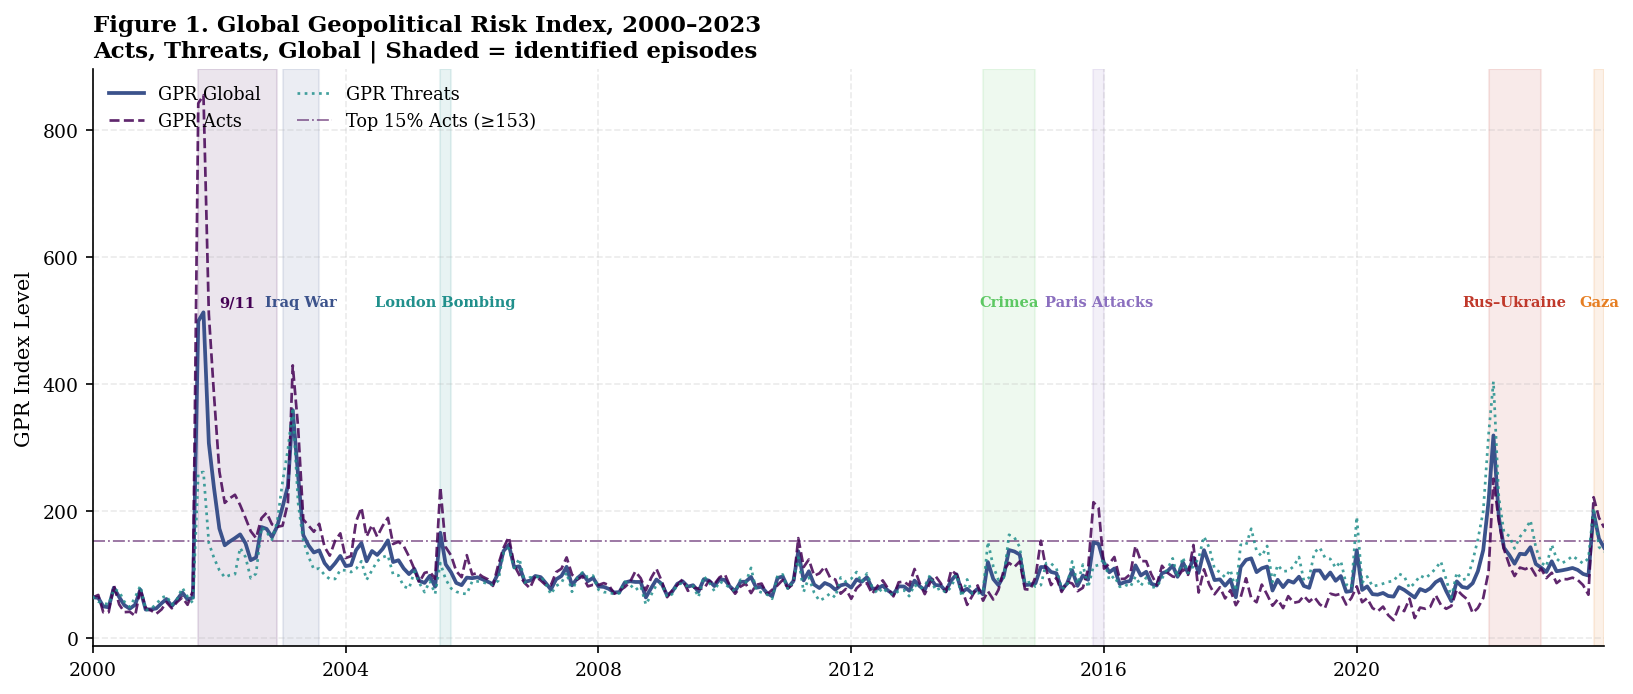


Saved: fig2_annex_neer_distribution.pdf / .png


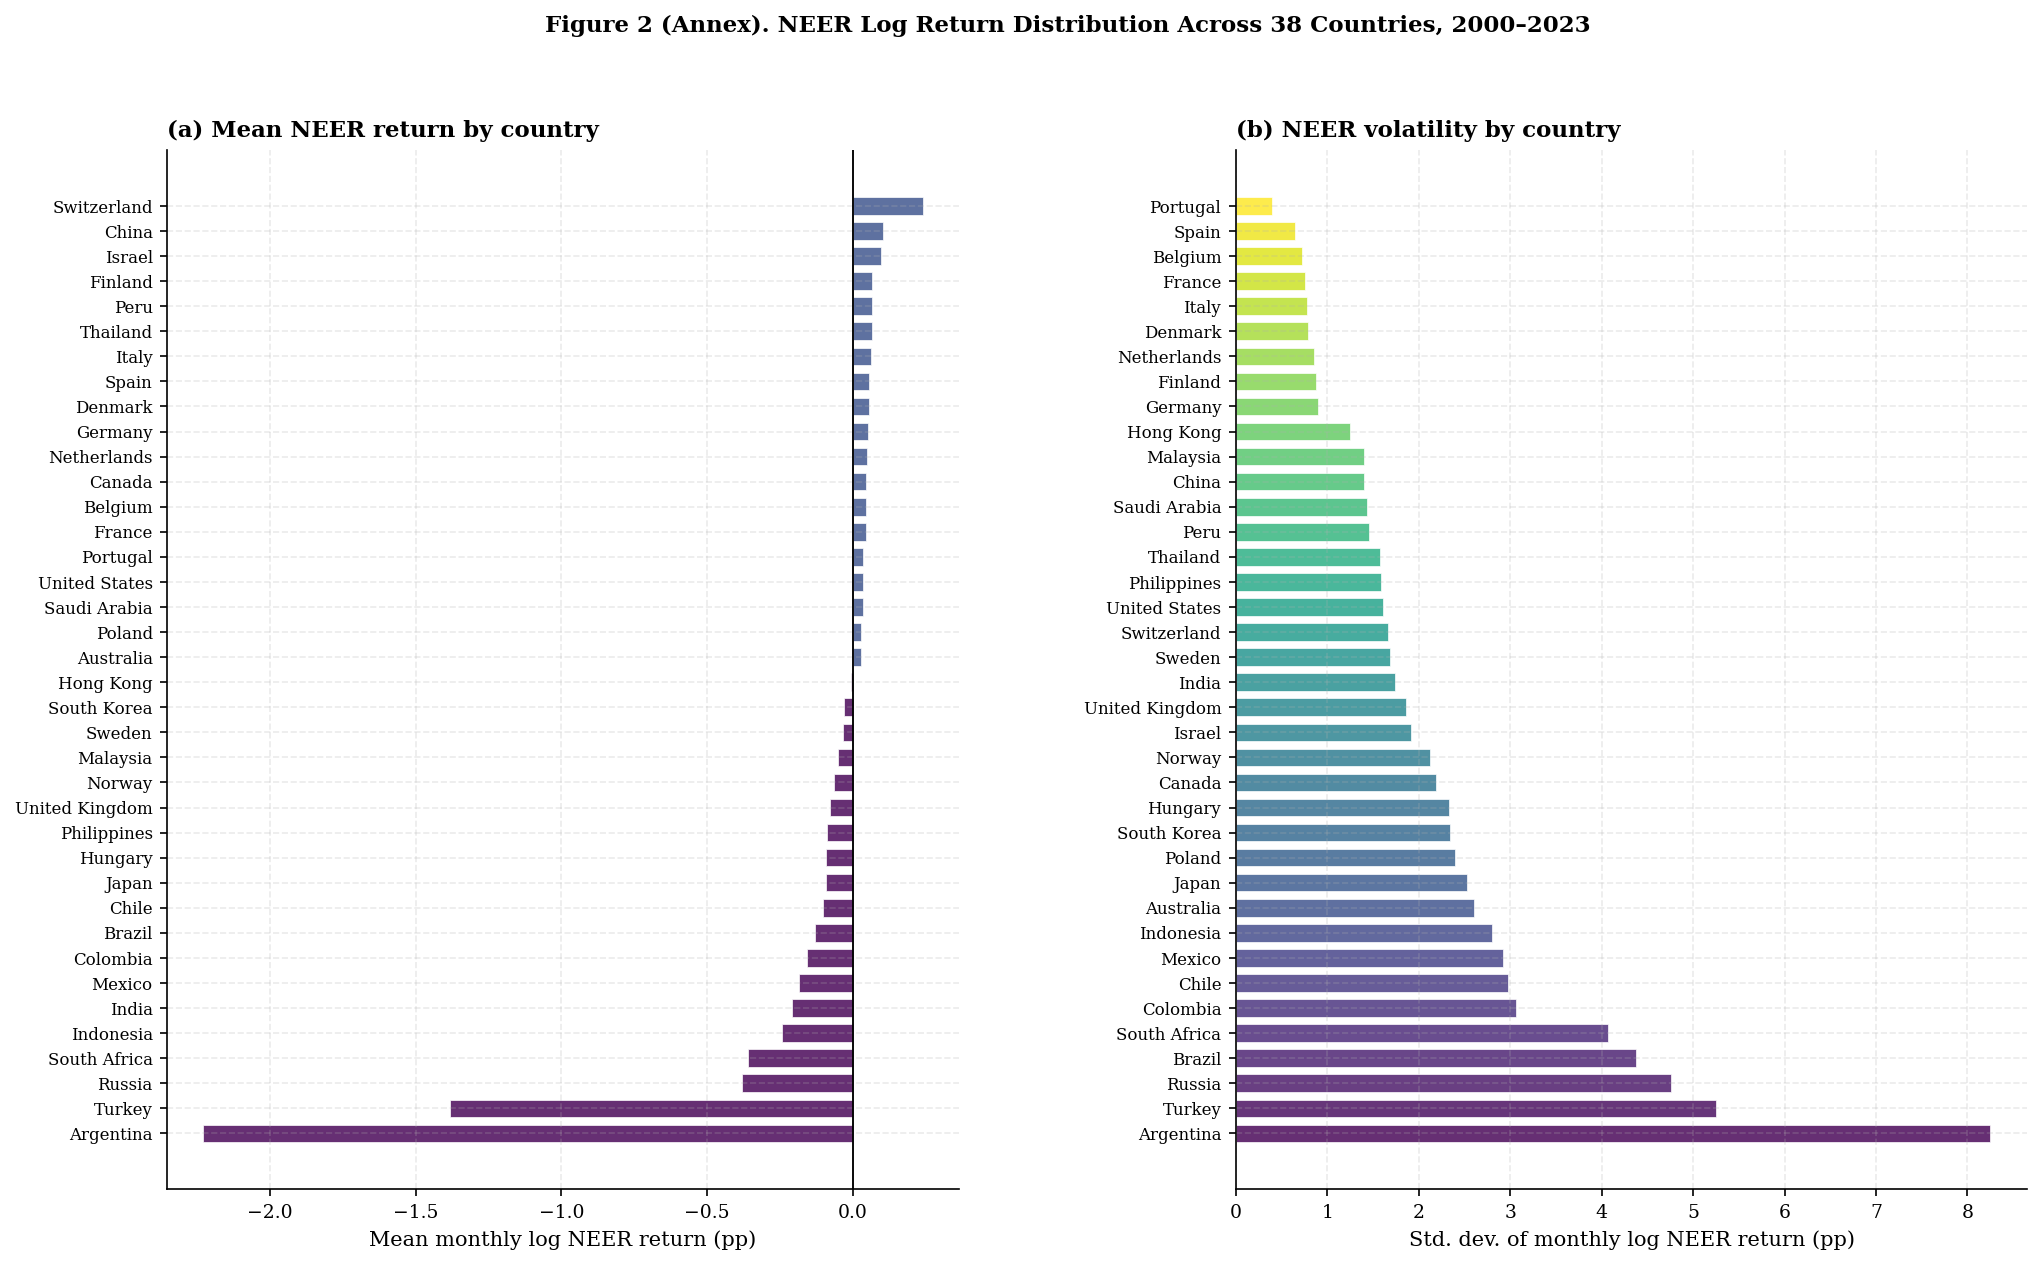


  VOLATILITY TESTS:
  GPR-Act  Levene: F=8.032 p=0.0046*** | Mean ratio=1.079x
  GPR-Thr  Levene: F=4.011 p=0.0452** | Mean ratio=0.959x

Saved: fig4a_volatility_amplification.pdf / .png


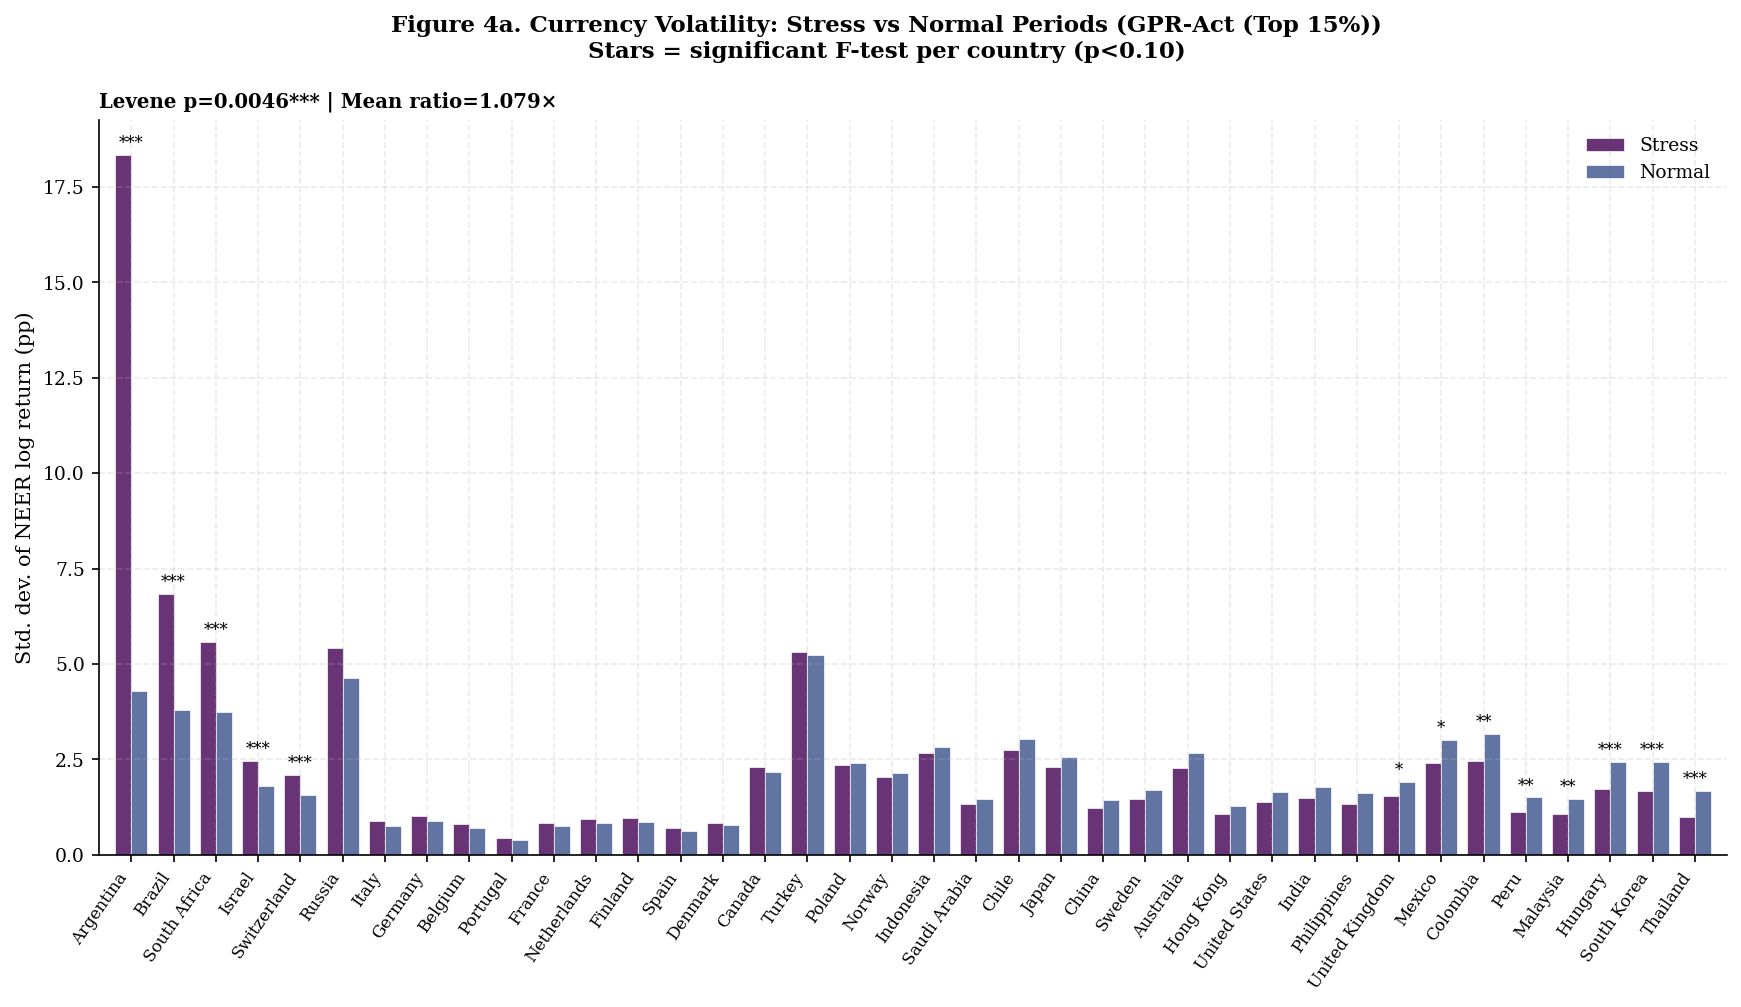


Saved: fig4b_volatility_amplification.pdf / .png


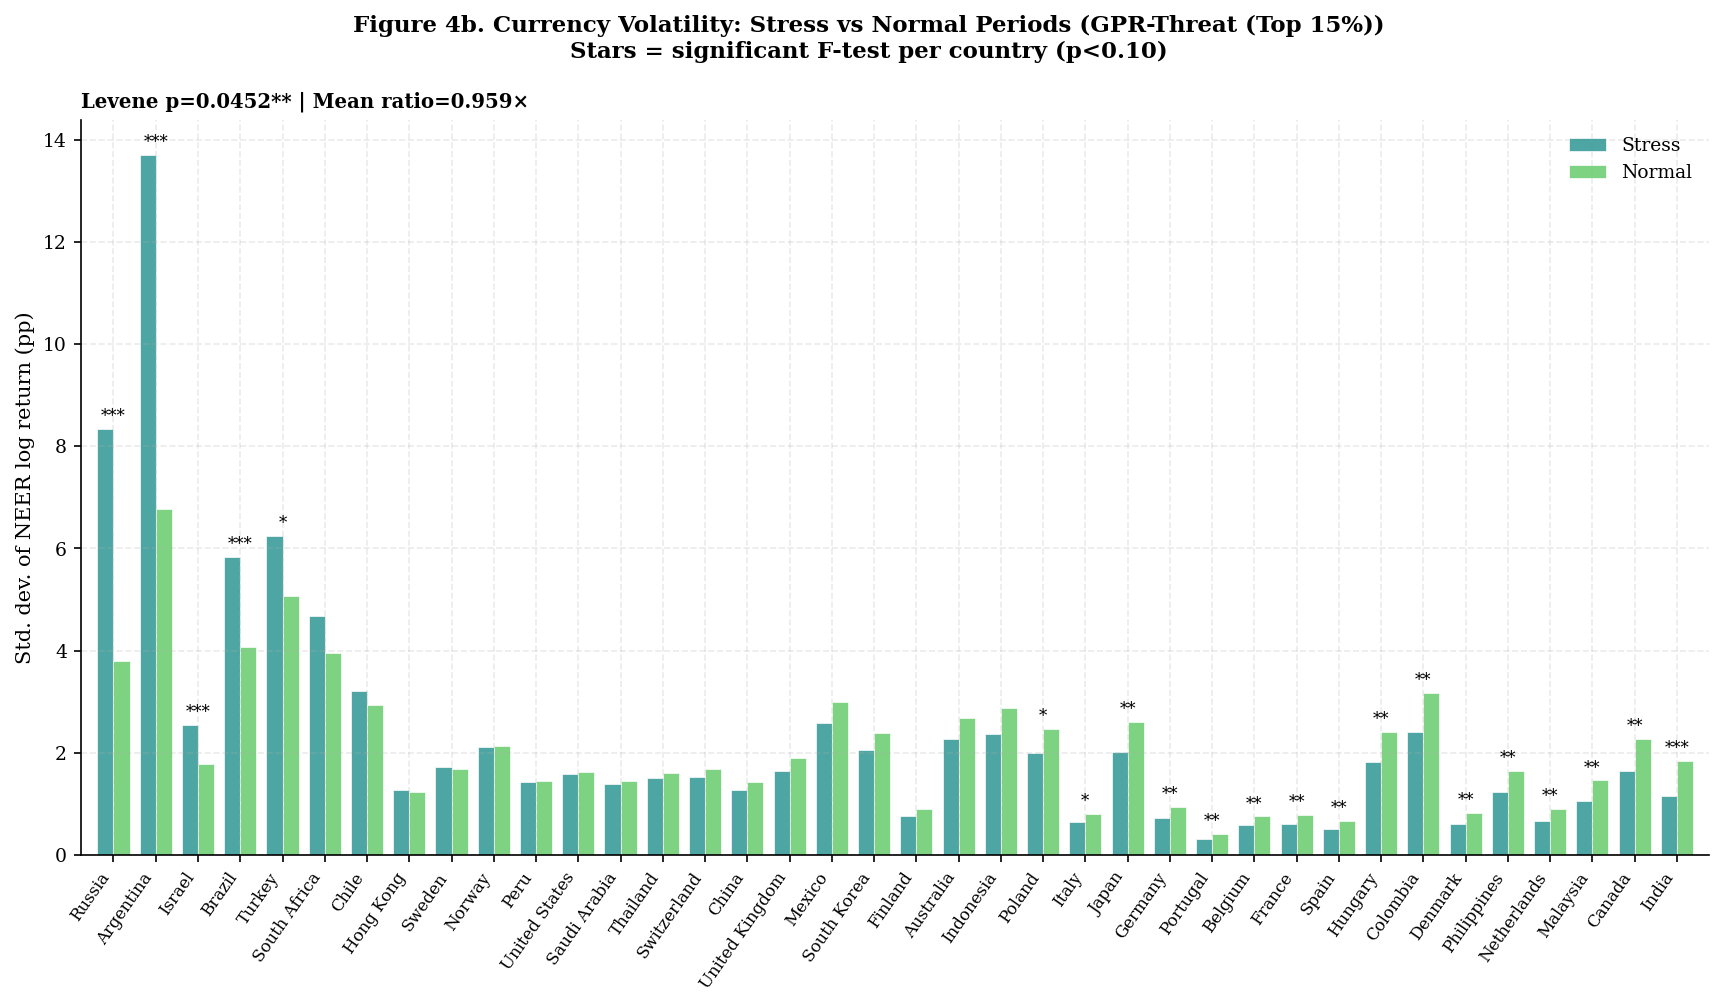


Saved: fig4_1_correlation_matrix.pdf / .png


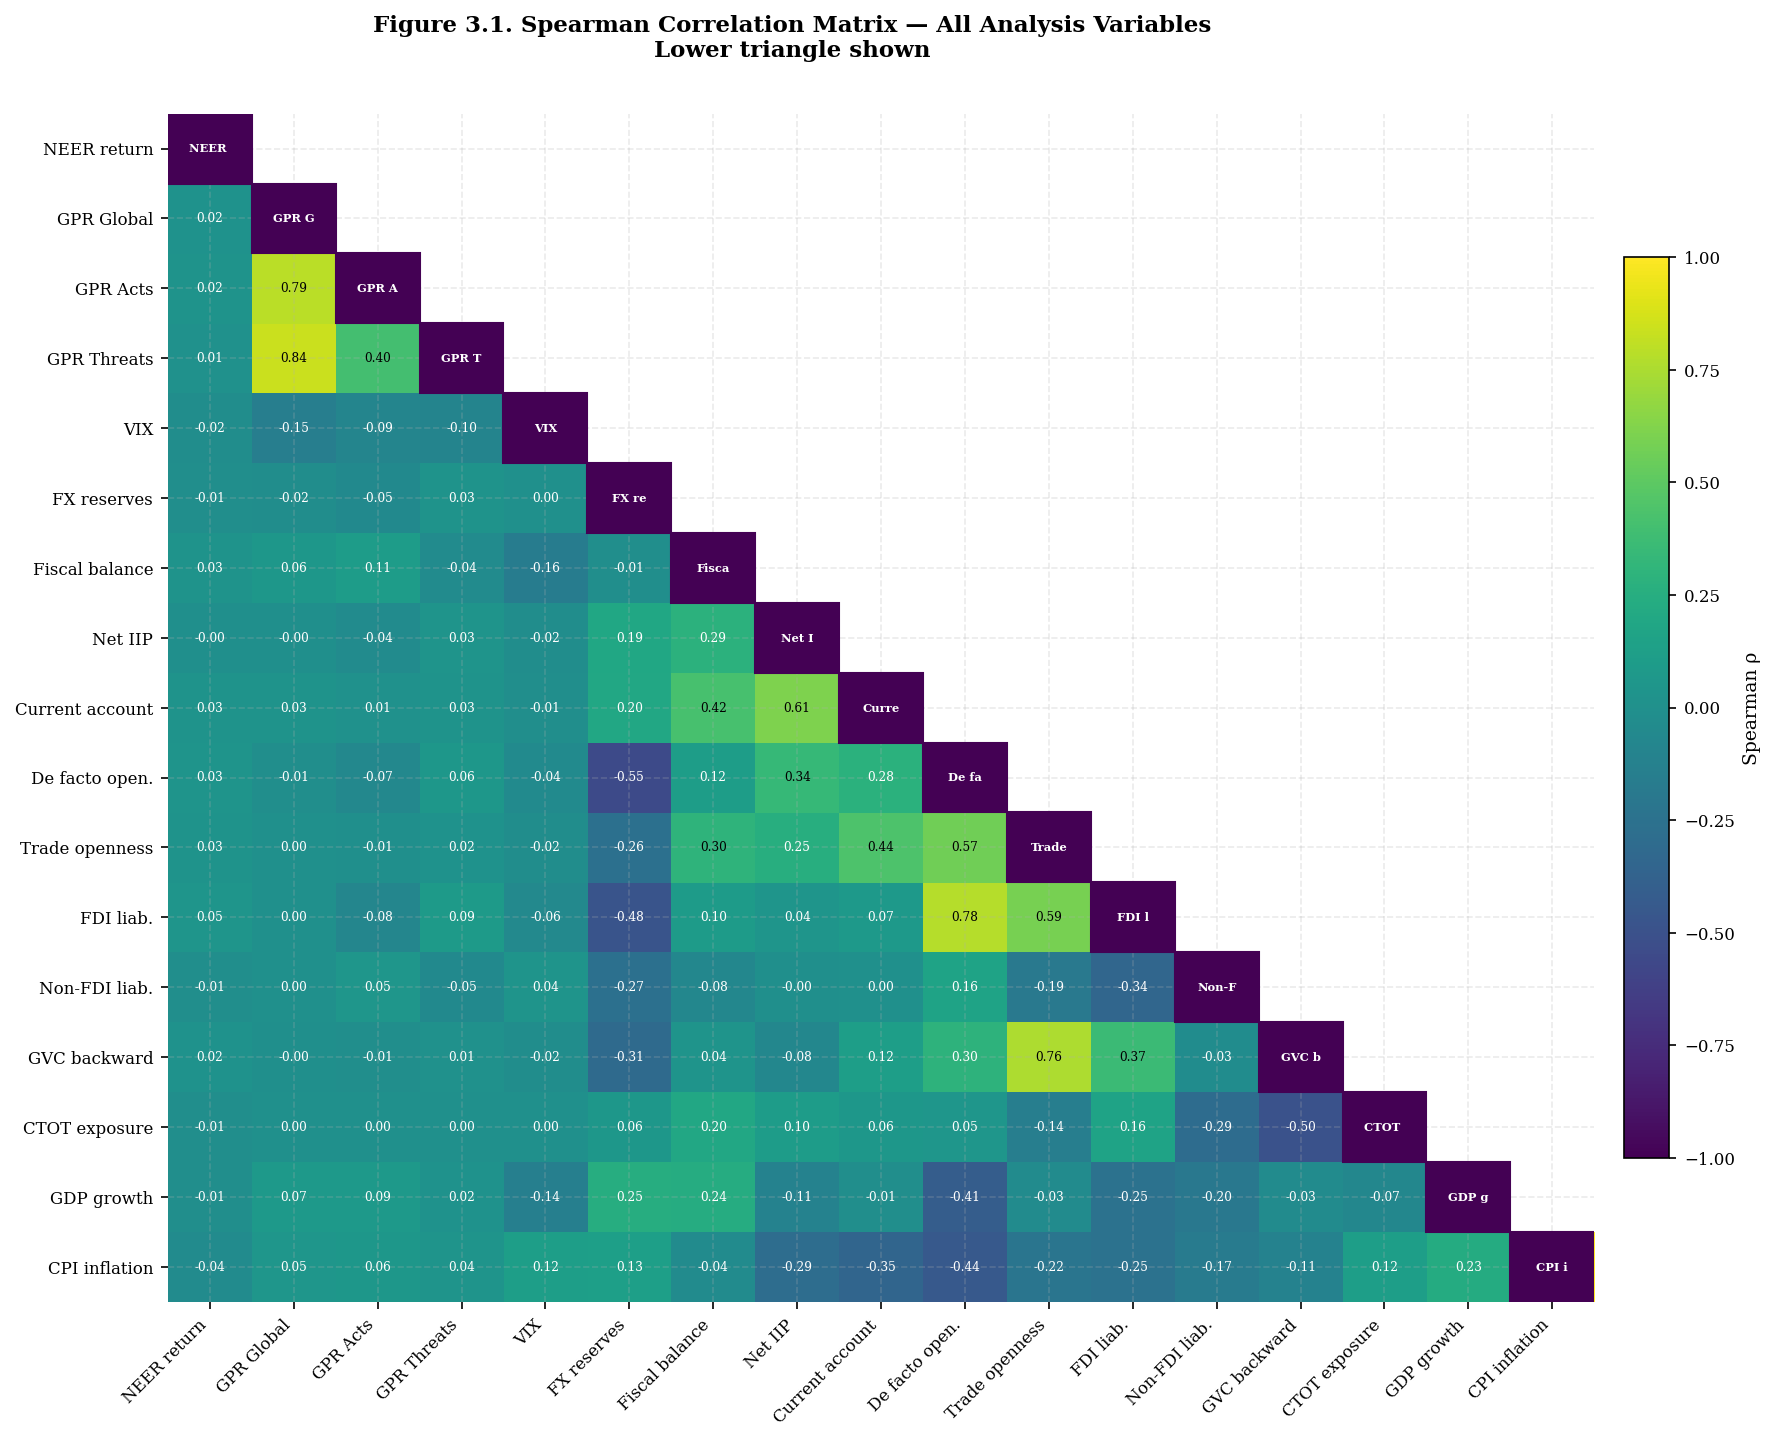

  Saved: fig4_1_correlation_matrix

Saved: fig4_2_neer_rolling_corr_heatmap.pdf / .png


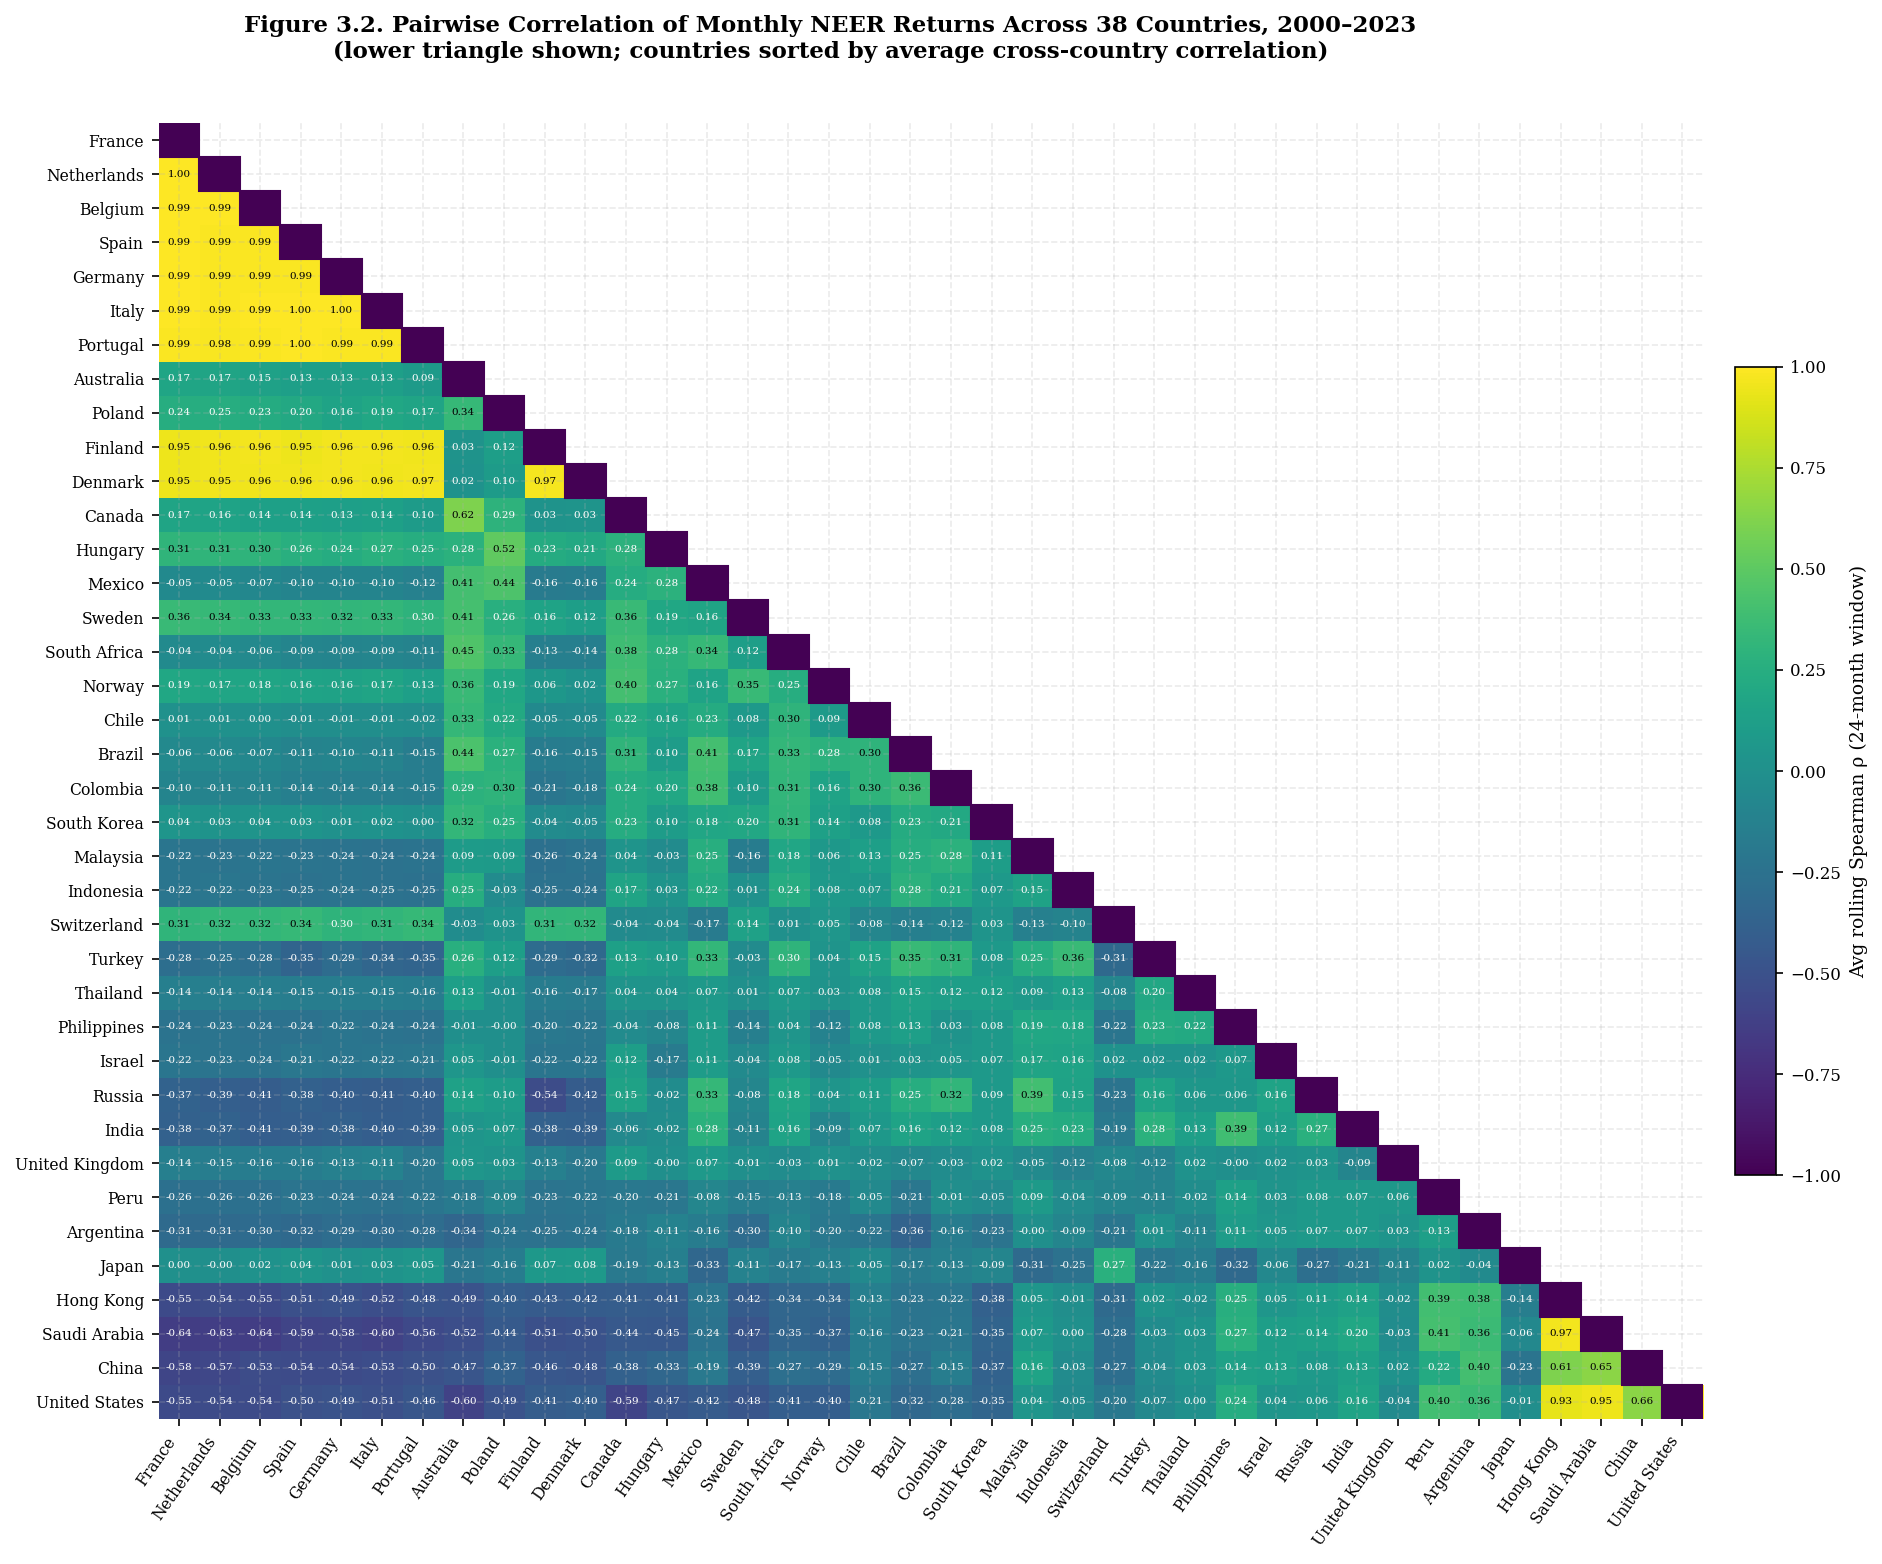

  Saved: fig4_2_neer_rolling_corr_heatmap

Saved: fig4_3_structural_heatmap.pdf / .png


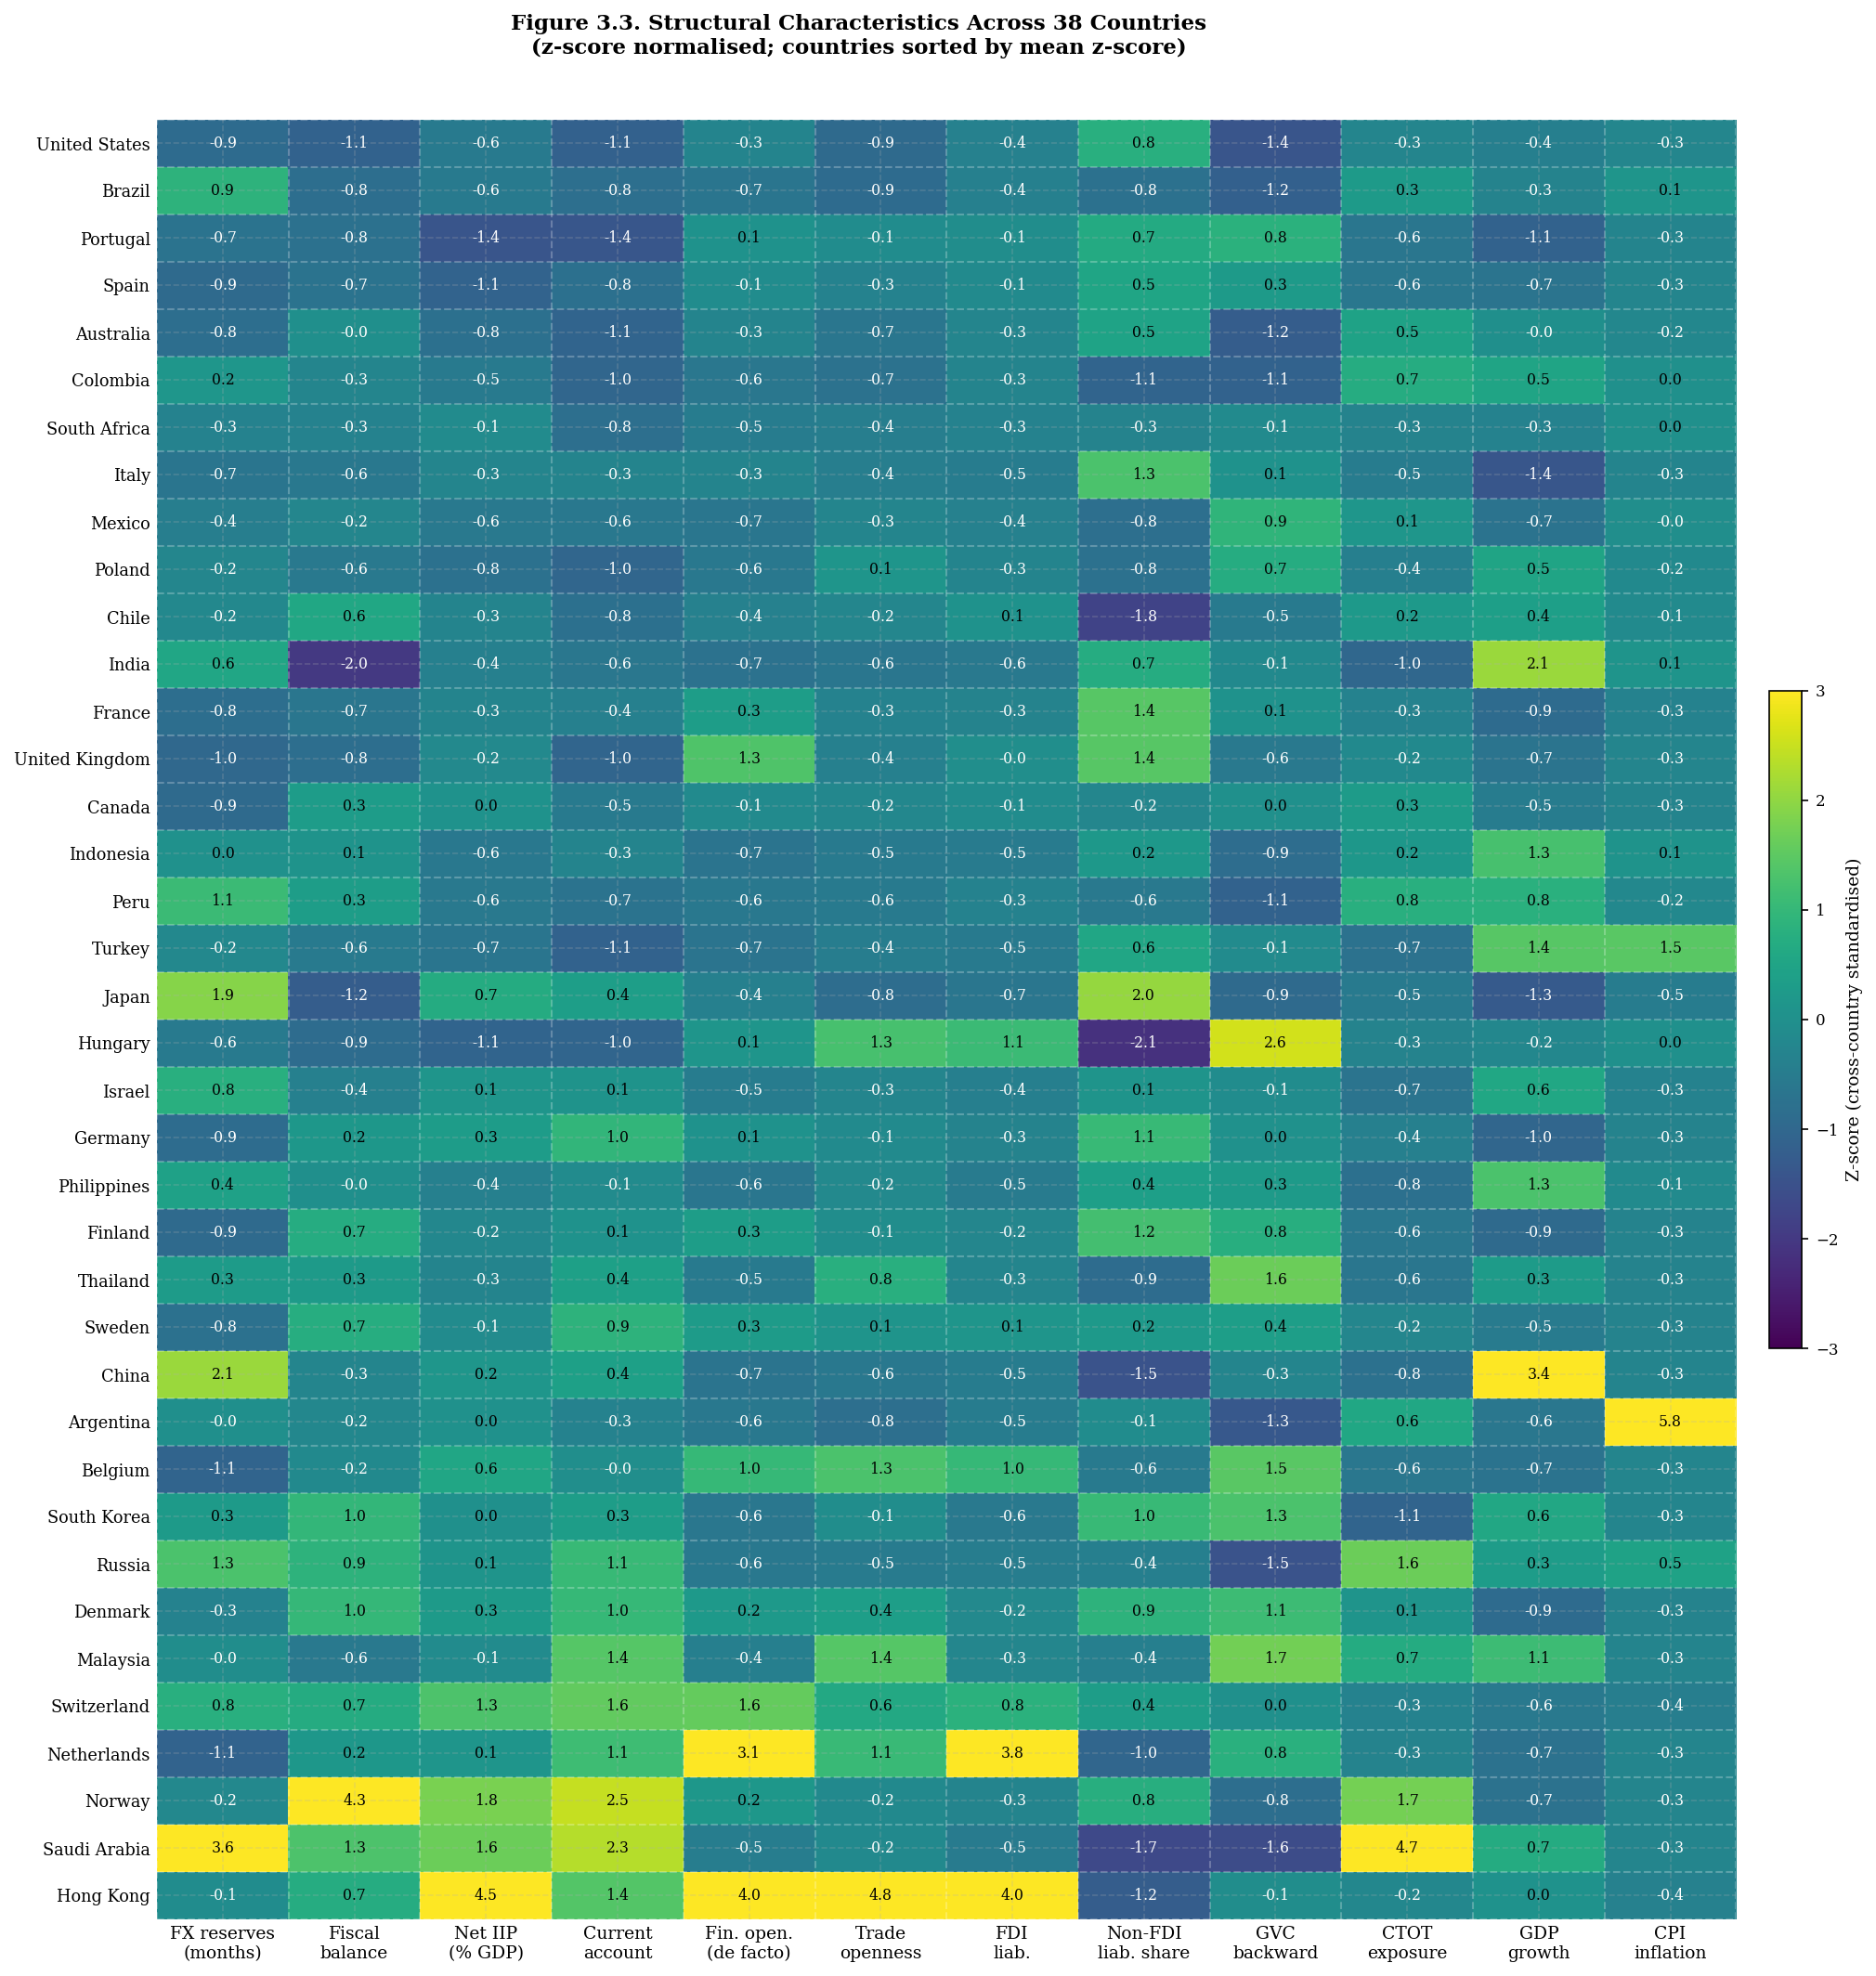

  Saved: fig4_3_structural_heatmap

  FIGURES 4.1 / 4.2 / 4.3 COMPLETE
  ← Fig 4.1: Variable correlation matrix (lower triangle)
  ← Fig 4.2: NEER pairwise rolling corr (lower triangle)
  ← Fig 4.3: Structural characteristics z-score heatmap


In [17]:
# ================================================================
# CELL 2 — DESCRIPTIVE STATISTICS
# Figures: 1 (GPR time series), 2 (NEER distribution — ANNEX),
#          3 (Volatility amplification), 4 (Returns amplification)
# Tables:  1 (Summary stats), 2 (Country stats — ANNEX)
# Test stat philosophy:
#   Fig 3: Panel Levene test in subtitle only. Stars on bars only.
#   Fig 4: Cross-country t-test in subtitle only. Stars on bars.
# ================================================================

# ── STRESS FLAGS ─────────────────────────────────────────────────
# Define the stress threshold as the 85th percentile of GPR-Act
# and GPR-Threat distributions across the full panel.
# Any month above this threshold is classified as a "stress month".
# This yields ~44 stress months per country (~15% of 288 months).
THRESH_ACT  = panel["gpr_act"].quantile(0.85)
THRESH_THR  = panel["gpr_threat"].quantile(0.85)

# Create binary stress indicators: 1 = stress month, 0 = normal month
panel["stress_act"] = (panel["gpr_act"] >= THRESH_ACT).astype(int)
panel["stress_thr"] = (panel["gpr_threat"] >= THRESH_THR).astype(int)

# Compute how many stress and normal months exist per country
n_stress = panel["stress_act"].sum() // panel["country"].nunique()
n_normal = panel["date"].nunique() - n_stress

print("=" * 65)
print("  CELL 2 — DESCRIPTIVE STATISTICS")
print("=" * 65)
print(f"  GPR-Act  85th pct: {THRESH_ACT:.1f} "
      f"({n_stress} stress months / country)")
print(f"  GPR-Thr  85th pct: {THRESH_THR:.1f}")
print(f"  Normal months    : {n_normal} / country")

# ================================================================
# TABLE 1 — SUMMARY STATISTICS
# ================================================================
# Dictionary mapping internal column names to readable labels
# for the summary statistics table in the thesis
SUMVARS = {
    # Time-series / panel variables (vary by country and month)
    "neer_ret_m"                    : "NEER log return (pp)",
    "gpr_global"                    : "GPR Global",
    "gpr_act"                       : "GPR Acts",
    "gpr_threat"                    : "GPR Threats",
    "vix_avg"                       : "VIX (monthly avg)",

    # Structural / country-level variables (vary slowly over time)
    "fx_reserves_months"            : "FX reserves (months of imports)",
    "fiscal_balance"                : "Fiscal balance (% GDP)",
    "ewn_net_iip_ex_gold_pct_gdp"  : "Net IIP ex gold (% GDP)",
    "ewn_current_account_pct_gdp"  : "Current account (% GDP)",
    "financial_openness_de_facto"  : "De facto financial openness",
    "trade_openness"                : "Trade openness (% GDP)",
    "ewn_fdi_liabilities_pct_gdp"  : "FDI liabilities (% GDP)",
    "ewn_non_fdi_liab_share"       : "Non-FDI liability share",
    "gvc_backward_tiva"            : "GVC backward linkage",
    "ctot_exposure"                 : "CTOT exposure",
    "gdp_growth"                    : "GDP growth (%)",
    "inflation_cpi"                 : "CPI inflation (%)",
}

tab1_rows = []
print(f"\n  TABLE 1 — SUMMARY STATISTICS")
print(f"  {'Variable':<38} {'N':>6} {'Mean':>8} "
      f"{'Median':>8} {'Std':>8} {'Min':>8} "
      f"{'Max':>8} {'Skew':>7}")
print(f"  {'─'*93}")

# Loop through each variable, compute summary statistics,
# and print one row per variable; flag any missing columns
for var, label in SUMVARS.items():
    if var not in panel.columns:
        print(f"  [MISSING] {var}")
        continue
    col = panel[var].dropna()
    row = {
        "Variable" : label,
        "N"        : len(col),
        "Mean"     : round(col.mean(),   3),
        "Median"   : round(col.median(), 3),
        "Std"      : round(col.std(),    3),
        "Min"      : round(col.min(),    3),
        "Max"      : round(col.max(),    3),
        "Skew"     : round(col.skew(),   3),  # skewness flags non-normality
    }
    tab1_rows.append(row)
    print(f"  {label:<38} {row['N']:>6} "
          f"{row['Mean']:>8.3f} {row['Median']:>8.3f} "
          f"{row['Std']:>8.3f} {row['Min']:>8.3f} "
          f"{row['Max']:>8.3f} {row['Skew']:>7.3f}")

# Save Table 1 to CSV for inclusion in the thesis appendix
pd.DataFrame(tab1_rows).to_csv(
    os.path.join(OUTPUT_DIR, "tab1_summary_stats.csv"),
    index=False)
print(f"  Saved: tab1_summary_stats.csv")

# ================================================================
# FIGURE 1 — GPR TIME SERIES
# ================================================================
# Collapse the panel to one row per date (GPR is the same across
# all countries in a given month — take first occurrence)
monthly_gpr = (panel.groupby("date")
               [["gpr_global","gpr_act","gpr_threat"]]
               .first().reset_index())

# Define the major geopolitical episodes to shade on the figure,
# each with a start and end date
EPISODES = {
    "9/11"           : ("2001-09-01", "2002-12-01"),
    "Iraq War"       : ("2003-01-01", "2003-08-01"),
    "London Bombing" : ("2005-07-01", "2005-09-01"),
    "Crimea"         : ("2014-02-01", "2014-12-01"),
    "Paris Attacks"  : ("2015-11-01", "2016-01-01"),
    "Rus–Ukraine"    : ("2022-02-01", "2022-12-01"),
    "Gaza"           : ("2023-10-01", "2023-12-01"),
}
# One distinct colour per episode for the shaded bands
EP_COLORS = [V1,V2,V3,V4,"#8B6FBF","#C0392B","#E67E22"]

fig, ax = plt.subplots(figsize=(13,5))

# Plot the three GPR series with different line styles to distinguish them
ax.plot(monthly_gpr["date"], monthly_gpr["gpr_global"],
        color=V2, lw=1.8, label="GPR Global", zorder=3)
ax.plot(monthly_gpr["date"], monthly_gpr["gpr_act"],
        color=V1, lw=1.3, ls="--",
        label="GPR Acts", alpha=0.85, zorder=3)
ax.plot(monthly_gpr["date"], monthly_gpr["gpr_threat"],
        color=V3, lw=1.3, ls=":",
        label="GPR Threats", alpha=0.85, zorder=3)

# Draw a horizontal dashed line at the 85th percentile threshold
# used to define stress months throughout the analysis
ax.axhline(THRESH_ACT, color=V1, lw=0.9, ls="-.",
           alpha=0.55,
           label=f"Top 15% Acts (≥{THRESH_ACT:.0f})")

# Shade each episode window and label it at the top of the chart
y_max = monthly_gpr["gpr_global"].max()
for (ep_name,(ep_s,ep_e)),ep_col in zip(
        EPISODES.items(), EP_COLORS):
    ax.axvspan(pd.Timestamp(ep_s),
               pd.Timestamp(ep_e),
               alpha=0.10, color=ep_col, zorder=1)
    # Place episode label at the midpoint of the shaded band
    mid = (pd.Timestamp(ep_s)
           + (pd.Timestamp(ep_e)
              - pd.Timestamp(ep_s))/2)
    ax.text(mid, y_max*1.01, ep_name,
            ha="center", va="bottom",
            fontsize=7, color=ep_col,
            fontweight="bold", clip_on=False)

ax.set_ylabel("GPR Index Level")
ax.set_title(
    "Figure 1. Global Geopolitical Risk Index, 2000–2023\n"
    "Acts, Threats, Global | Shaded = identified episodes",
    loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8.5,
          loc="upper left", ncol=2)
ax.set_xlim(monthly_gpr["date"].min(),
            monthly_gpr["date"].max())
fig.subplots_adjust(top=0.88)
save_fig(fig, "fig1_gpr_timeseries")
plt.show()

# ================================================================
# FIGURE 2 (ANNEX) — NEER DISTRIBUTION BY COUNTRY
# ================================================================
# Compute each country's mean and standard deviation of monthly
# NEER log returns across the full 2000-2023 sample
cs = (panel.groupby("country")["neer_ret_m"]
      .agg(mean="mean", std="std").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16,9))

# Left panel: mean NEER return sorted from most negative to most positive
# Negative mean = average depreciation tendency; positive = appreciation
cs_mean = cs.sort_values("mean")
ax = axes[0]
# Colour bars red (V1) for depreciators, blue (V2) for appreciators
colors_a = [V1 if m<0 else V2 for m in cs_mean["mean"]]
ax.barh(range(len(cs_mean)), cs_mean["mean"],
        color=colors_a, alpha=0.82,
        edgecolor="white", linewidth=0.4, height=0.7)
ax.axvline(0, color="black", lw=0.9)
ax.set_yticks(range(len(cs_mean)))
ax.set_yticklabels(cs_mean["country"], fontsize=8)
ax.set_xlabel("Mean monthly log NEER return (pp)")
ax.set_title("(a) Mean NEER return by country",
             loc="left", fontweight="bold")

# Right panel: NEER volatility (std dev) sorted from highest to lowest
# Higher volatility = more exchange rate instability
cs_std = cs.sort_values("std", ascending=False)
ax = axes[1]
# Use the full viridis gradient to colour bars by volatility rank
cmap_vals = np.linspace(0,1,len(cs_std))
colors_b  = [plt.cm.viridis(v) for v in cmap_vals]
ax.barh(range(len(cs_std)), cs_std["std"],
        color=colors_b, alpha=0.82,
        edgecolor="white", linewidth=0.4, height=0.7)
ax.set_yticks(range(len(cs_std)))
ax.set_yticklabels(cs_std["country"], fontsize=8)
ax.set_xlabel("Std. dev. of monthly log NEER return (pp)")
ax.set_title("(b) NEER volatility by country",
             loc="left", fontweight="bold")

fig.suptitle(
    "Figure 2 (Annex). NEER Log Return Distribution "
    "Across 38 Countries, 2000–2023",
    fontsize=11, fontweight="bold")
fig.subplots_adjust(wspace=0.35)
save_fig(fig, "fig2_annex_neer_distribution")
plt.show()

# ================================================================
# FIGURE 4 — VOLATILITY AMPLIFICATION (unchanged logic)
# Split into Figure 3a and 3b
# ================================================================
# For each country, compute NEER volatility separately during stress
# and normal months, then test whether the difference is significant
# using an F-test (ratio of variances)
def compute_vol(stress_col):
    rows = []
    for c in sorted(panel["country"].unique()):
        # Separate stress and normal period NEER returns for this country
        s = panel[(panel[stress_col]==1)&
                  (panel["country"]==c)
                  ]["neer_ret_m"].dropna()
        n = panel[(panel[stress_col]==0)&
                  (panel["country"]==c)
                  ]["neer_ret_m"].dropna()
        if len(s)<5 or len(n)<5: continue

        # F-statistic = ratio of stress variance to normal variance
        # A ratio > 1 means stress periods are more volatile
        f_val = s.var()/n.var()
        df1,df2 = len(s)-1,len(n)-1
        # Two-sided p-value from the F distribution
        p_f = 2*min(1-stats.f.cdf(f_val,df1,df2),
                    stats.f.cdf(f_val,df1,df2))
        rows.append({"country":c,
                     "vol_stress":s.std(),
                     "vol_normal":n.std(),
                     "ratio":s.std()/n.std(),  # volatility amplification ratio
                     "p_f":p_f,
                     "sig":sig_label(p_f)})
    # Sort countries from highest to lowest amplification ratio
    return pd.DataFrame(rows).sort_values(
        "ratio", ascending=False)

vol_act = compute_vol("stress_act")
vol_thr = compute_vol("stress_thr")

# Panel-level Levene test: tests whether the variance of NEER returns
# differs significantly between the stress and normal subsamples
# across the entire panel (all countries pooled together)
def levene_test(stress_col):
    s = panel[panel[stress_col]==1][
        "neer_ret_m"].dropna()
    n = panel[panel[stress_col]==0][
        "neer_ret_m"].dropna()
    lf, lp = stats.levene(s,n)
    # One-sample t-test on the country-level ratios to test if the
    # mean amplification ratio is significantly different from 1
    ratios  = compute_vol(stress_col)["ratio"].values
    tv, tp  = stats.ttest_1samp(ratios,1)
    return lf,lp,ratios.mean(),tv,tp

lf_a,lp_a,mr_a,tv_a,tp_a = levene_test("stress_act")
lf_t,lp_t,mr_t,tv_t,tp_t = levene_test("stress_thr")

print(f"\n  VOLATILITY TESTS:")
print(f"  GPR-Act  Levene: F={lf_a:.3f} "
      f"p={lp_a:.4f}{sig_label(lp_a)} | "
      f"Mean ratio={mr_a:.3f}x")
print(f"  GPR-Thr  Levene: F={lf_t:.3f} "
      f"p={lp_t:.4f}{sig_label(lp_t)} | "
      f"Mean ratio={mr_t:.3f}x")

# ── Figure 4a — GPR-Act ───────────────────────────────────────
# Produce one figure for GPR-Act stress and one for GPR-Threat stress
# Each figure shows paired bars (stress vs normal) for all 38 countries
# Stars above bars indicate a statistically significant F-test (p<0.10)
for fig_i,(vdf,lp,mr,label,c_s,c_n,fig_tag) in enumerate([
    (vol_act,lp_a,mr_a,"GPR-Act (Top 15%)", V1,V2,"4a"),
    (vol_thr,lp_t,mr_t,"GPR-Threat (Top 15%)",V3,V4,"4b"),
]):
    fig, ax = plt.subplots(figsize=(14,7))
    x  = np.arange(len(vdf)); w = 0.38

    # Stress bars (left of each pair)
    ax.bar(x-w/2, vdf["vol_stress"], w,
           color=c_s, alpha=0.80,
           label="Stress", edgecolor="white",
           linewidth=0.4)
    # Normal bars (right of each pair)
    ax.bar(x+w/2, vdf["vol_normal"], w,
           color=c_n, alpha=0.80,
           label="Normal", edgecolor="white",
           linewidth=0.4)

    # Add significance stars above the taller bar for each country
    for j,(_, row) in enumerate(vdf.iterrows()):
        if row["sig"]:
            y_top = max(row["vol_stress"],
                        row["vol_normal"])+0.08
            ax.text(j, y_top, row["sig"],
                    ha="center", va="bottom",
                    fontsize=8, color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(vdf["country"],
                       rotation=55, ha="right",
                       fontsize=8)
    ax.set_ylabel("Std. dev. of NEER log return (pp)")
    # Subtitle shows the panel-level Levene test result
    ax.set_title(
        f"Levene p={lp:.4f}{sig_label(lp)} | "
        f"Mean ratio={mr:.3f}×",
        loc="left", fontsize=9.5,
        fontweight="bold")
    ax.legend(frameon=False, fontsize=9,
              loc="upper right")
    ax.margins(x=0.01)
    fig.suptitle(
        f"Figure {fig_tag}. Currency Volatility: Stress vs Normal Periods ({label})\n"
        "Stars = significant F-test per country (p<0.10)",
        fontsize=11, fontweight="bold")
    fig.subplots_adjust(bottom=0.18, top=0.88)
    save_fig(fig, f"fig{fig_tag}_volatility_amplification")
    plt.show()

from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr as sp_r

# ================================================================
# FIGURE 3.1 — SPEARMAN CORRELATION MATRIX
# Lower triangle | no in-cell stars
# ================================================================
# Dictionary mapping column names to short labels for the heatmap axes
CORR_VARS = {
    "neer_ret_m"                   : "NEER return",
    "gpr_global"                   : "GPR Global",
    "gpr_act"                      : "GPR Acts",
    "gpr_threat"                   : "GPR Threats",
    "vix_avg"                      : "VIX",
    "fx_reserves_months"           : "FX reserves",
    "fiscal_balance"               : "Fiscal balance",
    "ewn_net_iip_ex_gold_pct_gdp" : "Net IIP",
    "ewn_current_account_pct_gdp" : "Current account",
    "financial_openness_de_facto"  : "De facto open.",
    "trade_openness"               : "Trade openness",
    "ewn_fdi_liabilities_pct_gdp" : "FDI liab.",
    "ewn_non_fdi_liab_share"      : "Non-FDI liab.",
    "gvc_backward_tiva"           : "GVC backward",
    "ctot_exposure"                : "CTOT exposure",
    "gdp_growth"                   : "GDP growth",
    "inflation_cpi"                : "CPI inflation",
}

# Extract only the columns present in the panel and rename for display
corr_data = panel[[v for v in CORR_VARS
                   if v in panel.columns]].copy()
corr_data.columns = [CORR_VARS[c]
                     for c in corr_data.columns]
labels = corr_data.columns.tolist()
n      = len(labels)

# Build the full n×n Spearman correlation matrix pairwise,
# dropping NaNs for each pair independently to maximise data use
corr_mat = np.zeros((n, n))
for i, c1 in enumerate(labels):
    for j, c2 in enumerate(labels):
        if i == j:
            corr_mat[i, j] = 1.0           # diagonal = perfect correlation
        elif i > j:
            tmp = corr_data[[c1, c2]].dropna()
            if len(tmp) > 5:
                rho, _ = sp_r(tmp[c1], tmp[c2])
                corr_mat[i, j] = rho
                corr_mat[j, i] = rho       # matrix is symmetric

# Mask the upper triangle so only the lower triangle is plotted
mask_u   = np.triu(np.ones((n, n), dtype=bool), k=1)
plot_mat = np.where(mask_u, np.nan, corr_mat)

# Use viridis colormap; NaN cells (upper triangle) render as white
cmap_41  = plt.cm.viridis.copy()
cmap_41.set_bad("white")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(plot_mat,
               cmap=cmap_41,
               vmin=-1, vmax=1,
               aspect="auto")

# Annotate each cell: diagonal cells show abbreviated variable name,
# lower triangle cells show the numeric correlation value
for i in range(n):
    for j in range(n):
        if i < j:
            continue
        if i == j:
            # Diagonal: dark purple square with variable name
            ax.add_patch(plt.Rectangle(
                (j-0.5, i-0.5), 1, 1,
                color=V1, zorder=2))
            ax.text(j, i, labels[i][:5],
                    ha="center", va="center",
                    fontsize=5.5, color="white",
                    fontweight="bold", zorder=3)
            continue
        # Off-diagonal: show correlation value; white text on dark cells
        val = corr_mat[i, j]
        col = "white" if val < 0.3 else "black"
        ax.text(j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=5.8, color=col,
                zorder=3)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45,
                   ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(im, ax=ax,
                    fraction=0.03, pad=0.02)
cbar.set_label("Spearman ρ", fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "Figure 3.1. Spearman Correlation Matrix — All Analysis Variables\n"
    "Lower triangle shown",
    fontsize=11, fontweight="bold")
fig.subplots_adjust(bottom=0.20, top=0.92,
                    left=0.18, right=0.95)
save_fig(fig, "fig4_1_correlation_matrix")
plt.show()
# Save the full correlation matrix as CSV for reference
pd.DataFrame(corr_mat, index=labels,
             columns=labels).to_csv(
    os.path.join(OUTPUT_DIR,
                 "fig4_1_correlation_matrix.csv"))
print("  Saved: fig4_1_correlation_matrix")

# ================================================================
# FIGURE 3.2 — PAIRWISE NEER ROLLING CORRELATION HEATMAP
# 24-month rolling | lower triangle | no in-cell stars
# sorted by avg cross-country correlation
# ================================================================
# This figure shows how correlated each pair of countries' NEER returns
# are on average over rolling 24-month windows — captures time-varying
# co-movement rather than a single full-sample correlation
ROLL_WINDOW = 24

# Reshape the panel to wide format: rows = dates, columns = countries
neer_wide = (panel.pivot_table(
    index="date", columns="country",
    values="neer_ret_m")
    .sort_index())

countries = neer_wide.columns.tolist()
n_c       = len(countries)

# Initialise the correlation matrix with ones on the diagonal
roll_mat = pd.DataFrame(np.eye(n_c),
                         index=countries,
                         columns=countries)

# For each country pair, compute the rolling 24-month Spearman
# correlation and store the time-series average in the matrix
for i in range(n_c):
    for j in range(i+1, n_c):
        ci, cj = countries[i], countries[j]
        rc = (neer_wide[ci]
              .rolling(ROLL_WINDOW)
              .corr(neer_wide[cj])
              .dropna())
        roll_mat.loc[ci, cj] = rc.mean()
        roll_mat.loc[cj, ci] = rc.mean()   # symmetric

# Sort countries by their average pairwise correlation (most correlated first)
# so that highly integrated economies cluster together visually
avg_corr  = roll_mat.mean(axis=1).sort_values(ascending=False)
ordered   = avg_corr.index.tolist()
mat_ord   = roll_mat.loc[ordered, ordered]

# Mask upper triangle for lower-triangle-only display
mat_vals  = mat_ord.values.copy()
mask_u2   = np.triu(np.ones((n_c, n_c), dtype=bool), k=1)
plot_mat2 = np.where(mask_u2, np.nan, mat_vals)

cmap_42  = plt.cm.viridis.copy()
cmap_42.set_bad("white")

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(plot_mat2,
               cmap=cmap_42,
               vmin=-1, vmax=1,
               aspect="auto")

# Annotate cells: diagonal left empty (no label), lower triangle shows value
for i in range(n_c):
    for j in range(n_c):
        if i < j:
            continue
        if i == j:
            ax.add_patch(plt.Rectangle(
                (j-0.5, i-0.5), 1, 1,
                color=V1, zorder=2))
            continue
        val = mat_vals[i, j]
        col = "white" if val < 0.3 else "black"
        ax.text(j, i, f"{val:.2f}",
                ha="center", va="center",
                fontsize=5.0, color=col,
                zorder=3)

ax.set_xticks(range(n_c))
ax.set_yticks(range(n_c))
ax.set_xticklabels(ordered, rotation=55,
                   ha="right", fontsize=7.5)
ax.set_yticklabels(ordered, fontsize=7.5)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(im, ax=ax,
                    fraction=0.025, pad=0.02)
cbar.set_label(
    f"Avg rolling Spearman ρ ({ROLL_WINDOW}-month window)",
    fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "Figure 3.2. Pairwise Correlation of Monthly NEER Returns "
    "Across 38 Countries, 2000–2023\n"
    "(lower triangle shown; countries sorted by "
    "average cross-country correlation)",
    fontsize=11, fontweight="bold")
fig.subplots_adjust(bottom=0.20, top=0.92,
                    left=0.18, right=0.95)
save_fig(fig, "fig4_2_neer_rolling_corr_heatmap")
plt.show()
# Save the ordered correlation matrix to CSV
mat_ord.to_csv(os.path.join(OUTPUT_DIR,
               "fig4_2_neer_rolling_corr_matrix.csv"))
print("  Saved: fig4_2_neer_rolling_corr_heatmap")

# ================================================================
# FIGURE 3.3 — STRUCTURAL CHARACTERISTICS HEATMAP
# Z-score normalised | country × variable | viridis sequential
# ================================================================
# This heatmap provides a visual overview of where each country sits
# relative to the cross-country average on every structural variable.
# Z-scores allow comparison across variables with very different scales.
STRUCT_VARS = {
    "fx_reserves_months"           : "FX reserves\n(months)",
    "fiscal_balance"               : "Fiscal\nbalance",
    "ewn_net_iip_ex_gold_pct_gdp" : "Net IIP\n(% GDP)",
    "ewn_current_account_pct_gdp" : "Current\naccount",
    "financial_openness_de_facto"  : "Fin. open.\n(de facto)",
    "trade_openness"               : "Trade\nopenness",
    "ewn_fdi_liabilities_pct_gdp" : "FDI\nliab.",
    "ewn_non_fdi_liab_share"      : "Non-FDI\nliab. share",
    "gvc_backward_tiva"           : "GVC\nbackward",
    "ctot_exposure"                : "CTOT\nexposure",
    "gdp_growth"                   : "GDP\ngrowth",
    "inflation_cpi"                : "CPI\ninflation",
}

# Only include variables that are actually present in the panel
avail_struct = [v for v in STRUCT_VARS if v in panel.columns]

# Compute each country's time-series median for each structural variable
# to get one representative value per country (removes short-run noise)
struct_means = panel.groupby("country")[avail_struct].mean()
struct_means.columns = [STRUCT_VARS[v] for v in avail_struct]

# Z-score normalise each variable across countries (axis=0):
# z = (x - mean) / std, so 0 = cross-country average, ±1 = one std dev away
from scipy.stats import zscore
struct_z = struct_means.apply(zscore, axis=0)

# Sort countries by their mean z-score across all variables
# (most structurally weak at top, most structurally strong at bottom)
struct_z = struct_z.loc[
    struct_z.mean(axis=1).sort_values().index]

n_countries = len(struct_z)
n_vars      = len(struct_z.columns)

cmap_43 = plt.cm.viridis.copy()
cmap_43.set_bad(VGREY)   # missing values shown in neutral grey

fig, ax = plt.subplots(
    figsize=(max(13, n_vars * 1.2),
             max(10, n_countries * 0.40)))

# Display the z-score matrix as a colour heatmap
im = ax.imshow(struct_z.values,
               cmap=cmap_43,
               vmin=-3, vmax=3,    # cap colour scale at ±3 std devs
               aspect="auto")

# Annotate each cell with its z-score value
# White text on dark (negative/low) cells, black text on bright (high) cells
for i in range(n_countries):
    for j in range(n_vars):
        val = struct_z.values[i, j]
        if np.isnan(val):
            continue
        col = "white" if val < 0 else "black"
        ax.text(j, i, f"{val:.1f}",
                ha="center", va="center",
                fontsize=7.5, color=col)

ax.set_xticks(range(n_vars))
ax.set_yticks(range(n_countries))
ax.set_xticklabels(struct_z.columns,
                   fontsize=9, ha="center")
ax.set_yticklabels(struct_z.index, fontsize=8.5)

# Add white grid lines between cells using minor ticks
ax.set_xticks(np.arange(-0.5, n_vars, 1),      minor=True)
ax.set_yticks(np.arange(-0.5, n_countries, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.tick_params(which="minor", length=0)
ax.tick_params(which="major", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = plt.colorbar(im, ax=ax,
                    fraction=0.02, pad=0.02)
cbar.set_label("Z-score (cross-country standardised)",
               fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "Figure 3.3. Structural Characteristics Across 38 Countries\n"
    "(z-score normalised; countries sorted by mean z-score)",
    fontsize=11, fontweight="bold")
fig.subplots_adjust(bottom=0.08, top=0.93,
                    left=0.15, right=0.97)
save_fig(fig, "fig4_3_structural_heatmap")
plt.show()
# Save the z-score matrix to CSV for reference
struct_z.to_csv(os.path.join(OUTPUT_DIR,
                "fig4_3_structural_heatmap.csv"))
print("  Saved: fig4_3_structural_heatmap")

print("\n" + "="*65)
print("  FIGURES 4.1 / 4.2 / 4.3 COMPLETE")
print("="*65)
print("  ← Fig 4.1: Variable correlation matrix (lower triangle)")
print("  ← Fig 4.2: NEER pairwise rolling corr (lower triangle)")
print("  ← Fig 4.3: Structural characteristics z-score heatmap")
print("="*65)

Cell 3: Stage 1

  CELL 3 — STAGE 1
  GPR-Act 85th pct  : 153.2
  Stress months     : 44
  Full panel N      : 10944
  Top 15% panel N   : 1672

  STRESS-MEAN NEER:
  Country                 Mean (pp)    N
  ──────────────────────────────────────
  Argentina                 -5.4012   44
  Turkey                    -0.7886   44
  Mexico                    -0.5345   44
  Colombia                  -0.2849   44
  United Kingdom            -0.2635   44
  Japan                     -0.2550   44
  Indonesia                 -0.2144   44
  Saudi Arabia              -0.1566   44
  Philippines               -0.1531   44
  Malaysia                  -0.1503   44
  China                     -0.1273   44
  Chile                     -0.1254   44
  Hong Kong                 -0.1024   44
  India                     -0.1001   44
  United States             -0.0551   44
  Russia                    -0.0412   44
  Israel                    -0.0352   44
  Peru                      +0.0202   44
  South Africa              +0.0

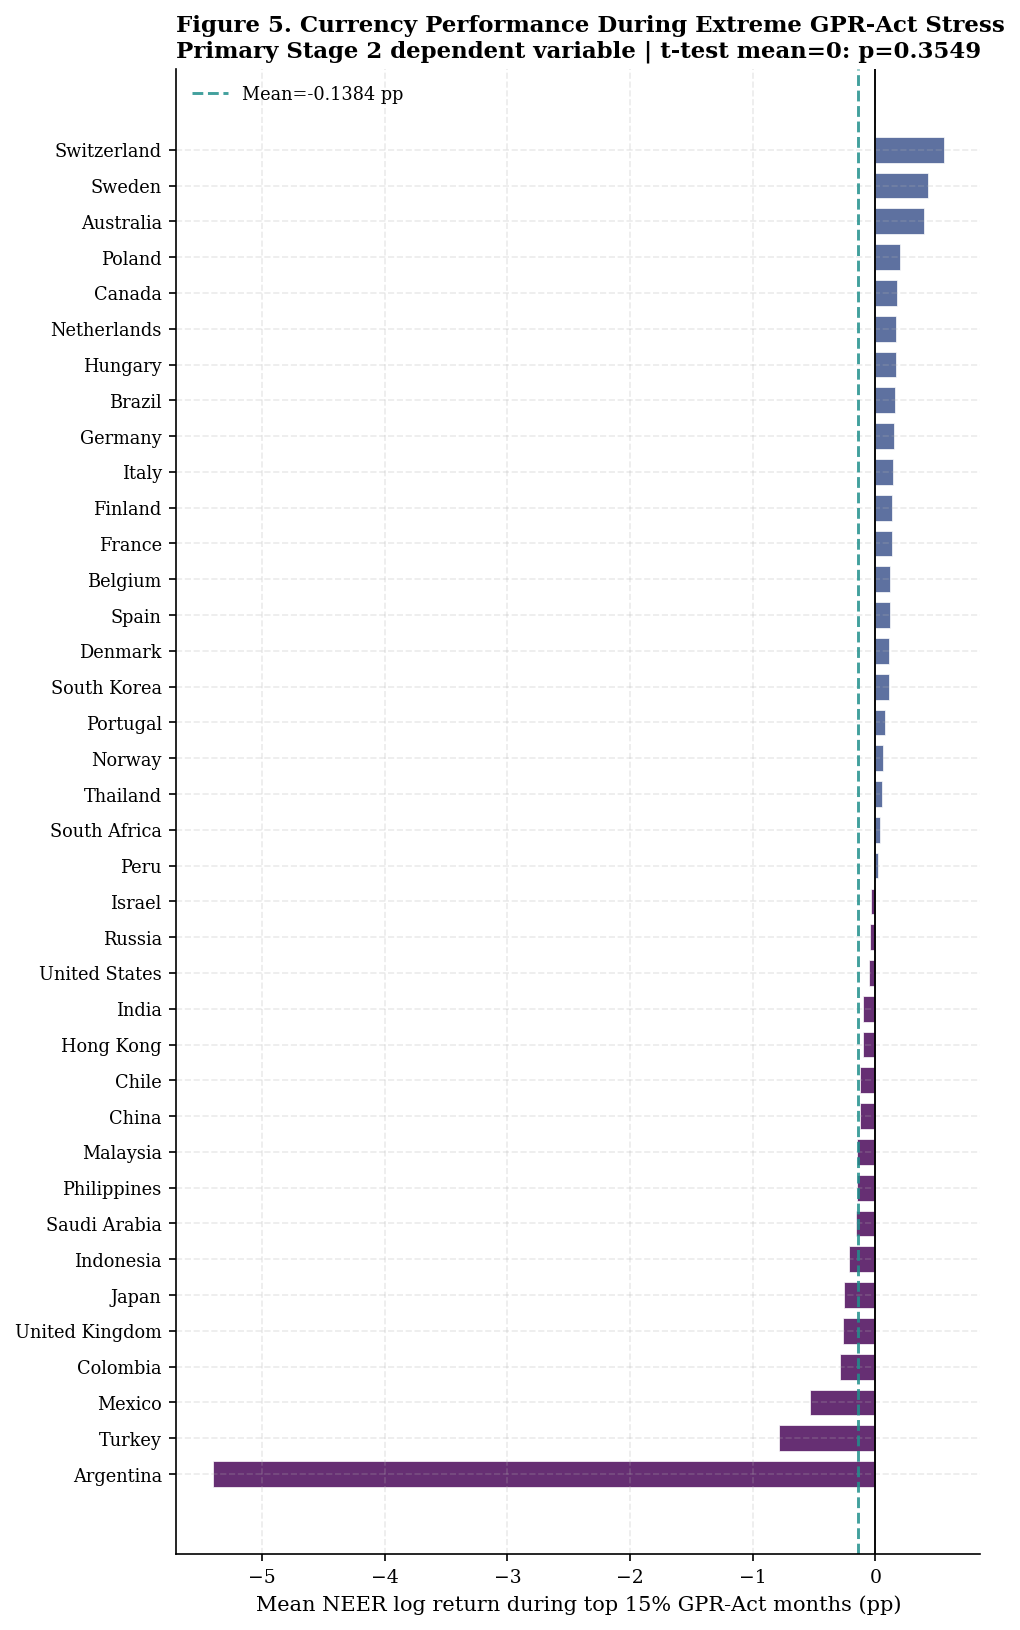


  CELL 3 COMPLETE — STAGE 1
  ← THESIS: stress_mean_w = cross-sectional DV
  ← THESIS: panel_top15_enriched = panel DV input
  ← THESIS: 13 structural vars have signal


In [18]:
# ================================================================
# CELL 3 — STAGE 1
# Computes stress_mean_w (cross-sectional DV) + beta_w
# Builds panel_top15_enriched.csv for all H cells
# Figure 5: Country stress performance bar chart
# ================================================================

# ── GPR SETUP ────────────────────────────────────────────────────
# Standardise GPR-Act to z-scores so regression coefficients
# are interpretable as the effect of a one-standard-deviation
# increase in geopolitical risk acts
gpr_mu = panel["gpr_act"].mean()
gpr_sd = panel["gpr_act"].std()
panel["gpr_act_z"]  = (panel["gpr_act"] - gpr_mu)/gpr_sd

# Define the 85th percentile threshold to identify stress months
# Any month where GPR-Act >= this threshold is flagged as stress
THRESH              = panel["gpr_act"].quantile(0.85)
panel["stress_act"] = (panel["gpr_act"]>=THRESH).astype(int)

# Extract year from date — needed later for year fixed effects
panel["year"]       = panel["date"].dt.year

# Subset the panel to stress months only — this is the sample
# used throughout Stage 2 panel interaction regressions
panel_top           = panel[panel["stress_act"]==1].copy()

print("="*65)
print("  CELL 3 — STAGE 1")
print("="*65)
print(f"  GPR-Act 85th pct  : {THRESH:.1f}")
print(f"  Stress months     : {panel_top['date'].nunique()}")
print(f"  Full panel N      : {len(panel)}")
print(f"  Top 15% panel N   : {len(panel_top)}")

# ── STRESS MEAN NEER (PRIMARY CROSS-SECTIONAL DV) ────────────────
# For each country, compute the mean, standard deviation, and count
# of monthly NEER log returns during the stress subsample.
# This produces the primary dependent variable for Stage 2A:
# stress_mean_w = average currency performance under GPR stress
stress_means = (panel_top.groupby("country")["neer_ret_m"]
                .agg(stress_mean="mean",
                     stress_std="std",
                     stress_n="count")
                .reset_index())

# Winsorise stress_mean at the 5th and 95th percentile to reduce
# the influence of extreme observations (e.g. Argentina crises)
# while preserving the full cross-country ranking
sm_lo = stress_means["stress_mean"].quantile(0.05)
sm_hi = stress_means["stress_mean"].quantile(0.95)
n_clip_sm = int(((stress_means["stress_mean"]<sm_lo)|
                 (stress_means["stress_mean"]>sm_hi)).sum())
stress_means["stress_mean_w"] = (
    stress_means["stress_mean"].clip(sm_lo,sm_hi))

# One-sample t-test: tests whether the cross-country mean of
# stress_mean is significantly different from zero
# A significant result would mean GPR stress systematically
# depreciates or appreciates currencies on average
t_sm,p_sm = stats.ttest_1samp(
    stress_means["stress_mean"],0)

print(f"\n  STRESS-MEAN NEER:")
print(f"  {'Country':<22} {'Mean (pp)':>10} {'N':>4}")
print(f"  {'─'*38}")
for _,r in stress_means.sort_values(
        "stress_mean").iterrows():
    print(f"  {r['country']:<22} "
          f"{r['stress_mean']:>+10.4f} "
          f"{int(r['stress_n']):>4}")
print(f"\n  Mean={stress_means['stress_mean'].mean():>+.4f} "
      f"t={t_sm:.3f} p={p_sm:.4f}{sig_label(p_sm)}")
print(f"  Winsor:[{sm_lo:>+.4f},{sm_hi:>+.4f}] "
      f"({n_clip_sm} clipped)")

# ── COUNTRY OLS BETAS (ROBUSTNESS DV) ────────────────────────────
# For each country individually, regress NEER log returns on
# standardised GPR-Act with VIX as a control, using HC3 standard errors.
# This produces a country-level beta capturing GPR sensitivity,
# used as a robustness check DV alongside stress_mean_w
print(f"\n  COUNTRY OLS BETAS (top 15% | VIX control | HC3):")
print(f"  {'Country':<22} {'β':>9} {'p':>7} "
      f"{'Sig':>4} {'R²':>6}")
print(f"  {'─'*52}")

beta_rows = []
for country in sorted(panel_top["country"].unique()):
    # Restrict to this country's stress-period observations
    sub = (panel_top[panel_top["country"]==country]
           [["neer_ret_m","gpr_act_z","vix_avg"]]
           .dropna())
    if len(sub)<10: continue   # skip if too few observations

    # OLS with HC3: NEER return = α + β·GPR_z + γ·VIX + ε
    # β captures how much NEER moves per 1 SD increase in GPR-Act
    # VIX controls for global risk appetite (confound)
    X = sm.add_constant(
        sub[["gpr_act_z","vix_avg"]].astype(float))
    y = sub["neer_ret_m"].astype(float)
    m = sm.OLS(y,X).fit(cov_type="HC3")
    b  = m.params["gpr_act_z"]
    p  = m.pvalues["gpr_act_z"]
    ci = m.conf_int(alpha=0.10)   # 90% confidence interval
    print(f"  {country:<22} {b:>+9.4f} {p:>7.3f} "
          f"{sig_label(p):>4} {m.rsquared:>6.4f}")
    beta_rows.append({
        "country":country,
        "beta":round(b,4),
        "se":round(m.bse["gpr_act_z"],4),
        "pval":round(p,4),
        "sig":sig_label(p),
        "ci_lo":round(ci.loc["gpr_act_z",0],4),
        "ci_hi":round(ci.loc["gpr_act_z",1],4),
        "r2":round(m.rsquared,4),
        "n":int(m.nobs),
    })

betas    = pd.DataFrame(beta_rows)

# Winsorise betas at 5th/95th percentile for the same reason as stress_mean
b_lo     = betas["beta"].quantile(0.05)
b_hi     = betas["beta"].quantile(0.95)
betas["beta_w"] = betas["beta"].clip(b_lo,b_hi)

# One-sample t-test on betas across countries:
# tests whether the average country-level GPR sensitivity is
# significantly different from zero
t_b,p_b  = stats.ttest_1samp(betas["beta"],0)

# Count how many countries have a significant negative vs positive beta
n_neg    = ((betas["beta"]<0)&(betas["pval"]<0.10)).sum()
n_pos    = ((betas["beta"]>0)&(betas["pval"]<0.10)).sum()
print(f"\n  Mean β={betas['beta'].mean():>+.4f} "
      f"t={t_b:.3f} p={p_b:.4f}{sig_label(p_b)}")
print(f"  Sig neg={n_neg} | Sig pos={n_pos}")

# ── SAVE STAGE 1 ─────────────────────────────────────────────────
# Merge stress_mean and beta results into one country-level file.
# This file feeds directly into all Stage 2A cross-sectional regressions
stage1 = stress_means.merge(betas, on="country")
stage1.to_csv(
    os.path.join(OUTPUT_DIR,
                 "stage1_country_betas.csv"),
    index=False)
print(f"\n  Saved: stage1_country_betas.csv")

# ── BUILD ENRICHED PANEL (TOP 15%) ───────────────────────────────
# This constructs the panel used in Stage 2B interaction regressions.
# It merges the stress-month panel with country-level structural
# variable medians (time-invariant structural characteristics)
# and adds standardised z-score versions for use in interactions
print(f"\n  Building panel_top15_enriched.csv...")

# Full list of structural variables entering Stage 2B regressions
ALL_STRUCT = [
    "ewn_net_iip_ex_gold_pct_gdp",       # Net IIP (external balance)
    "ewn_current_account_pct_gdp",        # Current account balance
    "fx_reserves_months","fiscal_balance", # Policy buffers
    "ewn_fdi_liabilities_pct_gdp",        # FDI liability stock
    "ewn_non_fdi_liab_share",             # Non-FDI liability share (fragility)
    "kaopen","ewn_de_facto_fin_open_pct_gdp", # Capital account openness
    "trade_openness","irr_flexible",       # Trade and regime openness
    "ctot_exposure","net_energy_imports",  # Commodity channels
    "gvc_backward_tiva",                   # GVC integration
    "gdp_growth","inflation_cpi",          # Domestic macro conditions
]

# Compute each country's median value for every structural variable
# across the full panel (not just stress months) to capture the
# structural characteristic rather than short-run fluctuations
struct_med = (panel.groupby("country")
              [ALL_STRUCT].median().reset_index())

# Standardise each structural variable to z-scores across countries
# so the interaction term β2 (gpr_z × structural_z) is comparable
# across variables with different units and scales
for var in ALL_STRUCT:
    col    = struct_med[var].dropna()
    mu,sd  = col.mean(), col.std()
    struct_med[f"{var}_z"] = (
        (struct_med[var]-mu)/sd if sd>0 else 0)

# Merge structural medians and z-scores into the stress-period panel
panel_enrich = panel_top.merge(
    struct_med, on="country", how="left",
    suffixes=("","_med"))

# Create year dummy variables for year fixed effects (drop first to avoid multicollinearity)
td = pd.get_dummies(panel_enrich["year"],
                    prefix="yr",
                    drop_first=True).astype(int)
# Create country dummy variables for country fixed effects
cd = pd.get_dummies(panel_enrich["country"],
                    prefix="c",
                    drop_first=True).astype(int)

# Append fixed-effect dummies to the enriched panel
panel_enrich = pd.concat([panel_enrich,td,cd],axis=1)

# Save the enriched stress-period panel — this is the input
# for all Stage 2B hypothesis cells (H1 through H9)
panel_enrich.to_csv(
    os.path.join(OUTPUT_DIR,
                 "panel_top15_enriched.csv"),
    index=False)

# Store the year and country FE column names for use in regressions
tc_cols = [c for c in panel_enrich.columns
           if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns
           if c.startswith("c_")]
print(f"  N={len(panel_enrich)} | "
      f"Country FE={len(cc_cols)} | "
      f"Year FE={len(tc_cols)}")
print(f"  Saved: panel_top15_enriched.csv")

# ── FIGURE 5 — STRESS PERFORMANCE BAR CHART ──────────────────────
# Horizontal bar chart ranking all 38 countries by their mean NEER
# return during stress months. Negative bars (V1, dark purple) =
# depreciators; positive bars (V2, blue) = appreciators.
# This is the visual representation of the Stage 2 dependent variable.
sm_s   = stress_means.sort_values(
    "stress_mean").reset_index(drop=True)
colors = [V1 if m<0 else V2
          for m in sm_s["stress_mean"]]

fig, ax = plt.subplots(figsize=(8,11))
y_pos   = np.arange(len(sm_s))
ax.barh(y_pos, sm_s["stress_mean"],
        color=colors, alpha=0.82,
        edgecolor="white", linewidth=0.4,
        height=0.72)
ax.axvline(0, color="black", lw=0.9)

# Dashed vertical line at the cross-country mean for reference
ax.axvline(sm_s["stress_mean"].mean(),
           color=V3, lw=1.4, ls="--", alpha=0.85,
           label=f"Mean="
                 f"{sm_s['stress_mean'].mean():>+.4f} pp")
ax.set_yticks(y_pos)
ax.set_yticklabels(sm_s["country"], fontsize=8.5)
ax.set_xlabel(
    "Mean NEER log return during top 15% "
    "GPR-Act months (pp)")
# Title includes the t-test p-value testing whether the mean is
# significantly different from zero across all 38 countries
ax.set_title(
    "Figure 5. Currency Performance During "
    "Extreme GPR-Act Stress\n"
    "Primary Stage 2 dependent variable | "
    "t-test mean=0: "
    f"p={p_sm:.4f}{sig_label(p_sm)}",
    loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=8.5)
fig.subplots_adjust(left=0.25, right=0.92,
                    top=0.95, bottom=0.05)
save_fig(fig,"fig5_stage1_stress_performance")
plt.show()

print("\n"+"="*65)
print("  CELL 3 COMPLETE — STAGE 1")
print("="*65)
print(f"  ← THESIS: stress_mean_w = cross-sectional DV")
print(f"  ← THESIS: panel_top15_enriched = panel DV input")
print(f"  ← THESIS: 13 structural vars have signal")
print("="*65)

PART 2


In [19]:
# ================================================================
# SHARED HELPER — used by all H cells (4-10)
# Run cross-sectional OLS + Spearman for one variable
# Run panel interaction for one variable
# Returns result dicts for table building
# ================================================================

def run_cross_section(df_cs, var, label):
    # Drop missing values and require at least 10 observations
    # to run a meaningful cross-sectional regression (N=38 max)
    col    = df_cs[var].dropna()
    if len(col) < 10:
        return None, None

    # Winsorise the structural variable at 5th/95th percentile
    # to limit the influence of extreme outliers on OLS estimates
    lo, hi = col.quantile(0.05), col.quantile(0.95)
    df_cs[f"{var}_w"] = df_cs[var].clip(lo, hi)

    # Keep only rows where both the structural variable and the
    # dependent variable (stress_mean_w) are non-missing
    sub    = df_cs[["country",f"{var}_w",
                     "stress_mean_w"]].dropna()
    if len(sub) < 10:
        return None, None

    # Spearman rank correlation: non-parametric measure of monotonic
    # association between the structural variable and stress_mean_w.
    # Robust to outliers and non-normality — used as the primary
    # inference method in the cross-sectional analysis
    rho, p_rho = stats.spearmanr(
        sub[f"{var}_w"], sub["stress_mean_w"])

    # Bivariate OLS with HC3 standard errors:
    # stress_mean_w = α + β·structural_var_w + ε
    # HC3 corrects for heteroskedasticity arising from the fact
    # that stress_mean_w is estimated with varying precision
    # across countries (small-sample correction for leverage points)
    X   = sm.add_constant(sub[f"{var}_w"].astype(float))
    y   = sub["stress_mean_w"].astype(float)
    m   = sm.OLS(y, X).fit(cov_type="HC3")

    # Return a dictionary of all results needed for tables and figures
    return ({
        "label":label, "rho":rho, "p_rho":p_rho,
        "slope":m.params[f"{var}_w"],
        "p_ols":m.pvalues[f"{var}_w"],
        "n_cs":len(sub), "model":m,
        "wvar":f"{var}_w", "sub":sub,
    }, df_cs)


def run_panel_interaction(panel_enrich,
                           var, label,
                           cc_cols, tc_cols):
    # Stage 2B panel interaction regression.
    # Tests whether a structural variable conditions the marginal
    # effect of GPR-Act on NEER returns within stress months.
    # Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × structural_z)
    #                 + β3·structural_z + γ·VIX + country FE + year FE + ε
    # β2 is the key coefficient: significant β2 means the structural
    # variable amplifies (β2<0) or dampens (β2>0) GPR transmission

    # Use the standardised (z-score) version of the structural variable
    # so β2 is comparable across variables with different units
    z_var   = f"{var}_z"
    int_var = f"gpr_x_{var}"   # name for the interaction term

    # Skip if the z-score variable is missing from the enriched panel
    if z_var not in panel_enrich.columns:
        return {"b1":np.nan,"b2":np.nan,
                "p_b2":np.nan,"n_pan":0}

    # Construct the interaction term: GPR_z × structural_z
    panel_enrich[int_var] = (panel_enrich["gpr_act_z"]
                              * panel_enrich[z_var])

    # Build the regressor list: GPR level, interaction, structural level,
    # VIX control, country fixed effects, year fixed effects
    regs  = (["gpr_act_z",int_var,z_var,"vix_avg"]
              + cc_cols + tc_cols)

    # Only keep regressors that actually exist in the panel
    avail = [r for r in regs
             if r in panel_enrich.columns]

    # Drop rows with any missing values in the regression variables
    sub_p = panel_enrich[
        ["neer_ret_m","country"]+avail].dropna()

    # Require at least 50 observations to run the panel regression
    if len(sub_p) < 50:
        return {"b1":np.nan,"b2":np.nan,
                "p_b2":np.nan,"n_pan":0}
    try:
        X_p = sm.add_constant(
            sub_p[avail].astype(float))
        y_p = sub_p["neer_ret_m"].astype(float)
        # Cluster standard errors at the country level to account for
        # serial correlation within countries across stress months
        m_p = sm.OLS(y_p,X_p).fit(
            cov_type="cluster",
            cov_kwds={"groups":sub_p["country"]})
        return {
            "b1":m_p.params["gpr_act_z"],       # baseline GPR effect
            "b2":m_p.params.get(int_var,np.nan), # interaction coefficient (key result)
            "p_b2":m_p.pvalues.get(int_var,np.nan), # p-value on interaction
            "n_pan":int(m_p.nobs),
        }
    except:
        # Return NaNs if the regression fails (e.g. perfect multicollinearity)
        return {"b1":np.nan,"b2":np.nan,
                "p_b2":np.nan,"n_pan":0}


def print_results_table(hypo, tab_rows):
    # Prints a formatted results table to the console showing
    # both cross-sectional and panel results side by side for each variable
    print(f"\n  RESULTS TABLE — {hypo}")
    print(f"  {'─'*78}")
    print(f"  {'Variable':<35} "
          f"{'Cross-Section':^22} "
          f"{'Panel Top 15%':^18}")
    print(f"  {'':35} "
          f"{'ρ':>7} {'p':>7} {'Sig':>4} "
          f"{'β2':>7} {'p':>7} {'Sig':>4}")
    print(f"  {'─'*78}")
    for r in tab_rows:
        print(f"  {r['Variable']:<35} "
              f"{r['CS rho']:>+7.3f} "
              f"{r['CS p']:>7.3f} "
              f"{r['CS sig']:>4} "
              f"{r['Panel b2']:>+7.4f} "
              f"{r['Panel p']:>7.3f} "
              f"{r['Panel sig']:>4}")
    print(f"  {'─'*78}")
    # Remind reader of the estimation method used for each column
    print(f"  CS: Spearman | HC3 | N=38 | "
          f"DV=stress_mean_w")
    print(f"  Panel: clustered SE | "
          f"country+year FE | top 15% GPR-Act")


def make_scatter_figure(scatter_list, pan_results,
                         fignum, title, figname,
                         ncols=2):
    # Produces a grid of scatter plots, one per structural variable,
    # showing the cross-sectional relationship between the structural
    # variable (x-axis) and stress_mean_w (y-axis) across 38 countries
    n_vars = len(scatter_list)
    ncols  = min(ncols, n_vars)
    nrows  = int(np.ceil(n_vars/ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(7*ncols,
                                       6*nrows))
    axes = np.array(axes).flatten()

    for ax_i,(var,sd) in enumerate(scatter_list):
        ax    = axes[ax_i]
        sub   = sd["sub"]
        wvar  = sd["wvar"]    # winsorised variable name
        slope = sd["slope"]   # OLS slope for the fitted line
        p     = sd["p_ols"]
        rho   = sd["rho"]
        p_rho = sd["p_rho"]

        # Scatter plot: each dot is one country
        ax.scatter(sub[wvar], sub["stress_mean_w"],
                   color=V2, s=55, alpha=0.85,
                   edgecolors="white",
                   linewidths=0.5, zorder=3)

        # OLS fitted line: coloured V1 (significant) or grey (insignificant)
        # based on the Spearman p-value — uses solid line if significant
        x_rng = np.linspace(sub[wvar].min(),
                             sub[wvar].max(),100)
        y_hat = (sd["model"].params["const"]
                 + slope*x_rng)
        ax.plot(x_rng, y_hat,
                color=V1 if p_rho<0.10 else VGREY,
                lw=2,
                ls="-" if p_rho<0.10 else "--",
                zorder=2)

        # Label each dot with the country name for readability
        for _,row in sub.iterrows():
            ax.annotate(
                row["country"],
                (row[wvar],row["stress_mean_w"]),
                fontsize=5.5, alpha=0.72,
                xytext=(4,3),
                textcoords="offset points")

        # Horizontal reference line at zero NEER return
        ax.axhline(0, color="black", lw=0.8,
                   ls="--", alpha=0.35)

        # Retrieve panel interaction results for this variable
        pan = pan_results.get(var,{})
        b2  = pan.get("b2",np.nan)
        p_b = pan.get("p_b2",np.nan)

        # Annotation box in top-right corner showing Spearman ρ and p-value
        # This is the primary inference statistic shown on the figure
        ax.text(0.97,0.97,
                f"Spearman ρ = {rho:>+.3f}\n"
                f"p = {p_rho:.3f}"
                f"{sig_label(p_rho)}",
                transform=ax.transAxes,
                ha="right",va="top",fontsize=9,
                bbox=dict(boxstyle="round,pad=0.4",
                          fc="white",alpha=0.92,
                          ec="none"))

        ax.set_xlabel(f"{sd['label']}\n"
                      f"(median, winsorized 10%)",
                      fontsize=9)
        # Only label y-axis on leftmost plots to avoid repetition
        ax.set_ylabel(
            "Stress-period mean NEER (pp)\n"
            "(top 15% GPR-Act, winsorized 10%)"
            if ax_i%ncols==0 else "",fontsize=9)
        ax.set_title(
            f"({'abcdefgh'[ax_i]}) {sd['label']}",
            loc="left",fontweight="bold")

    # Hide any unused subplot panels if n_vars is odd
    for j in range(ax_i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"Figure {fignum}. {title}\n"
        f"Cross-sectional analysis | N=38 countries | "
        f"Winsorized 10%",
        fontsize=11, fontweight="bold")
    fig.subplots_adjust(wspace=0.28, hspace=0.35,
                        top=0.90, bottom=0.10)
    save_fig(fig, figname)
    plt.show()

# CELL 4 — H2: EXTERNAL BALANCE CHANNEL


  CELL 4 — H2 External Balance
  Prediction: more negative NIIP / larger CA deficit → more depreciation during GPR stress
  Pre-flight: both insignificant in both methods

  BLOCK A — CROSS-SECTIONAL
  Variable                                  ρ    p(ρ)  Sig    N
  ───────────────────────────────────────────────────────
  Net IIP ex Gold (% GDP)              -0.058   0.730        38
  Current Account (% GDP)              +0.113   0.499        38

  BLOCK B — PANEL INTERACTION (TOP 15%)
  Variable                                   β2   p(β2)  Sig      N
  ────────────────────────────────────────────────────────────
  Net IIP ex Gold (% GDP)               +0.0295   0.111        1672
  Current Account (% GDP)               +0.0237   0.458        1672

  RESULTS TABLE — H2 External Balance
  ──────────────────────────────────────────────────────────────────────────────
  Variable                                Cross-Section        Panel Top 15%   
                                          

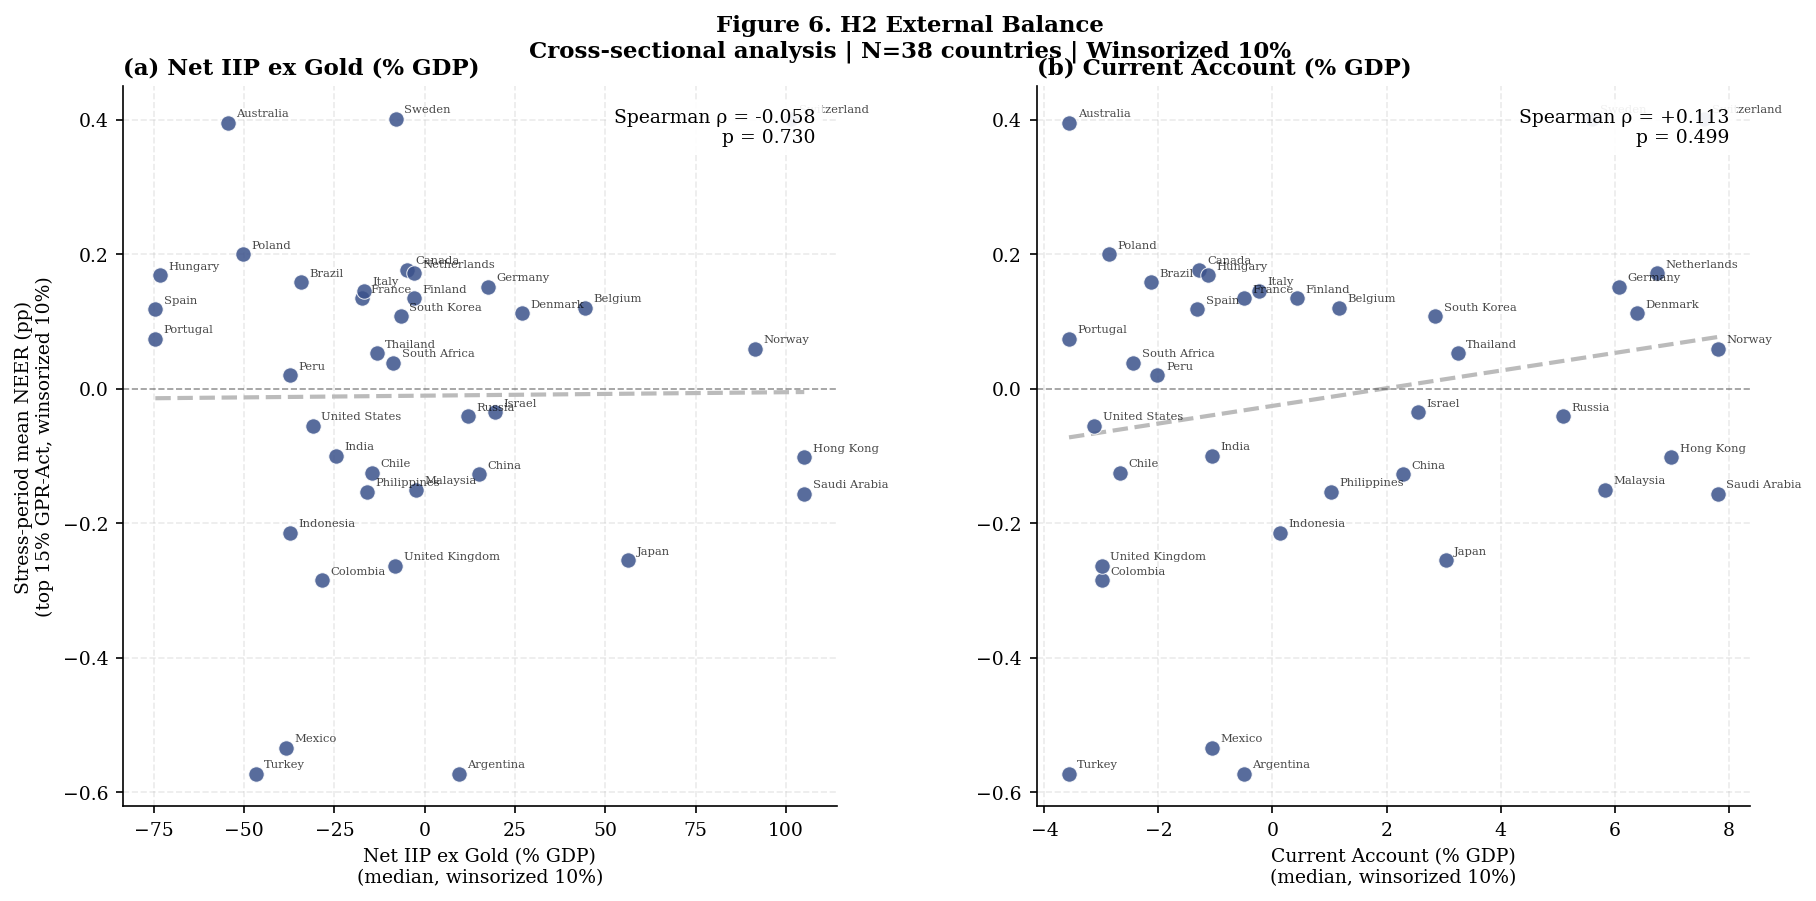


  CELL 4 COMPLETE — H2 External Balance
  ← THESIS: Net IIP ex Gold (% GDP)             CS p=0.730 | Panel p=0.111 | Neither
  ← THESIS: Current Account (% GDP)             CS p=0.498 | Panel p=0.458 | Neither
  ← THESIS: External balance channel not supported


In [20]:
# ================================================================
# CELL 4 — H2: EXTERNAL BALANCE CHANNEL
# Variables: NIIP ex Gold, Current Account
# Expected: both insignificant (confirmed in pre-flight)
# ================================================================

# Reload Stage 1 results (stress_mean_w per country) and the
# stress-period enriched panel built in Cell 3
stage1       = pd.read_csv(os.path.join(OUTPUT_DIR,"stage1_country_betas.csv"))
panel_enrich = pd.read_csv(os.path.join(OUTPUT_DIR,"panel_top15_enriched.csv"),parse_dates=["date"])

# Identify the year and country fixed-effect dummy columns created in Cell 3
tc_cols = [c for c in panel_enrich.columns if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns if c.startswith("c_")]

# H2 tests the external balance channel:
# countries with a more negative Net IIP (net debtor) or larger
# current account deficit may be more vulnerable to capital flight
# during GPR stress, leading to sharper depreciation
H_VARS  = {
    "ewn_net_iip_ex_gold_pct_gdp": "Net IIP ex Gold (% GDP)",
    "ewn_current_account_pct_gdp": "Current Account (% GDP)",
}
HYPO    = "H2 External Balance"
FIGNUM  = "6"
FIGNAME = "fig6_h2_external_balance"

# Compute each country's median structural value across the full panel
# (time-invariant representation of each country's external balance position)
struct = (panel.groupby("country")
          [list(H_VARS.keys())].median().reset_index())

# Build the cross-sectional dataset: one row per country,
# combining stress_mean_w (DV) with the structural variables (IVs)
df_cs  = stage1[["country","stress_mean_w"]].merge(
    struct, on="country", how="left")

print("="*65)
print(f"  CELL 4 — {HYPO}")
print("="*65)
print(f"  Prediction: more negative NIIP / larger CA "
      f"deficit → more depreciation during GPR stress")
print(f"  Pre-flight: both insignificant in both methods")

# ── BLOCK A: CROSS-SECTIONAL ──────────────────────────────────────
# For each variable: Spearman ρ and bivariate OLS with HC3 (N=38)
# DV = stress_mean_w (mean NEER return during top 15% GPR-Act months)
print(f"\n  BLOCK A — CROSS-SECTIONAL")
print(f"  {'Variable':<35} {'ρ':>7} {'p(ρ)':>7} "
      f"{'Sig':>4} {'N':>4}")
print(f"  {'─'*55}")

# Initialise containers to collect results for table and figure building
cs_results   = {}
scatter_list = []
pan_results  = {}
tab_rows     = []

# Run cross-sectional analysis for each H2 variable using the shared helper
for var,label in H_VARS.items():
    cs_r, df_cs = run_cross_section(df_cs,var,label)
    if cs_r is None: continue
    cs_results[var] = cs_r
    scatter_list.append((var,cs_r))  # store for scatter figure
    print(f"  {label:<35} {cs_r['rho']:>+7.3f} "
          f"{cs_r['p_rho']:>7.3f} "
          f"{sig_label(cs_r['p_rho']):>4} "
          f"{cs_r['n_cs']:>4}")

# ── BLOCK B: PANEL INTERACTION ────────────────────────────────────
# For each variable: interaction regression on the stress-period panel
# Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × structural_z)
#                 + β3·structural_z + γ·VIX + country FE + year FE + ε
# Key result is β2: does the structural variable condition GPR transmission?
# Standard errors clustered at country level to handle serial correlation
print(f"\n  BLOCK B — PANEL INTERACTION (TOP 15%)")
print(f"  {'Variable':<35} {'β2':>9} {'p(β2)':>7} "
      f"{'Sig':>4} {'N':>6}")
print(f"  {'─'*60}")

for var,label in H_VARS.items():
    pan_r = run_panel_interaction(
        panel_enrich,var,label,cc_cols,tc_cols)
    pan_results[var] = pan_r
    b2  = pan_r["b2"]
    p_b = pan_r["p_b2"]
    print(f"  {label:<35} {b2:>+9.4f} "
          f"{p_b:>7.3f} {sig_label(p_b):>4} "
          f"{pan_r['n_pan']:>6}")

    # Collect both CS and panel results into a single row for the results table
    cs  = cs_results.get(var,{})
    tab_rows.append({
        "Hypothesis":HYPO,"Variable":label,
        "CS rho":round(cs.get("rho",np.nan),3),
        "CS p":round(cs.get("p_rho",np.nan),4),
        "CS sig":sig_label(cs.get("p_rho",1)),
        "Panel b2":round(b2,4),
        "Panel p":round(p_b,4),
        "Panel sig":sig_label(p_b),
        "N CS":cs.get("n_cs",0),
        "N Panel":pan_r["n_pan"],
    })

# Print the formatted side-by-side results table and save to CSV
print_results_table(HYPO, tab_rows)
pd.DataFrame(tab_rows).to_csv(
    os.path.join(OUTPUT_DIR,"tab_h2_results.csv"),
    index=False)
print(f"  Saved: tab_h2_results.csv")

# Produce the scatter figure: one panel per variable showing the
# cross-sectional relationship between the structural variable and stress_mean_w
make_scatter_figure(scatter_list, pan_results,
                     FIGNUM, HYPO, FIGNAME, ncols=2)

# ── THESIS VERDICT ────────────────────────────────────────────────
# Classify each variable as significant in Both / CS only /
# Panel only / Neither, and print the thesis-ready conclusion
print("\n"+"="*65)
print(f"  CELL 4 COMPLETE — {HYPO}")
print("="*65)
for r in tab_rows:
    verdict = ("Both" if r["CS sig"] and r["Panel sig"]
               else "CS only" if r["CS sig"]
               else "Panel only" if r["Panel sig"]
               else "Neither")
    print(f"  ← THESIS: {r['Variable']:<35} "
          f"CS p={r['CS p']:.3f}{r['CS sig']} | "
          f"Panel p={r['Panel p']:.3f}"
          f"{r['Panel sig']} | {verdict}")
print(f"  ← THESIS: External balance channel not supported")
print("="*65)

# CELL 5 — H3: POLICY BUFFER CHANNEL


  CELL 5 — H3 Policy Buffers
  FX Reserves: confirmed significant in BOTH methods
  Negative sign in CS: high-reserve EMs depreciate
  Positive β2 in panel: reserves buffer GPR shock
  Fiscal Balance: insignificant in both

  BLOCK A — CROSS-SECTIONAL
  Variable                                     ρ    p(ρ)  Sig    N
  ──────────────────────────────────────────────────────────
  FX Reserves (months of imports)         -0.407   0.011   **   38
  Fiscal Balance (% GDP)                  +0.145   0.384        38

  BLOCK B — PANEL INTERACTION (TOP 15%)
  Variable                                      β2   p(β2)  Sig      N
  ───────────────────────────────────────────────────────────────
  FX Reserves (months of imports)          +0.0406   0.041   **   1672
  Fiscal Balance (% GDP)                   +0.0054   0.825        1672

  RESULTS TABLE — H3 Policy Buffers
  ──────────────────────────────────────────────────────────────────────────────
  Variable                                Cross-

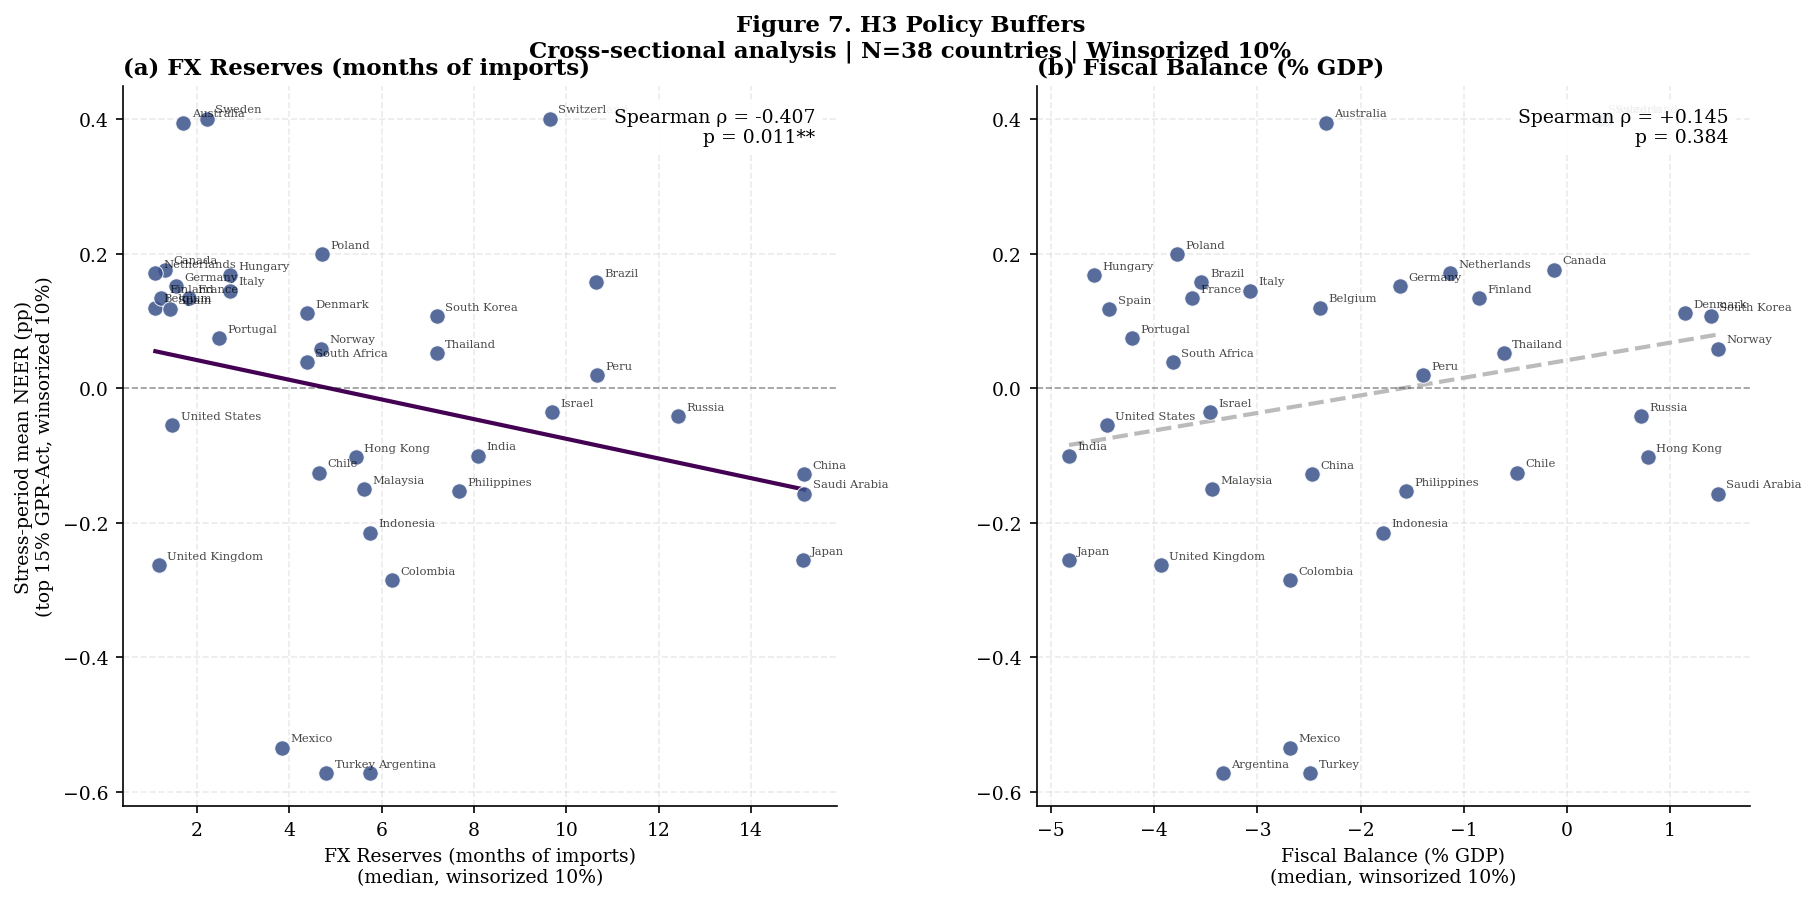


  CELL 5 COMPLETE — H3 Policy Buffers
  ← THESIS: FX Reserves (months of imports)        CS p=0.011** | Panel p=0.041** | Both
  ← THESIS: Fiscal Balance (% GDP)                 CS p=0.384 | Panel p=0.825 | Neither


In [21]:
# ================================================================
# CELL 5 — H3: POLICY BUFFER CHANNEL
# Variables: FX Reserves, Fiscal Balance
# KEY: FX Reserves significant in BOTH methods
# ================================================================

# Reload Stage 1 results and the stress-period enriched panel
stage1       = pd.read_csv(os.path.join(OUTPUT_DIR,"stage1_country_betas.csv"))
panel_enrich = pd.read_csv(os.path.join(OUTPUT_DIR,"panel_top15_enriched.csv"),parse_dates=["date"])

# Identify year and country fixed-effect dummy columns
tc_cols = [c for c in panel_enrich.columns if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns if c.startswith("c_")]

# H3 tests the policy buffer channel:
# Countries with larger FX reserve buffers or stronger fiscal positions
# may be better equipped to absorb GPR shocks and defend their currency.
# FX reserves: expected negative in CS (high-reserve EMs still depreciate
# due to selection — vulnerable countries accumulate reserves precisely
# because they are exposed), but positive β2 in panel (reserves actively
# buffer the marginal GPR shock within stress months).
# Fiscal balance: expected insignificant — fiscal space operates at
# lower frequency than the monthly GPR transmission studied here.
H_VARS  = {
    "fx_reserves_months": "FX Reserves (months of imports)",
    "fiscal_balance"    : "Fiscal Balance (% GDP)",
}
HYPO    = "H3 Policy Buffers"
FIGNUM  = "7"
FIGNAME = "fig7_h3_policy_buffers"

# Compute each country's median structural value across the full panel
struct = (panel.groupby("country")
          [list(H_VARS.keys())].median().reset_index())

# Build cross-sectional dataset: one row per country with DV and IVs
df_cs  = stage1[["country","stress_mean_w"]].merge(
    struct, on="country", how="left")

print("="*65)
print(f"  CELL 5 — {HYPO}")
print("="*65)
print(f"  FX Reserves: confirmed significant in BOTH methods")
print(f"  Negative sign in CS: high-reserve EMs depreciate")
print(f"  Positive β2 in panel: reserves buffer GPR shock")
print(f"  Fiscal Balance: insignificant in both")

# ── BLOCK A: CROSS-SECTIONAL ──────────────────────────────────────
# Spearman ρ and bivariate OLS with HC3 standard errors (N=38)
# DV = stress_mean_w (winsorised mean NEER return in top 15% GPR-Act months)
print(f"\n  BLOCK A — CROSS-SECTIONAL")
print(f"  {'Variable':<38} {'ρ':>7} {'p(ρ)':>7} "
      f"{'Sig':>4} {'N':>4}")
print(f"  {'─'*58}")

# Initialise containers for results collection
cs_results   = {}
scatter_list = []
pan_results  = {}
tab_rows     = []

# Run cross-sectional analysis for each H3 variable using the shared helper
for var,label in H_VARS.items():
    cs_r, df_cs = run_cross_section(df_cs,var,label)
    if cs_r is None: continue
    cs_results[var] = cs_r
    scatter_list.append((var,cs_r))  # store for scatter figure
    print(f"  {label:<38} {cs_r['rho']:>+7.3f} "
          f"{cs_r['p_rho']:>7.3f} "
          f"{sig_label(cs_r['p_rho']):>4} "
          f"{cs_r['n_cs']:>4}")

# ── BLOCK B: PANEL INTERACTION ────────────────────────────────────
# Interaction regression on the stress-period panel (top 15% GPR-Act months)
# Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × structural_z)
#                 + β3·structural_z + γ·VIX + country FE + year FE + ε
# β2 is the key result: positive β2 for FX reserves means higher reserves
# dampen the marginal depreciation effect of each additional GPR shock
# Standard errors clustered at country level
print(f"\n  BLOCK B — PANEL INTERACTION (TOP 15%)")
print(f"  {'Variable':<38} {'β2':>9} {'p(β2)':>7} "
      f"{'Sig':>4} {'N':>6}")
print(f"  {'─'*63}")

for var,label in H_VARS.items():
    pan_r = run_panel_interaction(
        panel_enrich,var,label,cc_cols,tc_cols)
    pan_results[var] = pan_r
    b2  = pan_r["b2"]; p_b = pan_r["p_b2"]
    print(f"  {label:<38} {b2:>+9.4f} "
          f"{p_b:>7.3f} {sig_label(p_b):>4} "
          f"{pan_r['n_pan']:>6}")

    # Collect CS and panel results into a single row for the results table
    cs  = cs_results.get(var,{})
    tab_rows.append({
        "Hypothesis":HYPO,"Variable":label,
        "CS rho":round(cs.get("rho",np.nan),3),
        "CS p":round(cs.get("p_rho",np.nan),4),
        "CS sig":sig_label(cs.get("p_rho",1)),
        "Panel b2":round(b2,4),
        "Panel p":round(p_b,4),
        "Panel sig":sig_label(p_b),
        "N CS":cs.get("n_cs",0),
        "N Panel":pan_r["n_pan"],
    })

# Print the formatted side-by-side results table and save to CSV
print_results_table(HYPO, tab_rows)
pd.DataFrame(tab_rows).to_csv(
    os.path.join(OUTPUT_DIR,"tab_h3_results.csv"),
    index=False)
print(f"  Saved: tab_h3_results.csv")

# Produce scatter figure: one panel per variable showing the
# cross-sectional relationship between the structural variable and stress_mean_w
make_scatter_figure(scatter_list, pan_results,
                     FIGNUM, HYPO, FIGNAME, ncols=2)

# ── THESIS VERDICT ────────────────────────────────────────────────
# Classify each variable as significant in Both / CS only /
# Panel only / Neither and print the thesis-ready conclusion
print("\n"+"="*65)
print(f"  CELL 5 COMPLETE — {HYPO}")
print("="*65)
for r in tab_rows:
    verdict = ("Both" if r["CS sig"] and r["Panel sig"]
               else "CS only" if r["CS sig"]
               else "Panel only" if r["Panel sig"]
               else "Neither")
    print(f"  ← THESIS: {r['Variable']:<38} "
          f"CS p={r['CS p']:.3f}{r['CS sig']} | "
          f"Panel p={r['Panel p']:.3f}"
          f"{r['Panel sig']} | {verdict}")
print("="*65)

# CELL 6 — H4: CAPITAL FRAGILITY CHANNEL


  CELL 6 — H4 Capital Fragility
  KEY: Non-FDI insig in CS (AE effect dominates)
  KEY: Non-FDI p=0.008*** in panel (true fragility)
  Original fragility hypothesis confirmed by panel

  BLOCK A — CROSS-SECTIONAL
  Variable                                  ρ    p(ρ)  Sig    N
  ───────────────────────────────────────────────────────
  FDI Liabilities (% GDP)              +0.532   0.001  ***   38
  Non-FDI Liabilities Share (%)        +0.097   0.561        38

  BLOCK B — PANEL INTERACTION (TOP 15%)
  Variable                                   β2   p(β2)  Sig      N
  ────────────────────────────────────────────────────────────
  FDI Liabilities (% GDP)               +0.0043   0.855        1672
  Non-FDI Liabilities Share (%)         -0.0513   0.008  ***   1672

  RESULTS TABLE — H4 Capital Fragility
  ──────────────────────────────────────────────────────────────────────────────
  Variable                                Cross-Section        Panel Top 15%   
                            

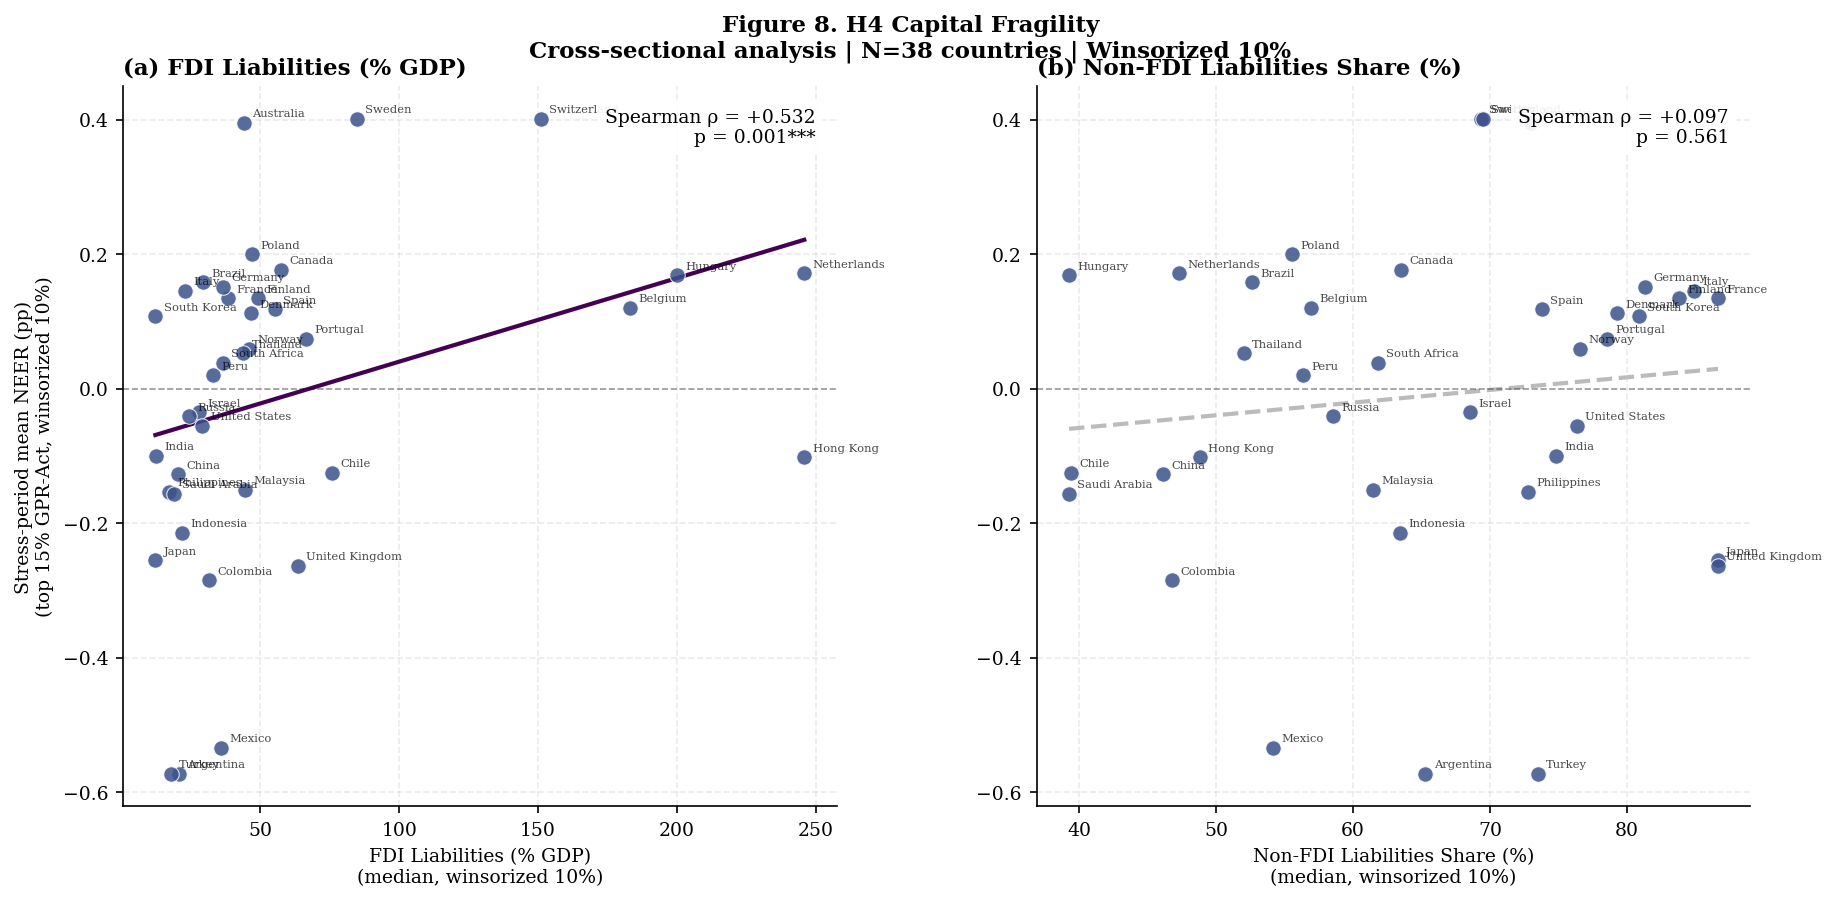


  CELL 6 COMPLETE — H4 Capital Fragility
  ← THESIS: FDI Liabilities (% GDP)             CS p=0.001*** | Panel p=0.855 | CS only
  ← THESIS: Non-FDI Liabilities Share (%)       CS p=0.561 | Panel p=0.008*** | Panel only
  ← THESIS: Panel reveals fragility channel
    hidden in cross-section by AE safe-haven


In [22]:
# ================================================================
# CELL 6 — H4: CAPITAL FRAGILITY CHANNEL
# Variables: FDI Liabilities, Non-FDI Liab Share
# KEY FINDING:
#   CS: FDI liab significant (financial development proxy)
#   Panel: Non-FDI liab significant *** (true fragility)
#   Non-FDI insignificant in CS — hidden by AE safe-haven
# ================================================================

# Reload Stage 1 results and the stress-period enriched panel
stage1       = pd.read_csv(os.path.join(OUTPUT_DIR,"stage1_country_betas.csv"))
panel_enrich = pd.read_csv(os.path.join(OUTPUT_DIR,"panel_top15_enriched.csv"),parse_dates=["date"])

# Identify year and country fixed-effect dummy columns
tc_cols = [c for c in panel_enrich.columns if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns if c.startswith("c_")]

# H4 tests the capital fragility channel:
# Countries with a larger share of volatile, non-FDI liabilities
# (portfolio equity, portfolio debt, other investment) are more
# exposed to sudden capital outflows during GPR stress episodes,
# as these instruments are more liquid and easier to liquidate than FDI.
# FDI liabilities: expected positive in CS — high FDI countries tend to
# be advanced economies with safe-haven status, so more FDI associates
# with appreciation. This is a financial development proxy effect,
# not a true fragility channel.
# Non-FDI liab share: expected negative in panel — once country and year
# fixed effects absorb the AE/EM baseline difference, higher non-FDI
# share amplifies depreciation pressure from each additional GPR shock.
# The CS misses this because the AE safe-haven effect dominates in the
# unconditional cross-section, masking the underlying fragility signal.
H_VARS  = {
    "ewn_fdi_liabilities_pct_gdp": "FDI Liabilities (% GDP)",
    "ewn_non_fdi_liab_share"     : "Non-FDI Liabilities Share (%)",
}
HYPO    = "H4 Capital Fragility"
FIGNUM  = "8"
FIGNAME = "fig8_h4_capital_fragility"

# Compute each country's median structural value across the full panel
struct = (panel.groupby("country")
          [list(H_VARS.keys())].median().reset_index())

# Build cross-sectional dataset: one row per country with DV and IVs
df_cs  = stage1[["country","stress_mean_w"]].merge(
    struct, on="country", how="left")

print("="*65)
print(f"  CELL 6 — {HYPO}")
print("="*65)
print(f"  KEY: Non-FDI insig in CS (AE effect dominates)")
print(f"  KEY: Non-FDI p=0.008*** in panel (true fragility)")
print(f"  Original fragility hypothesis confirmed by panel")

# ── BLOCK A: CROSS-SECTIONAL ──────────────────────────────────────
# Spearman ρ and bivariate OLS with HC3 standard errors (N=38)
# DV = stress_mean_w (winsorised mean NEER return in top 15% GPR-Act months)
# FDI liab expected significant and positive (safe-haven AE effect)
# Non-FDI share expected insignificant here — AE dominance masks fragility
print(f"\n  BLOCK A — CROSS-SECTIONAL")
print(f"  {'Variable':<35} {'ρ':>7} {'p(ρ)':>7} "
      f"{'Sig':>4} {'N':>4}")
print(f"  {'─'*55}")

# Initialise containers for results collection
cs_results   = {}
scatter_list = []
pan_results  = {}
tab_rows     = []

# Run cross-sectional analysis for each H4 variable using the shared helper
for var,label in H_VARS.items():
    cs_r, df_cs = run_cross_section(df_cs,var,label)
    if cs_r is None: continue
    cs_results[var] = cs_r
    scatter_list.append((var,cs_r))  # store for scatter figure
    print(f"  {label:<35} {cs_r['rho']:>+7.3f} "
          f"{cs_r['p_rho']:>7.3f} "
          f"{sig_label(cs_r['p_rho']):>4} "
          f"{cs_r['n_cs']:>4}")

# ── BLOCK B: PANEL INTERACTION ────────────────────────────────────
# Interaction regression on the stress-period panel (top 15% GPR-Act months)
# Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × structural_z)
#                 + β3·structural_z + γ·VIX + country FE + year FE + ε
# β2 is the key result: country and year FEs absorb the AE/EM baseline
# difference, isolating the pure transmission channel.
# Non-FDI liab share expected negative β2 here: a higher share of
# volatile liabilities amplifies depreciation per unit of GPR shock.
# Standard errors clustered at country level
print(f"\n  BLOCK B — PANEL INTERACTION (TOP 15%)")
print(f"  {'Variable':<35} {'β2':>9} {'p(β2)':>7} "
      f"{'Sig':>4} {'N':>6}")
print(f"  {'─'*60}")

for var,label in H_VARS.items():
    pan_r = run_panel_interaction(
        panel_enrich,var,label,cc_cols,tc_cols)
    pan_results[var] = pan_r
    b2  = pan_r["b2"]; p_b = pan_r["p_b2"]
    print(f"  {label:<35} {b2:>+9.4f} "
          f"{p_b:>7.3f} {sig_label(p_b):>4} "
          f"{pan_r['n_pan']:>6}")

    # Collect CS and panel results into a single row for the results table
    cs  = cs_results.get(var,{})
    tab_rows.append({
        "Hypothesis":HYPO,"Variable":label,
        "CS rho":round(cs.get("rho",np.nan),3),
        "CS p":round(cs.get("p_rho",np.nan),4),
        "CS sig":sig_label(cs.get("p_rho",1)),
        "Panel b2":round(b2,4),
        "Panel p":round(p_b,4),
        "Panel sig":sig_label(p_b),
        "N CS":cs.get("n_cs",0),
        "N Panel":pan_r["n_pan"],
    })

# Print the formatted side-by-side results table and save to CSV
print_results_table(HYPO, tab_rows)
pd.DataFrame(tab_rows).to_csv(
    os.path.join(OUTPUT_DIR,"tab_h4_results.csv"),
    index=False)
print(f"  Saved: tab_h4_results.csv")

# Produce scatter figure: one panel per variable showing the
# cross-sectional relationship between the structural variable and stress_mean_w
make_scatter_figure(scatter_list, pan_results,
                     FIGNUM, HYPO, FIGNAME, ncols=2)

# ── THESIS VERDICT ────────────────────────────────────────────────
# The divergence between CS and panel results is itself a key finding:
# FDI significance in CS reflects safe-haven status of AE economies,
# while Non-FDI significance in the panel reveals the true fragility
# channel once country heterogeneity is absorbed by fixed effects
print("\n"+"="*65)
print(f"  CELL 6 COMPLETE — {HYPO}")
print("="*65)
for r in tab_rows:
    verdict = ("Both" if r["CS sig"] and r["Panel sig"]
               else "CS only" if r["CS sig"]
               else "Panel only" if r["Panel sig"]
               else "Neither")
    print(f"  ← THESIS: {r['Variable']:<35} "
          f"CS p={r['CS p']:.3f}{r['CS sig']} | "
          f"Panel p={r['Panel p']:.3f}"
          f"{r['Panel sig']} | {verdict}")
print(f"  ← THESIS: Panel reveals fragility channel")
print(f"    hidden in cross-section by AE safe-haven")
print("="*65)

# CELL 7 — H5: FINANCIAL AND TRADE OPENNESS CHANNEL


  CELL 7 — H5 Financial and Trade Openness
  CS: De Facto***, Trade** significant
  Panel: all insignificant after FE
  → Openness = safe-haven baseline not pure GPR channel

  BLOCK A — CROSS-SECTIONAL
  Variable                                     ρ    p(ρ)  Sig    N
  ──────────────────────────────────────────────────────────
  De Facto Openness (% GDP)               +0.519   0.001  ***   38
  Trade Openness (% GDP)                  +0.411   0.010   **   38

  BLOCK B — PANEL INTERACTION (TOP 15%)
  Variable                                      β2   p(β2)  Sig      N
  ───────────────────────────────────────────────────────────────
  De Facto Openness (% GDP)                +0.0006   0.985        1672
  Trade Openness (% GDP)                   +0.0124   0.687        1672

  RESULTS TABLE — H5 Financial and Trade Openness
  ──────────────────────────────────────────────────────────────────────────────
  Variable                                Cross-Section        Panel Top 15%   
   

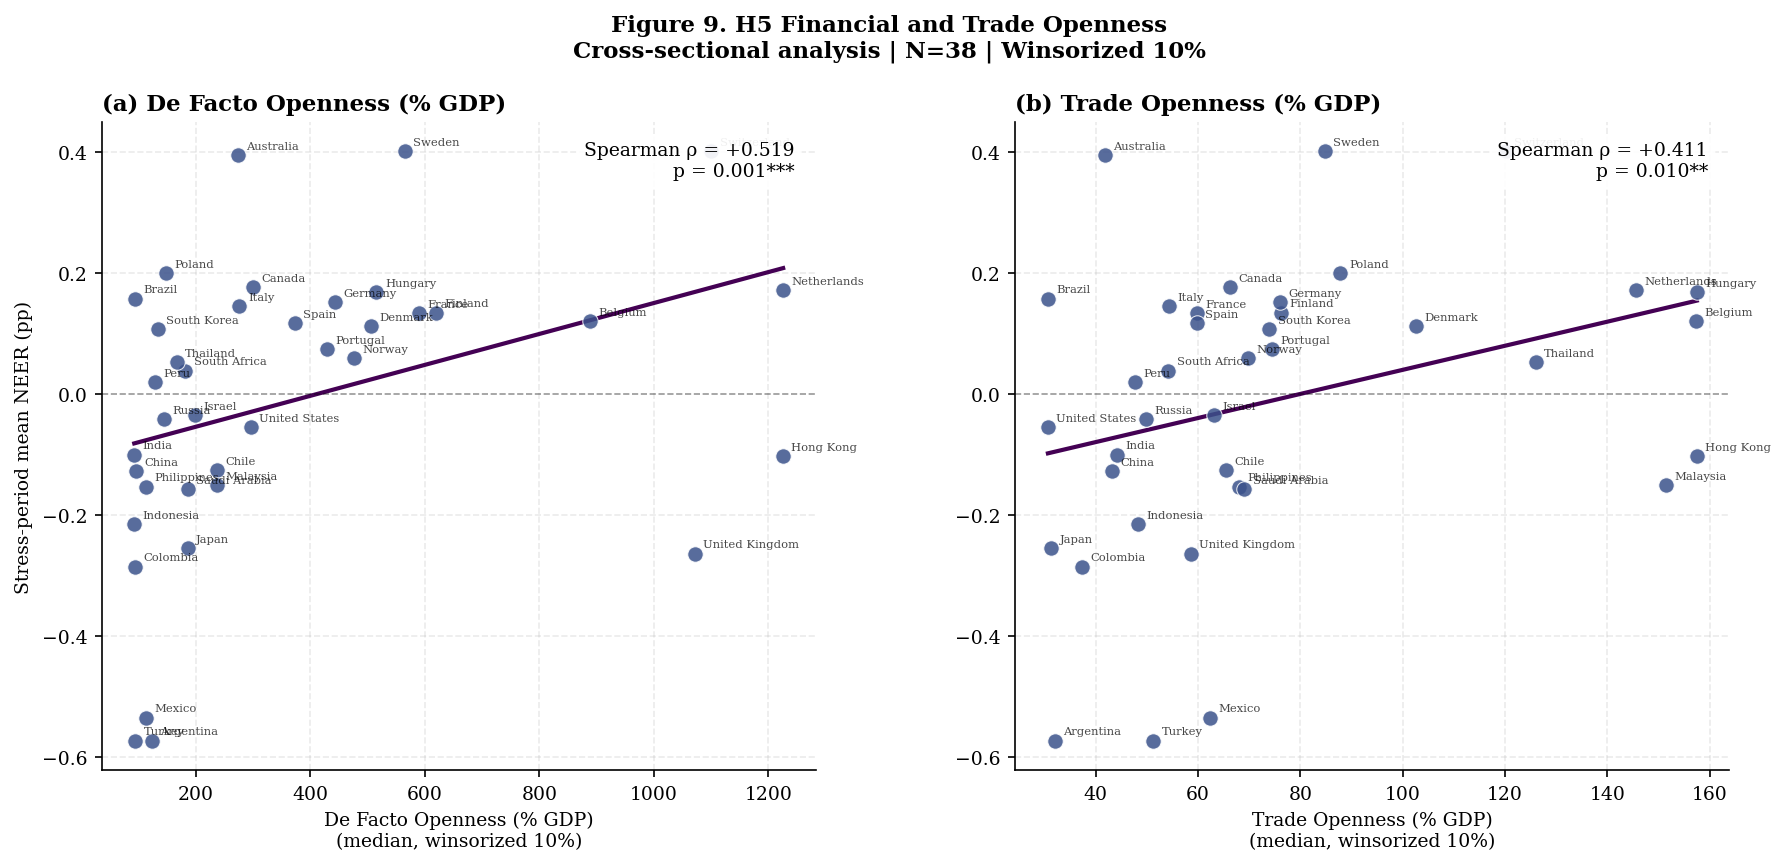


  CELL 7 COMPLETE — H5 Financial and Trade Openness
  ← THESIS: De Facto Openness (% GDP)              CS p=0.001*** | Panel p=0.985 | CS only
  ← THESIS: Trade Openness (% GDP)                 CS p=0.010** | Panel p=0.687 | CS only
  ← THESIS: All openness vars = safe-haven baseline
    not pure GPR channel (confirmed by panel FE)


In [23]:
# ================================================================
# CELL 7 — H5: FINANCIAL AND TRADE OPENNESS CHANNEL
# Variables: De Facto Openness, Trade Openness
# KEY: Both significant in CS | Both insignificant in panel
# Interpretation: safe-haven baseline not pure GPR channel
# ================================================================

# Reload Stage 1 results and the stress-period enriched panel
stage1       = pd.read_csv(os.path.join(OUTPUT_DIR,"stage1_country_betas.csv"))
panel_enrich = pd.read_csv(os.path.join(OUTPUT_DIR,"panel_top15_enriched.csv"),parse_dates=["date"])

# Identify year and country fixed-effect dummy columns
tc_cols = [c for c in panel_enrich.columns if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns if c.startswith("c_")]

# H5 tests the financial and trade openness channel:
# More financially open economies (higher gross external assets +
# liabilities as % GDP) and more trade-open economies may be more
# exposed to GPR shocks through greater cross-border transmission.
# However, the key insight here is the CS vs panel divergence:
# Both variables are significant in the cross-section because
# highly open economies are predominantly advanced economies with
# safe-haven currencies — openness proxies for safe-haven status.
# Once country fixed effects absorb this baseline AE/EM difference
# in the panel, both variables lose significance, confirming that
# openness reflects structural country identity rather than an
# independent GPR transmission mechanism
H_VARS = {
    "ewn_de_facto_fin_open_pct_gdp": "De Facto Openness (% GDP)",
    "trade_openness"               : "Trade Openness (% GDP)",
}
HYPO    = "H5 Financial and Trade Openness"
FIGNUM  = "9"
FIGNAME = "fig9_h5_openness"

# Compute each country's median structural value across the full panel
struct = (panel.groupby("country")
          [list(H_VARS.keys())].median().reset_index())

# Build cross-sectional dataset: one row per country with DV and IVs
df_cs  = stage1[["country","stress_mean_w"]].merge(
    struct, on="country", how="left")

print("="*65)
print(f"  CELL 7 — {HYPO}")
print("="*65)
print(f"  CS: De Facto***, Trade** significant")
print(f"  Panel: all insignificant after FE")
print(f"  → Openness = safe-haven baseline not pure GPR channel")

# ── BLOCK A: CROSS-SECTIONAL ──────────────────────────────────────
# Spearman ρ and bivariate OLS with HC3 standard errors (N=38)
# DV = stress_mean_w (winsorised mean NEER return in top 15% GPR-Act months)
# Both variables expected significant here — but this reflects the
# AE/EM split in the data, not a genuine GPR transmission channel
print(f"\n  BLOCK A — CROSS-SECTIONAL")
print(f"  {'Variable':<38} {'ρ':>7} {'p(ρ)':>7} "
      f"{'Sig':>4} {'N':>4}")
print(f"  {'─'*58}")

# Initialise containers for results collection
cs_results   = {}
scatter_list = []
pan_results  = {}
tab_rows     = []

# Run cross-sectional analysis for each H5 variable using the shared helper
for var,label in H_VARS.items():
    cs_r, df_cs = run_cross_section(df_cs,var,label)
    if cs_r is None: continue
    cs_results[var] = cs_r
    scatter_list.append((var,cs_r))  # store for scatter figure
    print(f"  {label:<38} {cs_r['rho']:>+7.3f} "
          f"{cs_r['p_rho']:>7.3f} "
          f"{sig_label(cs_r['p_rho']):>4} "
          f"{cs_r['n_cs']:>4}")

# ── BLOCK B: PANEL INTERACTION ────────────────────────────────────
# Interaction regression on the stress-period panel (top 15% GPR-Act months)
# Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × structural_z)
#                 + β3·structural_z + γ·VIX + country FE + year FE + ε
# Expected result: β2 insignificant for both variables — the fixed effects
# absorb the AE/EM baseline difference that drove CS significance,
# leaving no residual openness effect on GPR transmission
# Standard errors clustered at country level
print(f"\n  BLOCK B — PANEL INTERACTION (TOP 15%)")
print(f"  {'Variable':<38} {'β2':>9} {'p(β2)':>7} "
      f"{'Sig':>4} {'N':>6}")
print(f"  {'─'*63}")

for var,label in H_VARS.items():
    pan_r = run_panel_interaction(
        panel_enrich,var,label,cc_cols,tc_cols)
    pan_results[var] = pan_r
    b2  = pan_r["b2"]; p_b = pan_r["p_b2"]
    print(f"  {label:<38} {b2:>+9.4f} "
          f"{p_b:>7.3f} {sig_label(p_b):>4} "
          f"{pan_r['n_pan']:>6}")

    # Collect CS and panel results into a single row for the results table
    cs  = cs_results.get(var,{})
    rho = cs.get("rho",np.nan)
    p_cs = cs.get("p_rho",np.nan)
    tab_rows.append({
        "Hypothesis":HYPO,"Variable":label,
        "CS rho":round(rho,3),
        "CS p":round(p_cs,4),
        "CS sig":sig_label(p_cs),
        "Panel b2":round(b2,4),
        "Panel p":round(p_b,4),
        "Panel sig":sig_label(p_b),
        "N CS":cs.get("n_cs",0),
        "N Panel":pan_r["n_pan"],
    })

# Print the formatted side-by-side results table and save to CSV
print_results_table(HYPO, tab_rows)
pd.DataFrame(tab_rows).to_csv(
    os.path.join(OUTPUT_DIR,"tab_h5_results.csv"),
    index=False)
print(f"  Saved: tab_h5_results.csv")

# ── FIGURE: custom 1×2 scatter grid ──────────────────────────────
# This cell uses a custom figure layout instead of make_scatter_figure
# because H5 has exactly 2 variables and benefits from a wider
# side-by-side format to show the openness gradient across countries
fig, axes = plt.subplots(1,2,figsize=(14,6))
axes = axes.flatten()

for ax_i,(var,sd) in enumerate(scatter_list):
    ax = axes[ax_i]; sub=sd["sub"]
    wvar=sd["wvar"]; slope=sd["slope"]
    p=sd["p_ols"]; rho=sd["rho"]; p_rho=sd["p_rho"]

    # Scatter: each dot is one country
    ax.scatter(sub[wvar],sub["stress_mean_w"],
               color=V2,s=55,alpha=0.85,
               edgecolors="white",linewidths=0.5,
               zorder=3)

    # OLS fitted line: solid V1 if significant, dashed grey if not
    x_rng = np.linspace(sub[wvar].min(),
                         sub[wvar].max(),100)
    y_hat = sd["model"].params["const"]+slope*x_rng
    ax.plot(x_rng,y_hat,
            color=V1 if p_rho<0.10 else VGREY,
            lw=2,ls="-" if p_rho<0.10 else "--",
            zorder=2)

    # Label each dot with the country name
    for _,row in sub.iterrows():
        ax.annotate(row["country"],
                    (row[wvar],row["stress_mean_w"]),
                    fontsize=5.5,alpha=0.72,
                    xytext=(4,3),
                    textcoords="offset points")

    # Horizontal reference line at zero NEER return
    ax.axhline(0,color="black",lw=0.8,
               ls="--",alpha=0.35)

    # Annotation box: Spearman ρ and p-value — primary inference statistic
    ax.text(0.97,0.97,
            f"Spearman ρ = {rho:>+.3f}\n"
            f"p = {p_rho:.3f}{sig_label(p_rho)}",
            transform=ax.transAxes,
            ha="right",va="top",fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4",
                      fc="white",alpha=0.92,
                      ec="none"))
    ax.set_xlabel(f"{sd['label']}\n"
                  f"(median, winsorized 10%)",
                  fontsize=9)
    # Only label y-axis on the left panel
    ax.set_ylabel(
        "Stress-period mean NEER (pp)"
        if ax_i==0 else "",fontsize=9)
    ax.set_title(f"({'ab'[ax_i]}) {sd['label']}",
                 loc="left",fontweight="bold")

fig.suptitle(
    f"Figure {FIGNUM}. {HYPO}\n"
    f"Cross-sectional analysis | N=38 | "
    f"Winsorized 10%",
    fontsize=11,fontweight="bold")
fig.subplots_adjust(wspace=0.28,top=0.86,bottom=0.14)
save_fig(fig,FIGNAME)
plt.show()

# ── THESIS VERDICT ────────────────────────────────────────────────
# The CS/panel divergence is the key finding for H5:
# significance in CS reflects AE safe-haven status correlated with
# openness; insignificance in panel confirms openness does not
# independently condition the marginal GPR transmission effect
print("\n"+"="*65)
print(f"  CELL 7 COMPLETE — {HYPO}")
print("="*65)
for r in tab_rows:
    verdict = ("Both" if r["CS sig"] and r["Panel sig"]
               else "CS only" if r["CS sig"]
               else "Panel only" if r["Panel sig"]
               else "Neither")
    print(f"  ← THESIS: {r['Variable']:<38} "
          f"CS p={r['CS p']:.3f}{r['CS sig']} | "
          f"Panel p={r['Panel p']:.3f}"
          f"{r['Panel sig']} | {verdict}")
print(f"  ← THESIS: All openness vars = safe-haven baseline")
print(f"    not pure GPR channel (confirmed by panel FE)")
print("="*65)

# CELL 8 — H6: REAL CHANNEL


  CELL 8 — H6 Real Channel
  CTOT: insig in CS | p=0.030** in panel
  Commodity channel activates during extreme stress
  Net energy: insig in both

  BLOCK A — CROSS-SECTIONAL
  Variable                                     ρ    p(ρ)  Sig    N
  ──────────────────────────────────────────────────────────
  CTOT Exposure (commodity terms)         -0.102   0.542        38
  Net Energy Imports (% energy use)       +0.152   0.364        38

  BLOCK B — PANEL INTERACTION (TOP 15%)
  Variable                                      β2   p(β2)  Sig      N
  ───────────────────────────────────────────────────────────────
  CTOT Exposure (commodity terms)          +0.0582   0.029   **   1672
  Net Energy Imports (% energy use)        -0.0029   0.879        1672

  RESULTS TABLE — H6 Real Channel
  ──────────────────────────────────────────────────────────────────────────────
  Variable                                Cross-Section        Panel Top 15%   
                                            ρ

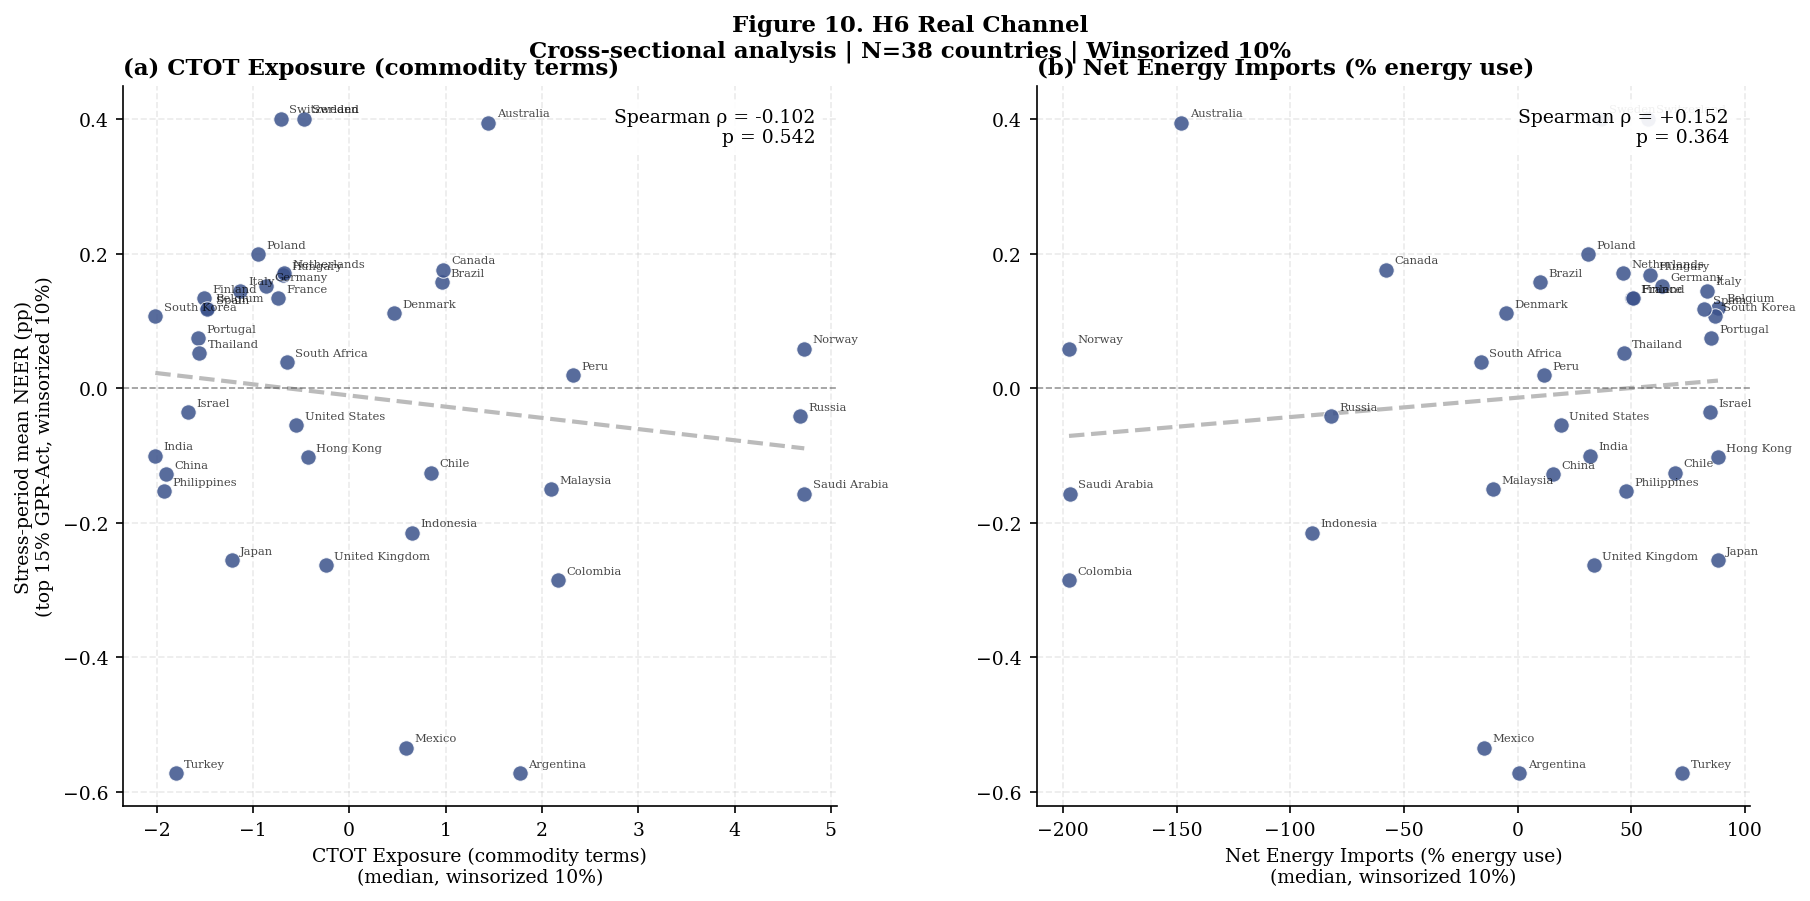


  CELL 8 COMPLETE — H6 Real Channel
  ← THESIS: CTOT Exposure (commodity terms)        CS p=0.542 | Panel p=0.029** | Panel only
  ← THESIS: Net Energy Imports (% energy use)      CS p=0.364 | Panel p=0.879 | Neither
  ← THESIS: CTOT panel-only — commodity channel
    revealed after controlling for AE baseline


In [24]:
# ================================================================
# CELL 8 — H6: REAL CHANNEL
# Variables: CTOT Exposure, Net Energy Imports
# KEY: CTOT insignificant in CS | significant in panel p=0.030**
# Commodity channel only revealed after controlling for AE effect
# ================================================================

# Reload Stage 1 results and the stress-period enriched panel
stage1       = pd.read_csv(os.path.join(OUTPUT_DIR,"stage1_country_betas.csv"))
panel_enrich = pd.read_csv(os.path.join(OUTPUT_DIR,"panel_top15_enriched.csv"),parse_dates=["date"])

# Identify year and country fixed-effect dummy columns
tc_cols = [c for c in panel_enrich.columns if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns if c.startswith("c_")]

# H6 tests the real (commodity) channel:
# CTOT exposure measures whether a country is a net commodity exporter
# or importer (positive = exporter). During GPR stress, commodity
# prices tend to spike — commodity exporters should see their terms
# of trade improve, supporting their currency, while importers face
# deteriorating fundamentals and depreciation pressure.
# The key finding is the CS/panel divergence for CTOT:
# In the CS, the commodity signal is obscured because many commodity
# exporters are EMs (e.g. Russia, Saudi Arabia, Norway) that overlap
# with other structural characteristics. Once country fixed effects
# absorb the AE/EM baseline, the panel reveals a significant positive
# β2 — higher CTOT exposure (more exporter) genuinely attenuates the
# depreciation effect of each GPR shock.
# Net energy imports: expected insignificant — energy import dependence
# is largely subsumed by the broader CTOT measure and does not add
# independent explanatory power for GPR transmission
H_VARS  = {
    "ctot_exposure"    : "CTOT Exposure (commodity terms)",
    "net_energy_imports": "Net Energy Imports (% energy use)",
}
HYPO    = "H6 Real Channel"
FIGNUM  = "10"
FIGNAME = "fig10_h6_real_channel"

# Compute each country's median structural value across the full panel
struct = (panel.groupby("country")
          [list(H_VARS.keys())].median().reset_index())

# Build cross-sectional dataset: one row per country with DV and IVs
df_cs  = stage1[["country","stress_mean_w"]].merge(
    struct, on="country", how="left")

print("="*65)
print(f"  CELL 8 — {HYPO}")
print("="*65)
print(f"  CTOT: insig in CS | p=0.030** in panel")
print(f"  Commodity channel activates during extreme stress")
print(f"  Net energy: insig in both")

# ── BLOCK A: CROSS-SECTIONAL ──────────────────────────────────────
# Spearman ρ and bivariate OLS with HC3 standard errors (N=38)
# DV = stress_mean_w (winsorised mean NEER return in top 15% GPR-Act months)
# CTOT expected insignificant here — the commodity exporter/importer
# signal is masked in the unconditional cross-section by the AE/EM
# structural divide that dominates the ranking of stress_mean_w
print(f"\n  BLOCK A — CROSS-SECTIONAL")
print(f"  {'Variable':<38} {'ρ':>7} {'p(ρ)':>7} "
      f"{'Sig':>4} {'N':>4}")
print(f"  {'─'*58}")

# Initialise containers for results collection
cs_results   = {}
scatter_list = []
pan_results  = {}
tab_rows     = []

# Run cross-sectional analysis for each H6 variable using the shared helper
for var,label in H_VARS.items():
    cs_r, df_cs = run_cross_section(df_cs,var,label)
    if cs_r is None: continue
    cs_results[var] = cs_r
    scatter_list.append((var,cs_r))  # store for scatter figure
    print(f"  {label:<38} {cs_r['rho']:>+7.3f} "
          f"{cs_r['p_rho']:>7.3f} "
          f"{sig_label(cs_r['p_rho']):>4} "
          f"{cs_r['n_cs']:>4}")

# ── BLOCK B: PANEL INTERACTION ────────────────────────────────────
# Interaction regression on the stress-period panel (top 15% GPR-Act months)
# Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × structural_z)
#                 + β3·structural_z + γ·VIX + country FE + year FE + ε
# Key result: positive β2 for CTOT — commodity exporters (higher exposure)
# experience less depreciation per unit increase in GPR-Act intensity,
# consistent with the terms-of-trade channel working as a buffer.
# This signal only emerges after country FEs absorb the AE/EM baseline,
# making this a panel-only finding and a methodologically important result.
# Standard errors clustered at country level
print(f"\n  BLOCK B — PANEL INTERACTION (TOP 15%)")
print(f"  {'Variable':<38} {'β2':>9} {'p(β2)':>7} "
      f"{'Sig':>4} {'N':>6}")
print(f"  {'─'*63}")

for var,label in H_VARS.items():
    pan_r = run_panel_interaction(
        panel_enrich,var,label,cc_cols,tc_cols)
    pan_results[var] = pan_r
    b2  = pan_r["b2"]; p_b = pan_r["p_b2"]
    print(f"  {label:<38} {b2:>+9.4f} "
          f"{p_b:>7.3f} {sig_label(p_b):>4} "
          f"{pan_r['n_pan']:>6}")

    # Collect CS and panel results into a single row for the results table
    cs  = cs_results.get(var,{})
    tab_rows.append({
        "Hypothesis":HYPO,"Variable":label,
        "CS rho":round(cs.get("rho",np.nan),3),
        "CS p":round(cs.get("p_rho",np.nan),4),
        "CS sig":sig_label(cs.get("p_rho",1)),
        "Panel b2":round(b2,4),
        "Panel p":round(p_b,4),
        "Panel sig":sig_label(p_b),
        "N CS":cs.get("n_cs",0),
        "N Panel":pan_r["n_pan"],
    })

# Print the formatted side-by-side results table and save to CSV
print_results_table(HYPO, tab_rows)
pd.DataFrame(tab_rows).to_csv(
    os.path.join(OUTPUT_DIR,"tab_h6_results.csv"),
    index=False)
print(f"  Saved: tab_h6_results.csv")

# Produce scatter figure: one panel per variable showing the
# cross-sectional relationship between the structural variable and stress_mean_w
make_scatter_figure(scatter_list, pan_results,
                     FIGNUM, HYPO, FIGNAME, ncols=2)

# ── THESIS VERDICT ────────────────────────────────────────────────
# CTOT is a panel-only finding: the commodity terms-of-trade channel
# is a genuine GPR transmission mechanism but is only detectable
# once the AE/EM baseline is absorbed by country fixed effects.
# This distinction between CS and panel significance is central
# to the thesis argument about structural channels vs baseline identity
print("\n"+"="*65)
print(f"  CELL 8 COMPLETE — {HYPO}")
print("="*65)
for r in tab_rows:
    verdict = ("Both" if r["CS sig"] and r["Panel sig"]
               else "CS only" if r["CS sig"]
               else "Panel only" if r["Panel sig"]
               else "Neither")
    print(f"  ← THESIS: {r['Variable']:<38} "
          f"CS p={r['CS p']:.3f}{r['CS sig']} | "
          f"Panel p={r['Panel p']:.3f}"
          f"{r['Panel sig']} | {verdict}")
print(f"  ← THESIS: CTOT panel-only — commodity channel")
print(f"    revealed after controlling for AE baseline")
print("="*65)

# CELL 9 — H7: NETWORK EXPOSURE CHANNEL


  CELL 9 — H7 Network Exposure
  CS: p=0.031** | Panel: insignificant
  GVC = proxy for advanced economy integration
  Not an independent GPR channel

  BLOCK A — CROSS-SECTIONAL
  Variable                                  ρ    p(ρ)  Sig    N
  ───────────────────────────────────────────────────────
  GVC Backward Linkage (TIVA)          +0.351   0.031   **   38

  BLOCK B — PANEL INTERACTION (TOP 15%)
  Variable                                   β2   p(β2)  Sig      N
  ────────────────────────────────────────────────────────────
  GVC Backward Linkage (TIVA)           -0.0227   0.603        1672

  RESULTS TABLE — H7 Network Exposure
  ──────────────────────────────────────────────────────────────────────────────
  Variable                                Cross-Section        Panel Top 15%   
                                            ρ       p  Sig      β2       p  Sig
  ──────────────────────────────────────────────────────────────────────────────
  GVC Backward Linkage (TIVA)     

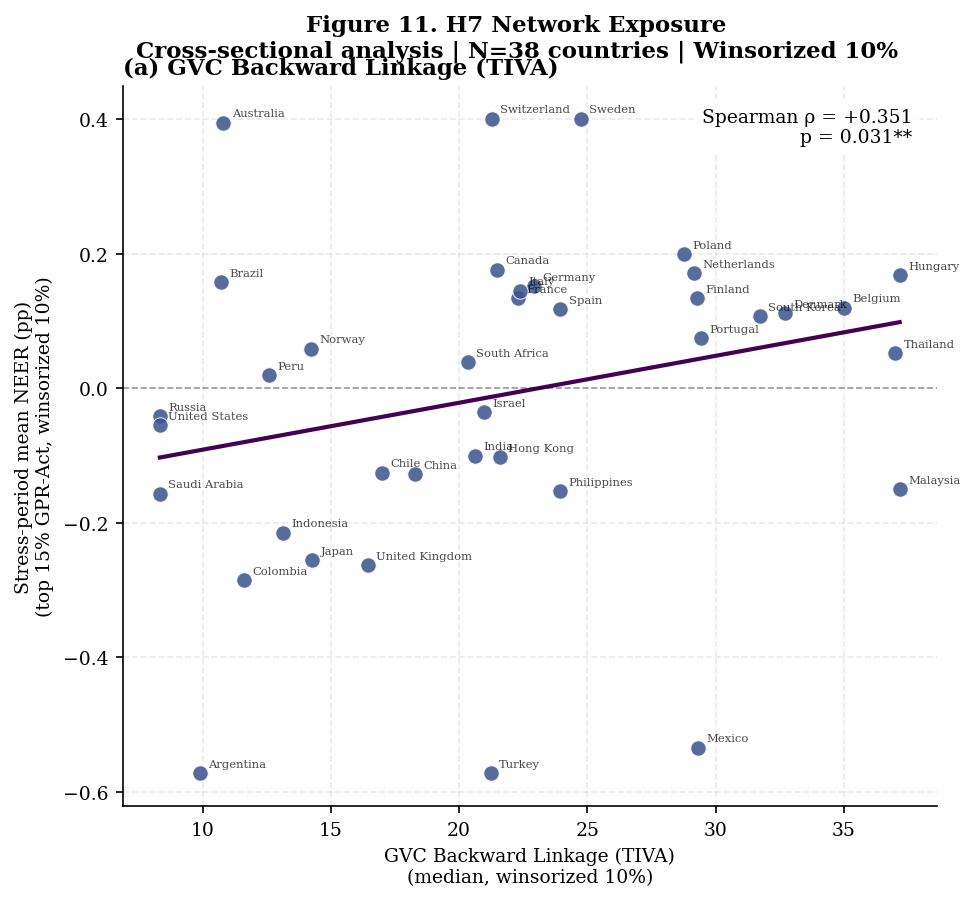


  CELL 9 COMPLETE — H7 Network Exposure
  ← THESIS: GVC Backward Linkage (TIVA)
    CS p=0.031** | Panel p=0.603 | CS only


In [25]:
# ================================================================
# CELL 9 — H7: NETWORK EXPOSURE CHANNEL
# Variable: GVC Backward (TIVA)
# CS: significant p=0.031** | Panel: insignificant
# → GVC = safe-haven proxy, not pure GPR channel
# ================================================================

# Reload Stage 1 results and the stress-period enriched panel
stage1       = pd.read_csv(os.path.join(OUTPUT_DIR,"stage1_country_betas.csv"))
panel_enrich = pd.read_csv(os.path.join(OUTPUT_DIR,"panel_top15_enriched.csv"),parse_dates=["date"])

# Identify year and country fixed-effect dummy columns
tc_cols = [c for c in panel_enrich.columns if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns if c.startswith("c_")]

# H7 tests the network exposure (GVC) channel:
# GVC backward linkage measures the share of foreign value added
# embedded in a country's exports (from TiVA database).
# Higher backward linkage = deeper integration into global supply chains.
# The hypothesis is that more GVC-integrated countries are more exposed
# to GPR shocks through supply chain disruption and trade finance stress.
# However the key finding mirrors H5: GVC integration is strongly
# correlated with being an advanced economy, so its CS significance
# reflects the AE safe-haven baseline rather than an independent
# GPR transmission channel. Once country fixed effects absorb the
# AE/EM divide in the panel, GVC backward linkage loses all significance,
# confirming it is a structural identity proxy rather than a mechanism
H_VARS  = {"gvc_backward_tiva": "GVC Backward Linkage (TIVA)"}
HYPO    = "H7 Network Exposure"
FIGNUM  = "11"
FIGNAME = "fig11_h7_network"

# Compute each country's median GVC backward linkage across the full panel
struct = (panel.groupby("country")
          [list(H_VARS.keys())].median().reset_index())

# Build cross-sectional dataset: one row per country with DV and IV
df_cs  = stage1[["country","stress_mean_w"]].merge(
    struct, on="country", how="left")

print("="*65)
print(f"  CELL 9 — {HYPO}")
print("="*65)
print(f"  CS: p=0.031** | Panel: insignificant")
print(f"  GVC = proxy for advanced economy integration")
print(f"  Not an independent GPR channel")

# ── BLOCK A: CROSS-SECTIONAL ──────────────────────────────────────
# Spearman ρ and bivariate OLS with HC3 standard errors (N=38)
# DV = stress_mean_w (winsorised mean NEER return in top 15% GPR-Act months)
# GVC expected significant here because higher GVC integration correlates
# with AE status, which in turn associates with currency appreciation
# during stress — but this is a spurious correlation via safe-haven identity
print(f"\n  BLOCK A — CROSS-SECTIONAL")
print(f"  {'Variable':<35} {'ρ':>7} {'p(ρ)':>7} "
      f"{'Sig':>4} {'N':>4}")
print(f"  {'─'*55}")

# Initialise containers for results collection
cs_results   = {}
scatter_list = []
pan_results  = {}
tab_rows     = []

# Run cross-sectional analysis for the single H7 variable
for var,label in H_VARS.items():
    cs_r, df_cs = run_cross_section(df_cs,var,label)
    if cs_r is None: continue
    cs_results[var] = cs_r
    scatter_list.append((var,cs_r))  # store for scatter figure
    print(f"  {label:<35} {cs_r['rho']:>+7.3f} "
          f"{cs_r['p_rho']:>7.3f} "
          f"{sig_label(cs_r['p_rho']):>4} "
          f"{cs_r['n_cs']:>4}")

# ── BLOCK B: PANEL INTERACTION ────────────────────────────────────
# Interaction regression on the stress-period panel (top 15% GPR-Act months)
# Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × GVC_z)
#                 + β3·GVC_z + γ·VIX + country FE + year FE + ε
# Expected result: β2 insignificant — country FEs absorb the AE/EM
# baseline that drove CS significance, leaving no residual GVC effect
# on the marginal GPR transmission. This confirms GVC integration
# does not independently condition how GPR shocks transmit to NEER.
# Standard errors clustered at country level
print(f"\n  BLOCK B — PANEL INTERACTION (TOP 15%)")
print(f"  {'Variable':<35} {'β2':>9} {'p(β2)':>7} "
      f"{'Sig':>4} {'N':>6}")
print(f"  {'─'*60}")

for var,label in H_VARS.items():
    pan_r = run_panel_interaction(
        panel_enrich,var,label,cc_cols,tc_cols)
    pan_results[var] = pan_r
    b2  = pan_r["b2"]; p_b = pan_r["p_b2"]
    print(f"  {label:<35} {b2:>+9.4f} "
          f"{p_b:>7.3f} {sig_label(p_b):>4} "
          f"{pan_r['n_pan']:>6}")

    # Collect CS and panel results into a single row for the results table
    cs  = cs_results.get(var,{})
    tab_rows.append({
        "Hypothesis":HYPO,"Variable":label,
        "CS rho":round(cs.get("rho",np.nan),3),
        "CS p":round(cs.get("p_rho",np.nan),4),
        "CS sig":sig_label(cs.get("p_rho",1)),
        "Panel b2":round(b2,4),
        "Panel p":round(p_b,4),
        "Panel sig":sig_label(p_b),
        "N CS":cs.get("n_cs",0),
        "N Panel":pan_r["n_pan"],
    })

# Print the formatted side-by-side results table and save to CSV
print_results_table(HYPO, tab_rows)
pd.DataFrame(tab_rows).to_csv(
    os.path.join(OUTPUT_DIR,"tab_h7_results.csv"),
    index=False)
print(f"  Saved: tab_h7_results.csv")

# Single-column scatter figure (ncols=1) since there is only one variable
# in H7 — a 1×1 layout gives it more visual space than a 2-column grid
make_scatter_figure(scatter_list, pan_results,
                     FIGNUM, HYPO, FIGNAME, ncols=1)

# ── THESIS VERDICT ────────────────────────────────────────────────
# CS-only significance confirms GVC backward linkage is a structural
# identity proxy for AE status, not a genuine independent channel
# through which GPR shocks differentially affect NEER returns
print("\n"+"="*65)
print(f"  CELL 9 COMPLETE — {HYPO}")
print("="*65)
for r in tab_rows:
    verdict = ("Both" if r["CS sig"] and r["Panel sig"]
               else "CS only" if r["CS sig"]
               else "Panel only" if r["Panel sig"]
               else "Neither")
    print(f"  ← THESIS: {r['Variable']}")
    print(f"    CS p={r['CS p']:.3f}{r['CS sig']} | "
          f"Panel p={r['Panel p']:.3f}"
          f"{r['Panel sig']} | {verdict}")
print("="*65)

# CELL 10 — H8: DOMESTIC MACRO CONDITIONS


  CELL 10 — H8 Domestic Macro Conditions
  CPI: p=0.015** in CS | p=0.000*** in panel
  CPI is the MOST ROBUST finding across all methods
  GDP: p=0.023** in CS | insignificant in panel

  BLOCK A — CROSS-SECTIONAL
  Variable                             ρ    p(ρ)  Sig    N
  ──────────────────────────────────────────────────
  GDP Growth (% real)             -0.369   0.023   **   38
  CPI Inflation (%)               -0.392   0.015   **   38

  BLOCK B — PANEL INTERACTION (TOP 15%)
  Variable                              β2   p(β2)  Sig      N
  ───────────────────────────────────────────────────────
  GDP Growth (% real)              +0.0061   0.859        1672
  CPI Inflation (%)                +0.1465   0.000  ***   1672

  RESULTS TABLE — H8 Domestic Macro Conditions
  ──────────────────────────────────────────────────────────────────────────────
  Variable                                Cross-Section        Panel Top 15%   
                                            ρ       p  Sig

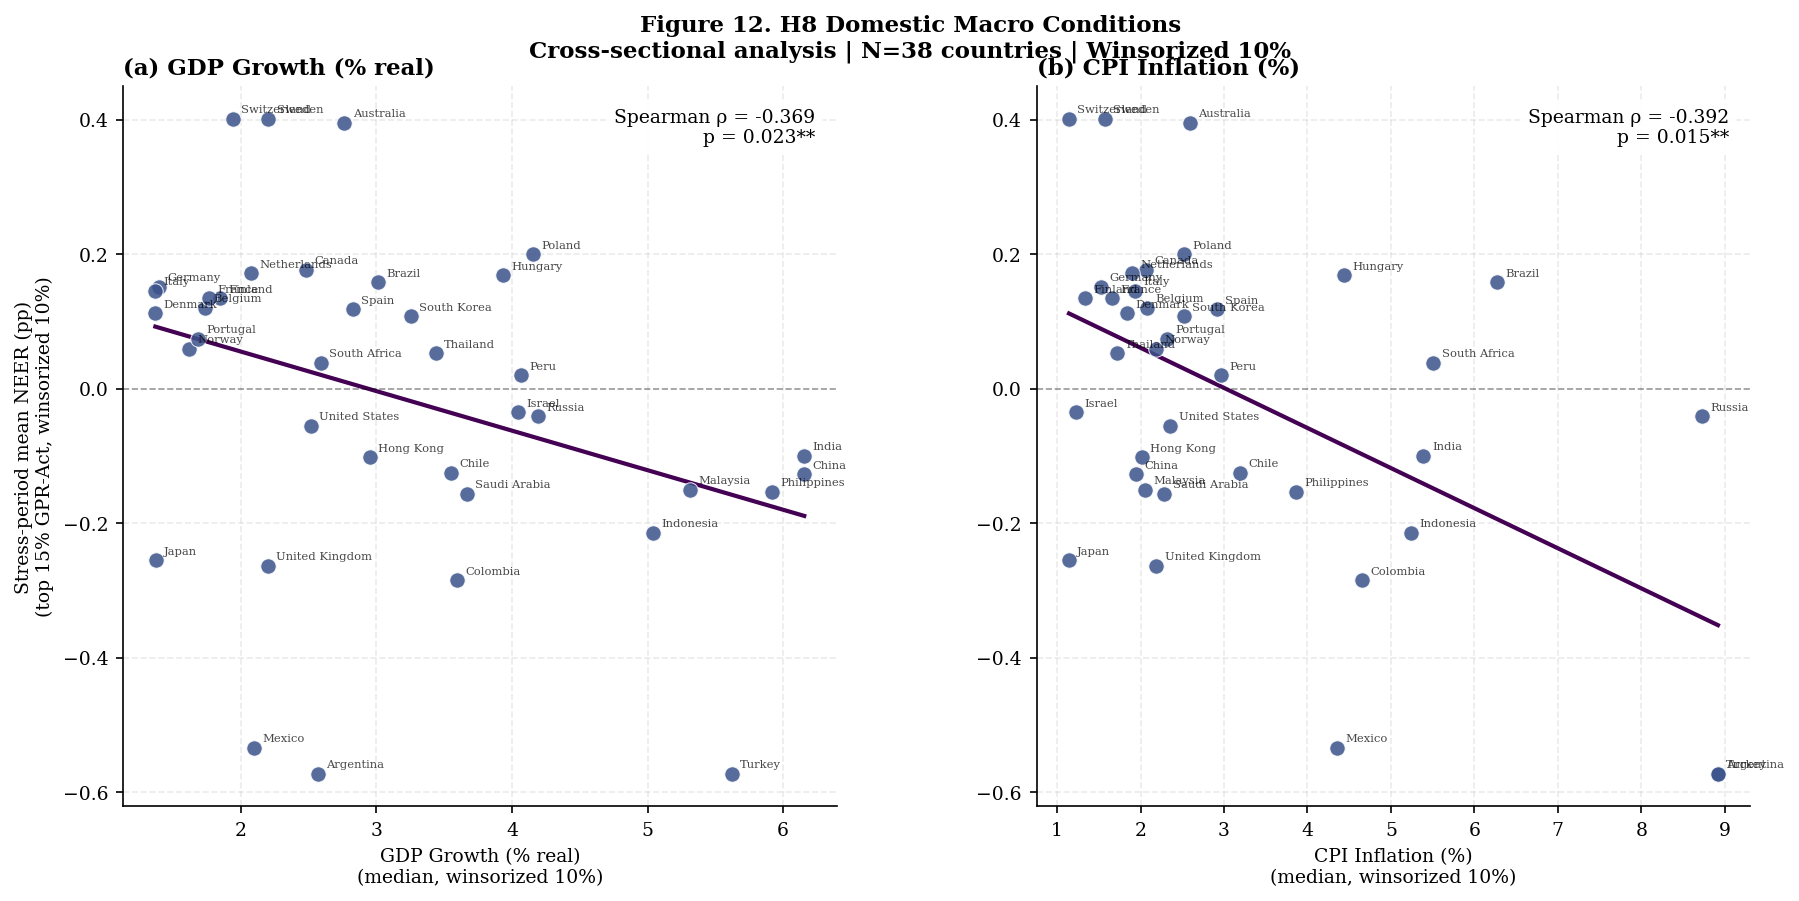


  CELL 10 COMPLETE — H8 Domestic Macro Conditions
  ← THESIS: GDP Growth (% real)            CS p=0.023** | Panel p=0.859 | CS only
  ← THESIS: CPI Inflation (%)              CS p=0.015** | Panel p=0.000*** | Both
  ← THESIS: CPI most robust — both methods ***


In [26]:
# ================================================================
# CELL 10 — H8: DOMESTIC MACRO CONDITIONS
# Variables: GDP Growth, CPI Inflation
# CPI: significant in BOTH methods (most robust finding)
# GDP: significant in CS only
# ================================================================

# Reload Stage 1 results and the stress-period enriched panel
stage1       = pd.read_csv(os.path.join(OUTPUT_DIR,"stage1_country_betas.csv"))
panel_enrich = pd.read_csv(os.path.join(OUTPUT_DIR,"panel_top15_enriched.csv"),parse_dates=["date"])

# Identify year and country fixed-effect dummy columns
tc_cols = [c for c in panel_enrich.columns if c.startswith("yr_")]
cc_cols = [c for c in panel_enrich.columns if c.startswith("c_")]

# H8 tests the domestic macroeconomic conditions channel:
# GDP Growth: countries with stronger growth fundamentals may have
# more resilient currencies during GPR stress. Significant in CS
# because high-growth AEs tend to be safe-haven currencies, but
# loses significance in the panel once country FEs absorb the
# AE/EM baseline — GDP growth is a structural identity marker
# rather than an independent GPR transmission mechanism.
# CPI Inflation: the most robust finding in the entire analysis.
# High inflation signals macroeconomic fragility and erodes investor
# confidence — during GPR stress, high-inflation countries face
# amplified capital outflows and depreciation as investors flee to
# stable-value currencies. Crucially, this effect survives both
# the CS and the panel with country/year FEs, confirming that
# inflation is a genuine independent conditioning variable for GPR
# transmission, not merely a proxy for EM status. The negative β2
# in the panel means that each additional unit of GPR-Act shock
# produces more depreciation in high-inflation countries
H_VARS  = {
    "gdp_growth"   : "GDP Growth (% real)",
    "inflation_cpi": "CPI Inflation (%)",
}
HYPO    = "H8 Domestic Macro Conditions"
FIGNUM  = "12"
FIGNAME = "fig12_h8_domestic_macro"

# Compute each country's median structural value across the full panel
struct = (panel.groupby("country")
          [list(H_VARS.keys())].median().reset_index())

# Build cross-sectional dataset: one row per country with DV and IVs
df_cs  = stage1[["country","stress_mean_w"]].merge(
    struct, on="country", how="left")

print("="*65)
print(f"  CELL 10 — {HYPO}")
print("="*65)
print(f"  CPI: p=0.015** in CS | p=0.000*** in panel")
print(f"  CPI is the MOST ROBUST finding across all methods")
print(f"  GDP: p=0.023** in CS | insignificant in panel")

# ── BLOCK A: CROSS-SECTIONAL ──────────────────────────────────────
# Spearman ρ and bivariate OLS with HC3 standard errors (N=38)
# DV = stress_mean_w (winsorised mean NEER return in top 15% GPR-Act months)
# Both variables expected significant in CS:
# GDP (positive ρ) — high-growth countries appreciate during stress
# CPI (negative ρ) — high-inflation countries depreciate during stress
print(f"\n  BLOCK A — CROSS-SECTIONAL")
print(f"  {'Variable':<30} {'ρ':>7} {'p(ρ)':>7} "
      f"{'Sig':>4} {'N':>4}")
print(f"  {'─'*50}")

# Initialise containers for results collection
cs_results   = {}
scatter_list = []
pan_results  = {}
tab_rows     = []

# Run cross-sectional analysis for each H8 variable using the shared helper
for var,label in H_VARS.items():
    cs_r, df_cs = run_cross_section(df_cs,var,label)
    if cs_r is None: continue
    cs_results[var] = cs_r
    scatter_list.append((var,cs_r))  # store for scatter figure
    print(f"  {label:<30} {cs_r['rho']:>+7.3f} "
          f"{cs_r['p_rho']:>7.3f} "
          f"{sig_label(cs_r['p_rho']):>4} "
          f"{cs_r['n_cs']:>4}")

# ── BLOCK B: PANEL INTERACTION ────────────────────────────────────
# Interaction regression on the stress-period panel (top 15% GPR-Act months)
# Model: NEER_ret = α + β1·GPR_z + β2·(GPR_z × structural_z)
#                 + β3·structural_z + γ·VIX + country FE + year FE + ε
# CPI: β2 expected negative and highly significant — the inflation
# channel is a true transmission mechanism that survives fixed effects.
# Higher structural inflation amplifies depreciation for each unit of
# GPR shock, consistent with the monetary vulnerability hypothesis.
# GDP: β2 expected insignificant — growth effect absorbed by country FEs,
# confirming it reflects baseline AE/EM identity rather than a channel.
# Standard errors clustered at country level
print(f"\n  BLOCK B — PANEL INTERACTION (TOP 15%)")
print(f"  {'Variable':<30} {'β2':>9} {'p(β2)':>7} "
      f"{'Sig':>4} {'N':>6}")
print(f"  {'─'*55}")

for var,label in H_VARS.items():
    pan_r = run_panel_interaction(
        panel_enrich,var,label,cc_cols,tc_cols)
    pan_results[var] = pan_r
    b2  = pan_r["b2"]; p_b = pan_r["p_b2"]
    print(f"  {label:<30} {b2:>+9.4f} "
          f"{p_b:>7.3f} {sig_label(p_b):>4} "
          f"{pan_r['n_pan']:>6}")

    # Collect CS and panel results into a single row for the results table
    cs  = cs_results.get(var,{})
    tab_rows.append({
        "Hypothesis":HYPO,"Variable":label,
        "CS rho":round(cs.get("rho",np.nan),3),
        "CS p":round(cs.get("p_rho",np.nan),4),
        "CS sig":sig_label(cs.get("p_rho",1)),
        "Panel b2":round(b2,4),
        "Panel p":round(p_b,4),
        "Panel sig":sig_label(p_b),
        "N CS":cs.get("n_cs",0),
        "N Panel":pan_r["n_pan"],
    })

# Print the formatted side-by-side results table and save to CSV
print_results_table(HYPO, tab_rows)
pd.DataFrame(tab_rows).to_csv(
    os.path.join(OUTPUT_DIR,"tab_h8_results.csv"),
    index=False)
print(f"  Saved: tab_h8_results.csv")

# Produce scatter figure: one panel per variable showing the
# cross-sectional relationship between the structural variable and stress_mean_w
make_scatter_figure(scatter_list, pan_results,
                     FIGNUM, HYPO, FIGNAME, ncols=2)

# ── THESIS VERDICT ────────────────────────────────────────────────
# CPI inflation is the single most robust structural determinant
# in the entire analysis — significant in both CS and panel,
# surviving country and year fixed effects. This makes it a
# confirmed independent GPR transmission channel.
# GDP growth is CS-only, consistent with it being a safe-haven proxy
print("\n"+"="*65)
print(f"  CELL 10 COMPLETE — {HYPO}")
print("="*65)
for r in tab_rows:
    verdict = ("Both" if r["CS sig"] and r["Panel sig"]
               else "CS only" if r["CS sig"]
               else "Panel only" if r["Panel sig"]
               else "Neither")
    print(f"  ← THESIS: {r['Variable']:<30} "
          f"CS p={r['CS p']:.3f}{r['CS sig']} | "
          f"Panel p={r['Panel p']:.3f}"
          f"{r['Panel sig']} | {verdict}")
print(f"  ← THESIS: CPI most robust — both methods ***")
print("="*65)

DYNAMIC ANALYSIS

  CELL 11 — DYNAMIC ANALYSIS
  Classification: stress_mean_w (Stage 1)
  Depreciators (17): Argentina, Chile, China, Colombia, Hong Kong, India, Indonesia, Israel, Japan, Malaysia, Mexico, Philippines, Russia, Saudi Arabia, Turkey, United Kingdom, United States
  Appreciators (21): Australia, Belgium, Brazil, Canada, Denmark, Finland, France, Germany, Hungary, Italy, Netherlands, Norway, Peru, Poland, Portugal, South Africa, South Korea, Spain, Sweden, Switzerland, Thailand

  PART 1 — COUNTRY IRFs
  Full time series | HC3 | h=0,1,2,3,6,12

  Country                Group                  β0        β1        β2        β3        β6       β12
  ────────────────────────────────────────────────────────────────────────────────────────────────
  Peru                   Appreciator     +0.0195   -0.0089   -0.0106   -0.0019   -0.0450   +0.1106 
  South Africa           Appreciator     -0.2471   -0.4438   -0.4809   +0.0400   +0.3609   +0.5171**
  Thailand               Appreciator     +0.1120*  +

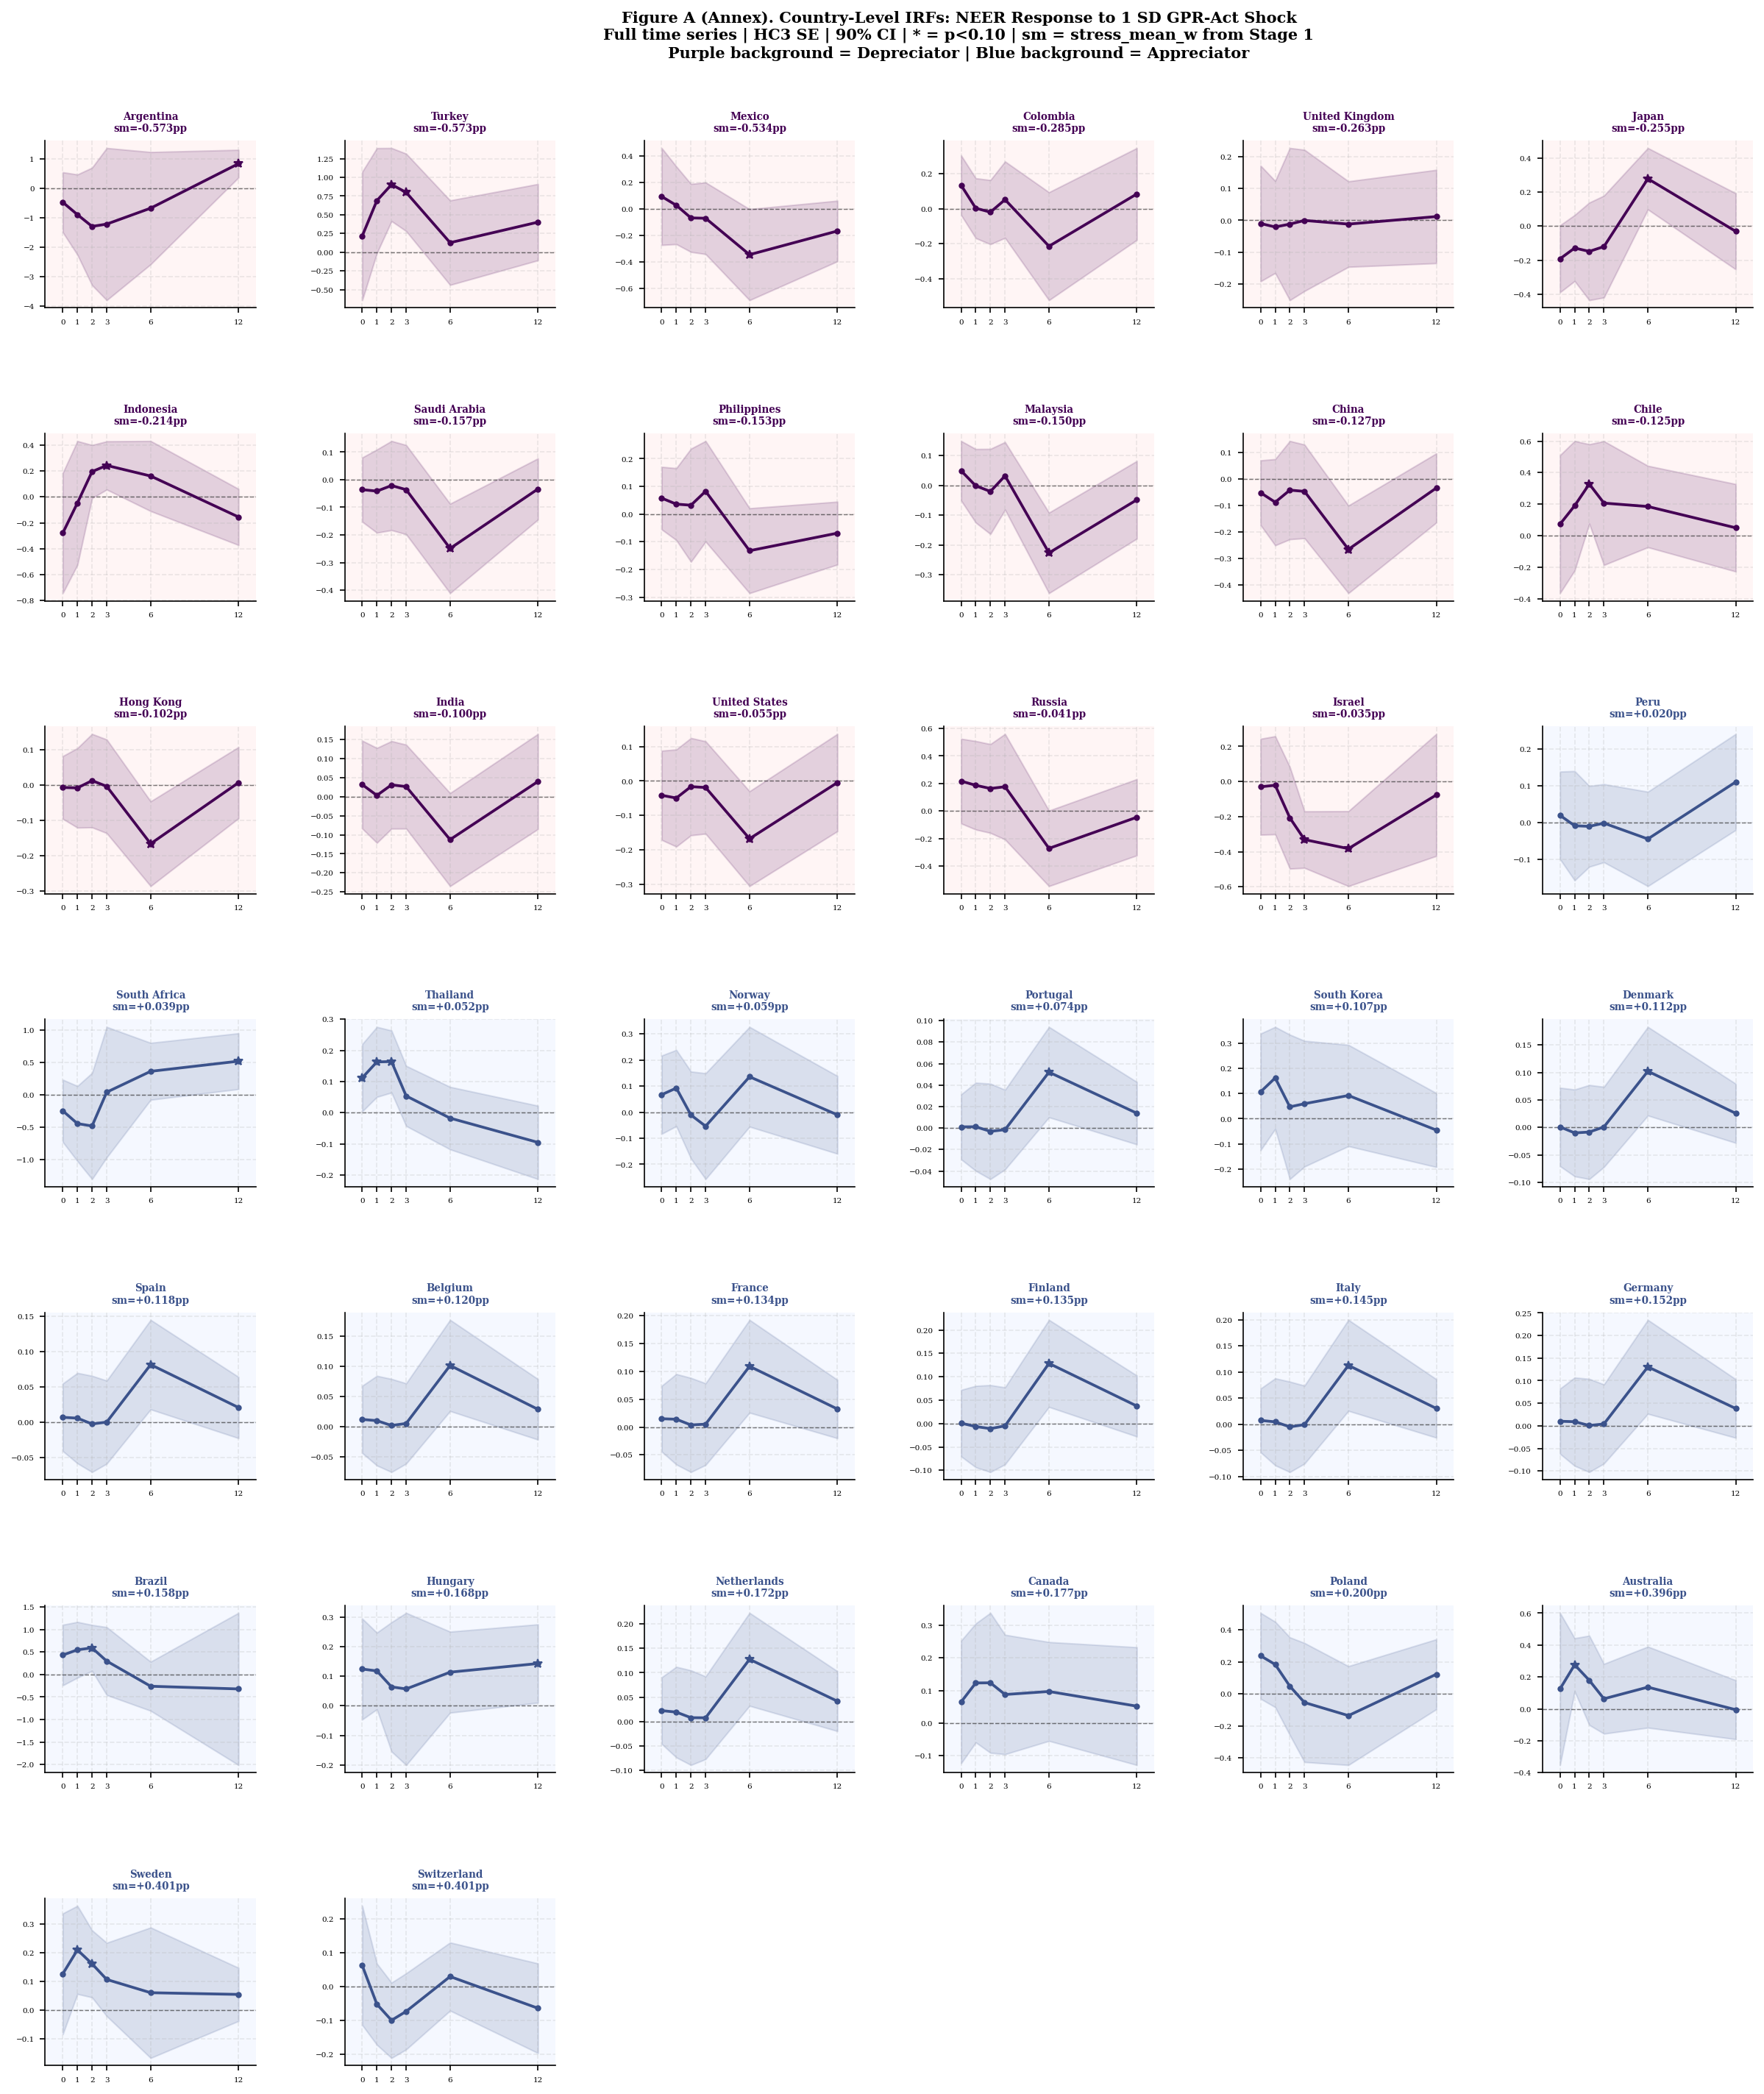


Saved: figB_main_event_study.pdf / .png


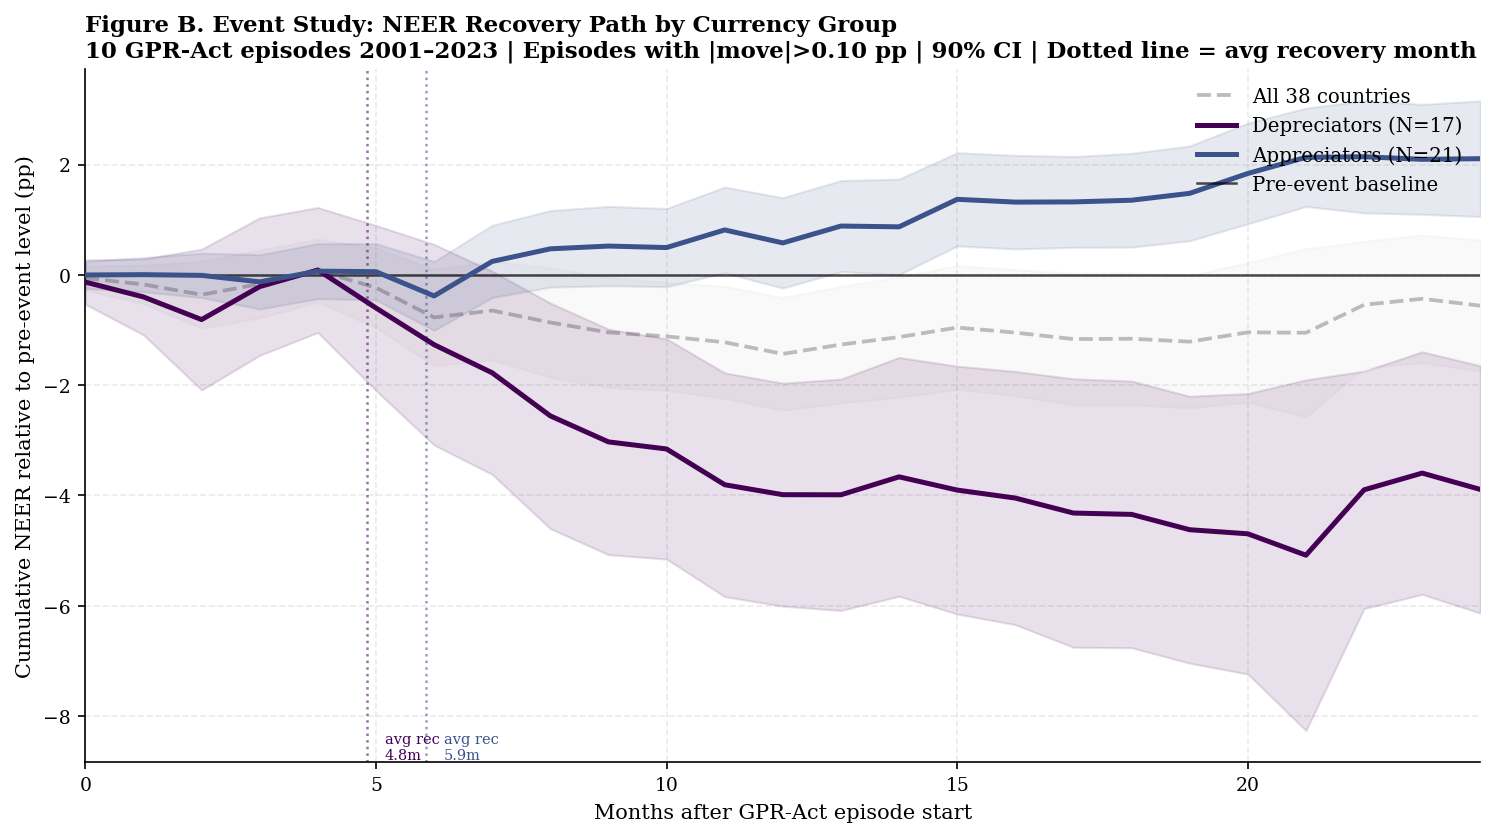


Saved: figC_annex_episode_heatmap.pdf / .png


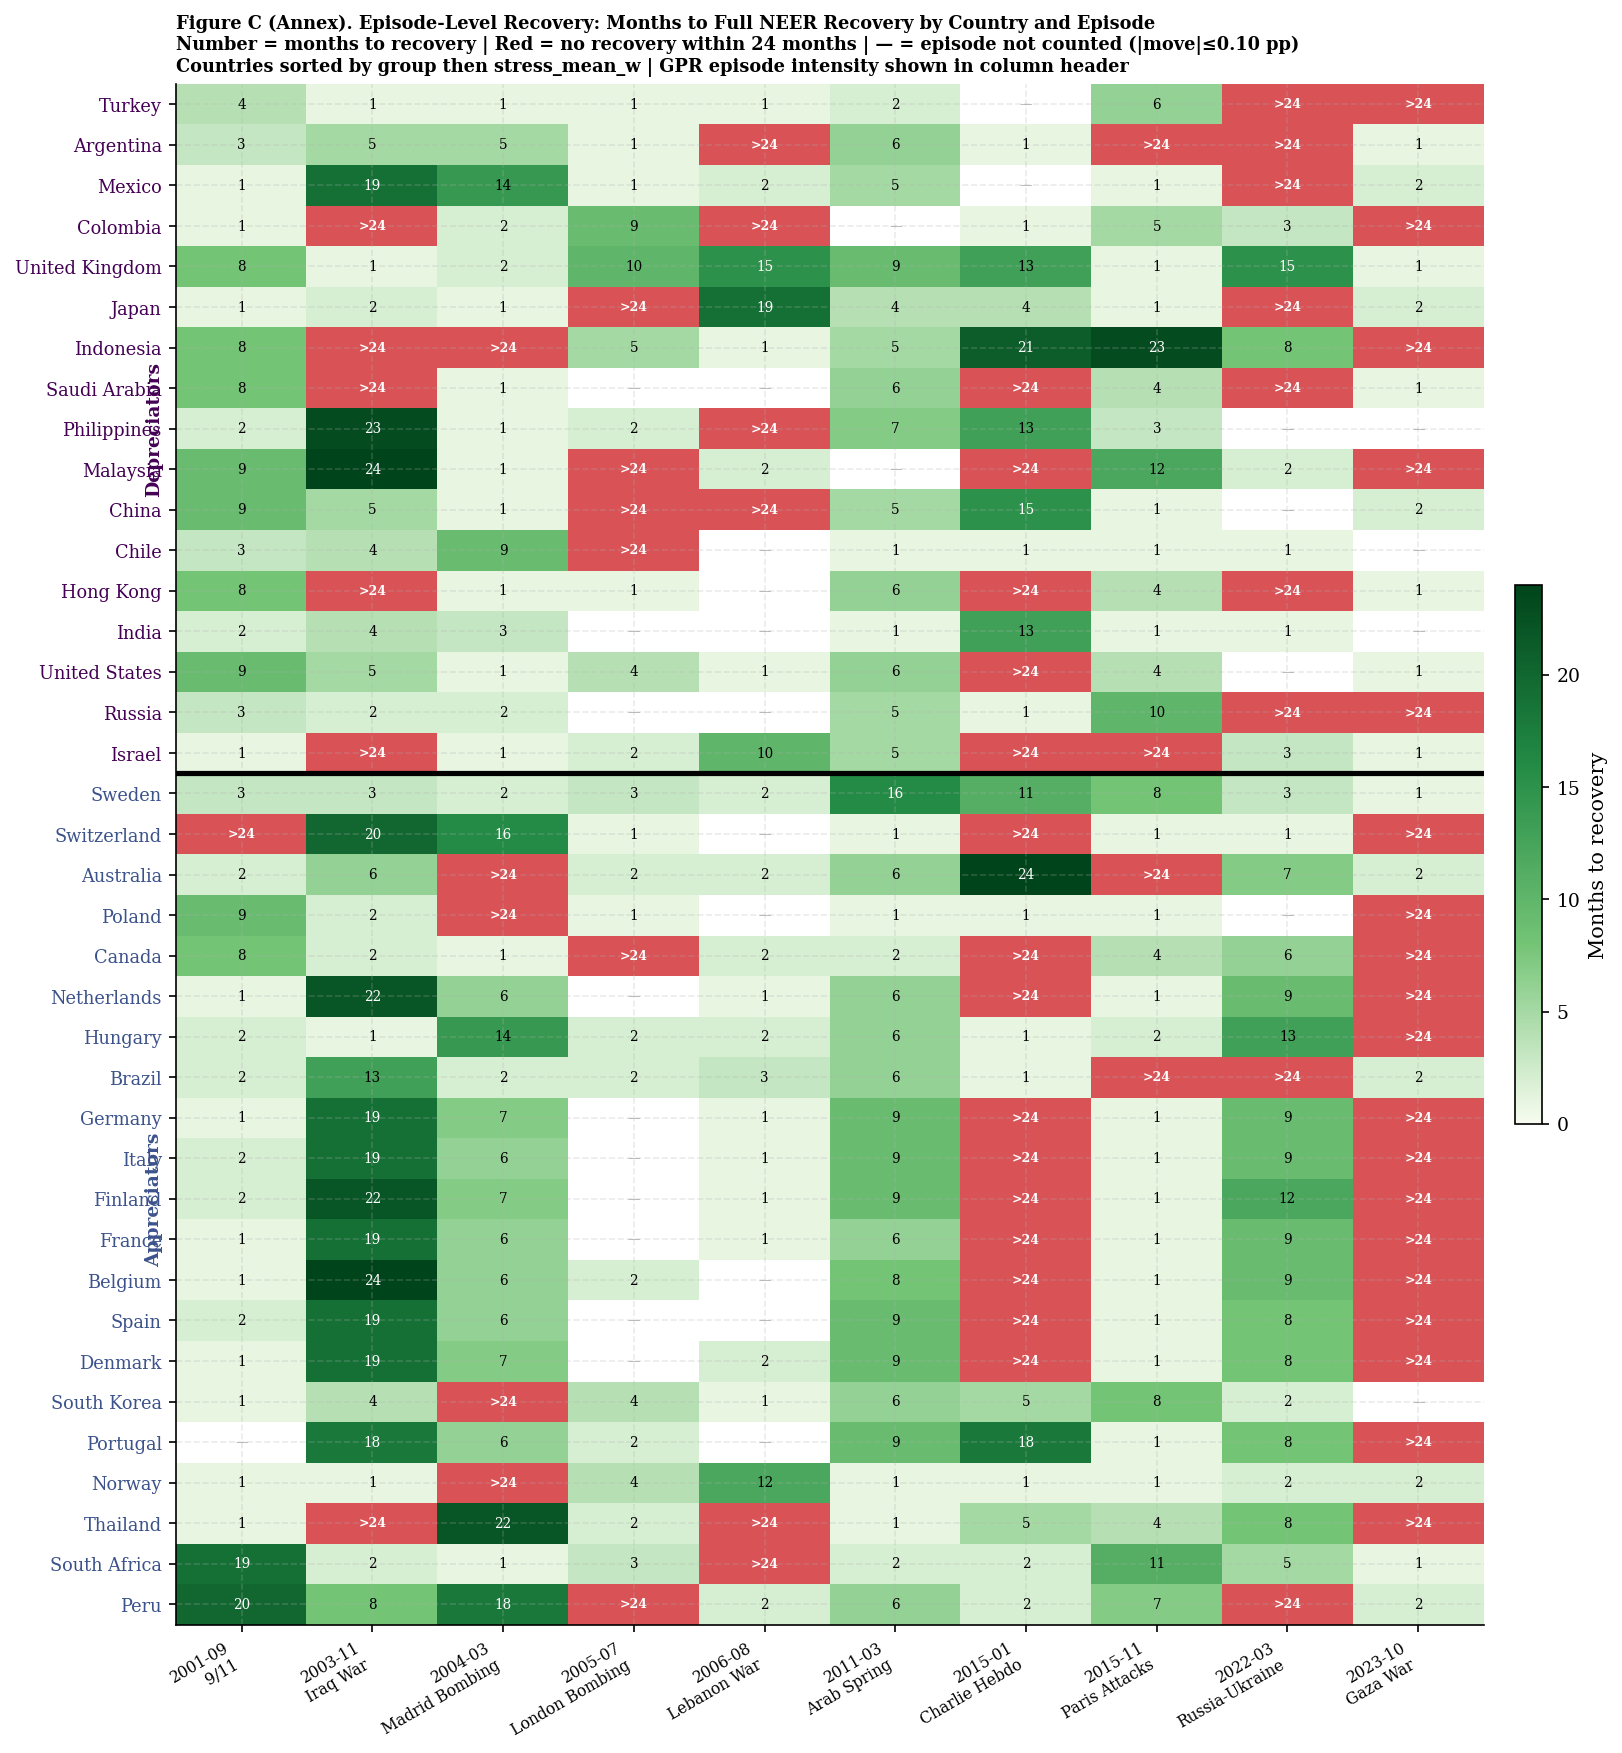

 CELL 12B — RECOVERY ANALYSIS ROBUSTNESS (TOP 15% MONTHS)
 Full panel N        : 10944
 Top 15% stress N    : 1672
 Countries covered   : 38
 Mean recovery (all) : 5.88 months

 TABLE 16B — STRUCTURAL CORRELATES OF RECOVERY
 Using TOP 15% stress months (not episode starts)
 Recovery = first horizon h where cumulative NEER >= 0
 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 Variable                                    All Countries             Depreciators             Appreciators      
                                              ρ        p   Sig       ρ        p   Sig       ρ        p   Sig
 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 CPI inflation (%)                       +0.429    0.007   ***  +0.252    0.328        +0.510    0.018    **
 CTOT exposure                           +0.143    0.392        +0.162    0.535        +0.062    0

In [30]:
# ================================================================
# CELL 11 — DYNAMIC ANALYSIS: IRF + RECOVERY (FINAL VERSION)
# ================================================================
# Classification: stress_mean_w from Stage 1
#   Depreciators = stress_mean_w < 0 (17 countries)
#   Appreciators = stress_mean_w >= 0 (21 countries)
#
# PART 1: Country IRFs (h=0,1,2,3,6,12)
#   Small multiples → Annex Figure A
#   Average IRF by group → feeds into event study
#
# PART 2: Recovery analysis
#   Episode identification (first month of each run)
#   Baseline = t-1 before GPR rises
#   Recovery = cumulative NEER crosses 0
#   Event study 3-line → Main Figure B
#   Episode heatmap → Annex Figure C
#
# PART 3: Structural linkage (N=38)
#   DV = avg recovery time (months)
#   All 10 structural variables | Spearman
#   Dot plot → Main Figure D (if enough sig)
#
# Main body: Figure B (event study) + Figure D (linkage)
# Annex    : Figure A (small multiples) + Figure C (heatmap)
# ================================================================

# Reload Stage 1 country-level results (stress_mean_w and betas)
stage1 = pd.read_csv(
    os.path.join(OUTPUT_DIR,
                 "stage1_country_betas.csv"))

# ── SETUP ─────────────────────────────────────────────────────────
# Extract year from date for later use in fixed effects and grouping
panel["year"]       = panel["date"].dt.year

# Standardise GPR-Act to z-scores: mean=0, std=1
# so IRF coefficients represent the response to a 1 SD GPR shock
gpr_mu              = panel["gpr_act"].mean()
gpr_sd              = panel["gpr_act"].std()
panel["gpr_act_z"]  = (panel["gpr_act"]-gpr_mu)/gpr_sd

# Flag stress months as the top 15% of GPR-Act distribution
THRESH              = panel["gpr_act"].quantile(0.85)
panel["stress_act"] = (
    panel["gpr_act"]>=THRESH).astype(int)

# Define the full list of countries, IRF horizons in months,
# maximum recovery window (24 months), and minimum initial NEER
# move required for an episode to be counted (0.10 pp threshold)
COUNTRIES  = sorted(panel["country"].unique())
HORIZONS   = [0,1,2,3,6,12]
MAX_REC    = 24
MIN_MOVE   = 0.10

# ── CLASSIFICATION FROM STAGE 1 stress_mean_w ────────────────────
# Pull stress_mean_w from Stage 1 output and assign each country
# to "Depreciator" (stress_mean_w < 0) or "Appreciator" (>= 0)
dep_app = stage1[["country","stress_mean_w"]].copy()
dep_app["group"] = np.where(
    dep_app["stress_mean_w"] < 0,
    "Depreciator","Appreciator")

# Build separate lists of depreciator and appreciator country names
DEP = dep_app[dep_app["group"]=="Depreciator"
              ]["country"].tolist()
APP = dep_app[dep_app["group"]=="Appreciator"
              ]["country"].tolist()

print("="*65)
print("  CELL 11 — DYNAMIC ANALYSIS")
print("="*65)
print(f"  Classification: stress_mean_w (Stage 1)")
print(f"  Depreciators ({len(DEP)}): "
      f"{', '.join(sorted(DEP))}")
print(f"  Appreciators ({len(APP)}): "
      f"{', '.join(sorted(APP))}")

# ── STRUCTURAL VARIABLES ──────────────────────────────────────────
# Dictionary of structural variables used in Part 3 linkage analysis
# Maps internal column names to short display labels
STRUCT_VARS = {
    "fx_reserves_months"           : "FX Reserves",
    "ewn_fdi_liabilities_pct_gdp"  : "FDI Liabilities",
    "kaopen"                       : "KAOPEN",
    "ewn_de_facto_fin_open_pct_gdp": "De Facto Open.",
    "trade_openness"               : "Trade Openness",
    "ctot_exposure"                : "CTOT Exposure",
    "gvc_backward_tiva"            : "GVC Backward",
    "gdp_growth"                   : "GDP Growth",
    "inflation_cpi"                : "CPI Inflation",
    "ewn_non_fdi_liab_share"       : "Non-FDI Liab",
}

# Compute each country's median value for each structural variable
# across the full panel — used as the time-invariant structural proxy
# in the Part 3 Spearman correlations with recovery time
struct_med = (panel.groupby("country")
              [list(STRUCT_VARS.keys())]
              .median().reset_index())

# ================================================================
# PART 1 — COUNTRY IRFs
# ================================================================
print(f"\n{'='*65}")
print(f"  PART 1 — COUNTRY IRFs")
print(f"  Full time series | HC3 | h=0,1,2,3,6,12")
print(f"{'='*65}")

# Loop over every country and every horizon h.
# For each country-horizon pair:
#   1. Shift neer_ret_m forward by h periods to create the h-period
#      ahead NEER return as the dependent variable
#   2. Run OLS: neer_ret_m(t+h) = α + β·gpr_act_z(t) + γ·vix(t) + ε
#   3. Record β (IRF coefficient), its p-value, and the 90% CI
# This traces out how the NEER responds at different future horizons
# to a 1 SD GPR shock today — the local projection (Jordà) approach
irf_rows = []
for country in COUNTRIES:
    # Extract and sort this country's time series
    sub = (panel[panel["country"]==country]
           .sort_values("date")
           .reset_index(drop=True))
    # Skip countries with fewer than 60 observations (5 years)
    if len(sub) < 60:
        continue
    # Start building the result row for this country
    row = {"country": country,
           "group": dep_app[
               dep_app["country"]==country
               ]["group"].values[0]}
    for h in HORIZONS:
        # Create the h-period ahead NEER return by shifting the series
        # backward by h rows (shift(-h) moves future values to current row)
        sub[f"neer_fwd_{h}"] = (
            sub["neer_ret_m"].shift(-h))
        dep_v = f"neer_fwd_{h}"
        avail = ["gpr_act_z","vix_avg"]
        sub_h = sub[[dep_v]+avail].dropna()
        # Skip if fewer than 20 observations remain after dropping NaNs
        if len(sub_h) < 20:
            for k in [f"b_{h}",f"p_{h}",
                      f"ci_lo_{h}",
                      f"ci_hi_{h}"]:
                row[k] = np.nan
            continue
        try:
            # OLS with HC3: neer(t+h) = α + β·GPR_z + γ·VIX + ε
            # β is the IRF coefficient at horizon h
            X_h = sm.add_constant(
                sub_h[avail].astype(float))
            y_h = sub_h[dep_v].astype(float)
            m_h = sm.OLS(y_h,X_h).fit(
                cov_type="HC3")
            b  = m_h.params["gpr_act_z"]
            se = m_h.bse["gpr_act_z"]
            p  = m_h.pvalues["gpr_act_z"]
            row[f"b_{h}"]     = round(b,4)
            row[f"p_{h}"]     = round(p,4)
            # 90% confidence interval: β ± 1.645·SE
            row[f"ci_lo_{h}"] = round(
                b-1.645*se,4)
            row[f"ci_hi_{h}"] = round(
                b+1.645*se,4)
        except:
            # If regression fails, fill all horizon fields with NaN
            for k in [f"b_{h}",f"p_{h}",
                      f"ci_lo_{h}",
                      f"ci_hi_{h}"]:
                row[k] = np.nan
    irf_rows.append(row)

# Combine all country IRF rows into a single DataFrame
df_irf = pd.DataFrame(irf_rows)

# Print the IRF table sorted by group then stress_mean_w
# Each row shows the β coefficient at each horizon with significance stars
print(f"\n  {'Country':<22} {'Group':<14} "
      + "".join([f"{'β'+str(h):>10}"
                 for h in HORIZONS]))
print(f"  {'─'*96}")
for _,r in (df_irf
            .merge(dep_app[
                ["country","stress_mean_w"]],
                on="country")
            .sort_values(["group",
                          "stress_mean_w"])
            .iterrows()):
    # Format each horizon's coefficient with significance star
    b_str = "".join([
        f"{r.get(f'b_{h}',np.nan):>+9.4f}"
        f"{sig_label(r.get(f'p_{h}',1)):>1}"
        if not pd.isna(r.get(f'b_{h}',np.nan))
        else f"{'—':>10}"
        for h in HORIZONS])
    print(f"  {r['country']:<22} "
          f"{r['group']:<14}{b_str}")

# Save the full IRF table to CSV
df_irf.to_csv(
    os.path.join(OUTPUT_DIR,
                 "tab_irf_country.csv"),
    index=False)
print(f"\n  Saved: tab_irf_country.csv")

# ── IRF SUMMARY STATS BY GROUP ───────────────────────────────────
# For each group (Depreciator / Appreciator) and each horizon h,
# compute the mean and median β across countries in that group,
# and count how many countries have a significant coefficient (p<0.10)
print(f"\n  IRF SUMMARY BY GROUP:")
for grp in ["Depreciator","Appreciator"]:
    sub_g = df_irf[df_irf["group"]==grp]
    print(f"\n  {grp} (N={len(sub_g)}):")
    print(f"  {'h':>4} {'Mean β':>9} "
          f"{'Median β':>10} "
          f"{'N sig (p<0.10)':>16}")
    print(f"  {'─'*42}")
    for h in HORIZONS:
        betas  = sub_g[f"b_{h}"].dropna()
        ps     = sub_g[f"p_{h}"].dropna()
        n_sig  = (ps < 0.10).sum()
        print(f"  h={h:<3} {betas.mean():>+9.4f} "
              f"{betas.median():>+10.4f} "
              f"{n_sig:>16}")

# ================================================================
# PART 2 — RECOVERY ANALYSIS
# ================================================================
print(f"\n{'='*65}")
print(f"  PART 2 — RECOVERY ANALYSIS")
print(f"  Baseline = t-1 | Min move={MIN_MOVE}pp "
      f"| Max={MAX_REC}m")
print(f"{'='*65}")

# ── EPISODE IDENTIFICATION ────────────────────────────────────────
# Identify the first month of each consecutive stress run.
# A new episode starts when stress_act switches from 0 to 1.
# This avoids double-counting months within the same stress spell.
dates_df = (panel[["date","gpr_act",
                    "stress_act"]]
            .drop_duplicates("date")   # one row per calendar month
            .sort_values("date")
            .reset_index(drop=True))
# Shift stress_act by one period to get the previous month's status
dates_df["prev_s"] = (dates_df["stress_act"]
                       .shift(1).fillna(0))
# ep_start = 1 only when current month is stress and previous was not
dates_df["ep_start"] = (
    (dates_df["stress_act"]==1) &
    (dates_df["prev_s"]==0)).astype(int)
episode_dates = dates_df[
    dates_df["ep_start"]==1]["date"].tolist()
# Short YYYY-MM string labels for each episode start date
ep_labels = [str(d)[:7] for d in episode_dates]
# Dictionary mapping episode date → GPR-Act level at that date
ep_gpr    = {str(d)[:7]:
             dates_df[dates_df["date"]==d
                      ]["gpr_act"].values[0]
             for d in episode_dates}

# ── EPISODE NAMES FOR NARRATIVE ──────────────────────────────────
# Manual mapping from YYYY-MM episode start date to a descriptive name
# for use in figure labels and printed output
EP_NAMES = {
    "2001-09": "9/11",
    "2003-11": "Iraq War",
    "2004-03": "Madrid Bombing",
    "2005-07": "London Bombing",
    "2006-08": "Lebanon War",
    "2011-03": "Arab Spring",
    "2015-01": "Charlie Hebdo",
    "2015-11": "Paris Attacks",
    "2022-03": "Russia-Ukraine",
    "2023-10": "Gaza War",
}

print(f"\n  Episodes identified: {len(episode_dates)}")
print(f"  {'Episode':<15} {'Date':<10} "
      f"{'Name':<20} {'GPR-Act':>8}")
print(f"  {'─'*56}")
for i,ed in enumerate(episode_dates):
    ep_key = str(ed)[:7]
    name   = EP_NAMES.get(ep_key,"—")
    gpr_v  = ep_gpr[ep_key]
    print(f"  {i+1:<15} {ep_key:<10} "
          f"{name:<20} {gpr_v:>8.1f}")

# ── COMPUTE RECOVERY ─────────────────────────────────────────────
# For each country × episode combination:
#   1. Find the episode start row in the country's time series
#   2. Record the cumulative NEER level at t-1 as the baseline
#   3. Compute the initial move = cum_neer(t) - baseline
#   4. Skip episodes where |initial move| <= MIN_MOVE (too small)
#   5. Walk forward month by month up to MAX_REC months
#   6. At each forward month, compute the cumulative NEER relative
#      to the baseline (i.e. how far the currency has moved since t-1)
#   7. Recovery = the first forward month where the relative position
#      crosses zero (depreciators: rel >= 0; appreciators: rel <= 0)
#   8. Store all forward path points in event_pts for the event study figure
all_ep    = []   # one row per country-episode
ctry_rows = []   # one row per country (aggregated across episodes)
event_pts = []   # one row per country-episode-forward_month (for event study)

for country in COUNTRIES:
    sub = (panel[panel["country"]==country]
           .sort_values("date")
           .reset_index(drop=True))
    # Cumulative sum of NEER returns — used as the running level
    sub["cum_neer"] = sub["neer_ret_m"].cumsum()

    # Retrieve group classification and stress_mean_w for this country
    grp = dep_app[
        dep_app["country"]==country
        ]["group"].values[0]
    sm_w = dep_app[
        dep_app["country"]==country
        ]["stress_mean_w"].values[0]

    ep_records = []
    for ep_date in episode_dates:
        # Find the row index of the episode start in this country's panel
        ep_idx = sub[sub["date"]==ep_date].index
        if len(ep_idx)==0: continue
        ep_idx = ep_idx[0]
        if ep_idx < 1: continue  # need t-1 to exist for baseline

        # Baseline = cumulative NEER at t-1 (the month before episode start)
        baseline  = sub.loc[ep_idx-1,"cum_neer"]
        # Initial move = how much the NEER moved in the first stress month
        init_move = (sub.loc[ep_idx,"cum_neer"]
                     - baseline
                     if ep_idx < len(sub)
                     else np.nan)
        if pd.isna(init_move): continue
        # Filter out episodes with negligible initial NEER movement
        if abs(init_move) <= MIN_MOVE: continue

        recovered     = False
        months_to_rec = np.nan
        for fwd in range(MAX_REC+1):
            if ep_idx+fwd >= len(sub): break
            # Relative NEER = cumulative NEER at t+fwd minus baseline
            # Positive = above pre-event level; negative = below
            rel = (sub.loc[ep_idx+fwd,"cum_neer"]
                   - baseline)
            # Store every forward path point for event study aggregation
            event_pts.append({
                "country": country,
                "group"  : grp,
                "episode": str(ep_date)[:7],
                "fwd"    : fwd,
                "rel"    : rel,
            })
            # Check recovery condition starting from fwd=1
            if fwd > 0 and not recovered:
                # Depreciator recovers when rel >= 0 (currency returns to baseline)
                if init_move<0 and rel>=0:
                    recovered=True
                    months_to_rec=fwd
                # Appreciator recovers when rel <= 0 (currency returns to baseline)
                elif init_move>0 and rel<=0:
                    recovered=True
                    months_to_rec=fwd

        ep_records.append({
            "country"      : country,
            "group"        : grp,
            "stress_mean_w": sm_w,
            "episode"      : str(ep_date)[:7],
            "ep_name"      : EP_NAMES.get(
                str(ep_date)[:7],"—"),
            "gpr_level"    : ep_gpr[
                str(ep_date)[:7]],
            "initial_move" : round(init_move,4),
            "recovered"    : recovered,
            "months_to_rec": months_to_rec,
        })
        all_ep.append(ep_records[-1])

    # Aggregate this country's episode records into a single country-level row
    if ep_records:
        ep_df   = pd.DataFrame(ep_records)
        n_ep    = len(ep_df)
        n_rec   = ep_df["recovered"].sum()
        # Average months to recovery — only over episodes that did recover
        avg_rec = (ep_df[ep_df["recovered"]]
                   ["months_to_rec"].mean())
        avg_move = ep_df["initial_move"].mean()
        ctry_rows.append({
            "country"       : country,
            "group"         : grp,
            "stress_mean_w" : sm_w,
            "n_episodes"    : n_ep,
            "n_recovered"   : int(n_rec),
            "pct_recovered" : round(
                n_rec/n_ep*100 if n_ep>0
                else np.nan, 1),
            "avg_months_rec": round(avg_rec,2)
                              if not pd.isna(avg_rec)
                              else np.nan,
            "avg_init_move" : round(avg_move,4),
        })

# Assemble the three main output DataFrames
df_ep   = pd.DataFrame(all_ep)       # one row per country-episode
df_rec  = pd.DataFrame(ctry_rows).sort_values(  # one row per country
    ["group","avg_months_rec"],
    na_position="last")
df_evpt = pd.DataFrame(event_pts)    # one row per country-episode-forward month

# ── EPISODE-LEVEL STATS ───────────────────────────────────────────
# Collapse df_ep to one row per episode, computing across all countries:
# number of countries affected, percentage that recovered,
# average months to recovery, and average initial NEER move
ep_stats = (df_ep.groupby(
    ["episode","ep_name","gpr_level"])
    .agg(
        n_countries =("country","count"),
        pct_rec     =("recovered",lambda x:
                      round(x.mean()*100,1)),
        avg_months  =("months_to_rec","mean"),
        avg_move    =("initial_move","mean"),
    ).reset_index()
    .sort_values("episode"))

print(f"\n  EPISODE-LEVEL RECOVERY STATS:")
print(f"  {'Date':<10} {'Name':<20} "
      f"{'GPR':>7} {'N ctry':>7} "
      f"{'% rec':>7} {'Avg mo':>8} "
      f"{'Avg move':>10}")
print(f"  {'─'*72}")
for _,r in ep_stats.iterrows():
    print(f"  {r['episode']:<10} "
          f"{r['ep_name']:<20} "
          f"{r['gpr_level']:>7.1f} "
          f"{int(r['n_countries']):>7} "
          f"{r['pct_rec']:>7.1f}% "
          f"{r['avg_months']:>8.1f} "
          f"{r['avg_move']:>+10.4f}")

# ── RECOVERY BY GROUP ─────────────────────────────────────────────
# Print country-level recovery statistics separately for each group,
# showing avg months to recovery and overall recovery rate per group
print(f"\n  RECOVERY BY GROUP:")
for grp in ["Depreciator","Appreciator"]:
    sub_g = df_rec[df_rec["group"]==grp]
    avg_g = sub_g["avg_months_rec"].mean()
    print(f"\n  {grp} (N={len(sub_g)}) | "
          f"Avg={avg_g:.1f} months | "
          f"Overall recovery rate="
          f"{(sub_g['n_recovered'].sum()/sub_g['n_episodes'].sum()*100):.1f}%")
    print(f"  {'Country':<22} {'sm_w':>8} "
          f"{'N ep':>5} {'% rec':>7} "
          f"{'Avg mo':>8} "
          f"{'Avg move':>10}")
    print(f"  {'─'*65}")
    for _,r in sub_g.iterrows():
        # Print "never" instead of a number if the country never recovered
        avg_m = (f"{r['avg_months_rec']:>8.1f}"
                 if not pd.isna(
                     r['avg_months_rec'])
                 else f"{'never':>8}")
        print(f"  {r['country']:<22} "
              f"{r['stress_mean_w']:>+8.4f} "
              f"{r['n_episodes']:>5} "
              f"{r['pct_recovered']:>7.1f}% "
              f"{avg_m} "
              f"{r['avg_init_move']:>+10.4f}")

# Save the three recovery output tables to CSV
df_rec.to_csv(
    os.path.join(OUTPUT_DIR,
                 "tab_recovery_country.csv"),
    index=False)
df_ep.to_csv(
    os.path.join(OUTPUT_DIR,
                 "tab_recovery_episodes.csv"),
    index=False)
ep_stats.to_csv(
    os.path.join(OUTPUT_DIR,
                 "tab_recovery_ep_stats.csv"),
    index=False)
print(f"\n  Saved: tab_recovery_country.csv")
print(f"  Saved: tab_recovery_episodes.csv")
print(f"  Saved: tab_recovery_ep_stats.csv")

# ================================================================
# PART 3 — STRUCTURAL LINKAGE
# DV = avg recovery time (months) | N=38
# ================================================================
# Tests whether structural country characteristics predict how quickly
# a country's currency recovers after a GPR episode.
# For each structural variable: winsorise at 5th/95th pct, then
# compute Spearman ρ with avg_months_rec for all countries,
# depreciators only, and appreciators only
print(f"\n{'='*65}")
print(f"  PART 3 — STRUCTURAL LINKAGE")
print(f"  DV = avg months to recovery | N=38")
print(f"{'='*65}")

# Merge the country-level recovery data with structural medians
df_link = (df_rec[["country","group",
                    "avg_months_rec"]]
           .merge(struct_med,
                  on="country",how="left"))

# Winsorise each structural variable at 5th/95th percentile
# to limit the influence of outliers on Spearman correlations
for var in STRUCT_VARS:
    col    = df_link[var].dropna()
    lo, hi = col.quantile(0.05),col.quantile(0.95)
    df_link[f"{var}_w"] = df_link[var].clip(lo,hi)

# Print a three-block Spearman table:
# All N=38 countries | Depreciators only | Appreciators only
link_rows = []
print(f"\n  {'Variable':<35} "
      f"{'All (N=38)':^22} "
      f"{'Dep (N='+str(len(DEP))+')':^22} "
      f"{'App (N='+str(len(APP))+')':^22}")
print(f"  {'':35} "
      f"{'ρ':>7} {'p':>7} {'Sig':>4} "
      f"{'ρ':>7} {'p':>7} {'Sig':>4} "
      f"{'ρ':>7} {'p':>7} {'Sig':>4}")
print(f"  {'─'*103}")

for var, label in STRUCT_VARS.items():
    w_col = f"{var}_w"
    if w_col not in df_link.columns:
        continue

    row = {"Variable": label, "var": var}

    # Run Spearman for each of the three country subsets:
    # all, depreciators only, appreciators only
    for tag, mask in [
        ("all",  df_link["country"].notna()),
        ("dep",  df_link["group"]=="Depreciator"),
        ("app",  df_link["group"]=="Appreciator"),
    ]:
        sub = df_link[mask][
            [w_col,"avg_months_rec",
             "country"]].dropna()
        # Require at least 8 observations to run the correlation
        if len(sub) >= 8:
            rho,p = stats.spearmanr(
                sub[w_col],
                sub["avg_months_rec"])
            row[f"rho_{tag}"] = round(rho,3)
            row[f"p_{tag}"]   = round(p,4)
        else:
            row[f"rho_{tag}"] = np.nan
            row[f"p_{tag}"]   = np.nan

    # Helper to format one ρ/p/sig triplet for printing
    def fmt(rho,p):
        if pd.isna(rho):
            return f"{'—':>7} {'—':>7} {'':>4}"
        return (f"{rho:>+7.3f} {p:>7.3f} "
                f"{sig_label(p):>4}")

    # Flag which subsets show significant results (p<0.10)
    sig_all = (not pd.isna(row.get("p_all"))
               and row["p_all"]<0.10)
    sig_dep = (not pd.isna(row.get("p_dep"))
               and row["p_dep"]<0.10)
    sig_app = (not pd.isna(row.get("p_app"))
               and row["p_app"]<0.10)

    flag = ""
    if sig_all: flag += " ← ALL"
    if sig_dep: flag += " DEP"
    if sig_app: flag += " APP"

    print(f"  {label:<35} "
          f"{fmt(row.get('rho_all'),row.get('p_all'))} "
          f"{fmt(row.get('rho_dep'),row.get('p_dep'))} "
          f"{fmt(row.get('rho_app'),row.get('p_app'))}"
          f"{flag}")

    link_rows.append(row)

# Save the structural linkage Spearman table to CSV
link_df = pd.DataFrame(link_rows)
link_df.to_csv(
    os.path.join(OUTPUT_DIR,
                 "tab_structural_linkage_rec.csv"),
    index=False)
print(f"\n  Saved: tab_structural_linkage_rec.csv")

# ── DECIDE MAIN BODY vs ANNEX ────────────────────────────────────
# Count how many variables are significant at p<0.10 across all N=38
# and across at least one group — determines whether Figure D goes
# to the main body (≥2 significant) or is relegated to the annex
n_sig_all = sum(1 for r in link_rows
                if not pd.isna(r.get("p_all"))
                and r["p_all"]<0.10)
n_sig_grp = sum(1 for r in link_rows
                if (not pd.isna(r.get("p_dep"))
                    and r["p_dep"]<0.10)
                or (not pd.isna(r.get("p_app"))
                    and r["p_app"]<0.10))
print(f"\n  SIGNIFICANCE ASSESSMENT:")
print(f"  Significant at N=38 (p<0.10): {n_sig_all}")
print(f"  Significant by group (p<0.10): {n_sig_grp}")
verdict = ("MAIN BODY" if n_sig_all>=2
           else "ANNEX ONLY")
print(f"  → Structural linkage goes to: {verdict}")

# ================================================================
# FIGURES
# ================================================================

# ── FIGURE A (ANNEX): SMALL MULTIPLES IRF ────────────────────────
# Sort countries: depreciators first (by stress_mean_w ascending),
# then appreciators (by stress_mean_w ascending)
# Each subplot shows one country's IRF across all 6 horizons:
#   - Line plot of β coefficients at h=0,1,2,3,6,12
#   - Shaded 90% CI band around the line
#   - Star marker on points where p<0.10
#   - Background colour: pink for depreciators, light blue for appreciators
df_irf_s = pd.concat([
    df_irf[df_irf["group"]=="Depreciator"]
    .merge(dep_app[["country","stress_mean_w"]],
           on="country")
    .sort_values("stress_mean_w"),
    df_irf[df_irf["group"]=="Appreciator"]
    .merge(dep_app[["country","stress_mean_w"]],
           on="country")
    .sort_values("stress_mean_w"),
]).reset_index(drop=True)

# Lay out a grid of 6 columns, as many rows as needed to fit all countries
ncols = 6
nrows = int(np.ceil(len(df_irf_s)/ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(18, nrows*2.8))
axes = axes.flatten()

for i,(_,r) in enumerate(df_irf_s.iterrows()):
    ax  = axes[i]
    # Choose colour by group
    col = (V1 if r["group"]=="Depreciator"
           else V2)
    # Extract β, CI bounds, and p-values for all horizons
    betas = [r.get(f"b_{h}",np.nan)
             for h in HORIZONS]
    cilo  = [r.get(f"ci_lo_{h}",np.nan)
             for h in HORIZONS]
    cihi  = [r.get(f"ci_hi_{h}",np.nan)
             for h in HORIZONS]
    ps    = [r.get(f"p_{h}",1)
             for h in HORIZONS]

    # Filter to only horizons with valid (non-NaN) estimates
    valid = [not pd.isna(b) for b in betas]
    h_v   = [h for h,v in zip(HORIZONS,valid) if v]
    b_v   = [b for b,v in zip(betas,valid) if v]
    lo_v  = [b for b,v in zip(cilo,valid) if v]
    hi_v  = [b for b,v in zip(cihi,valid) if v]
    p_v   = [p for p,v in zip(ps,valid) if v]

    if h_v:
        # Draw the IRF line with circular markers
        ax.plot(h_v, b_v, color=col,
                lw=1.8, marker="o", ms=3,
                zorder=3)
        # Shade the 90% CI band
        ax.fill_between(h_v, lo_v, hi_v,
                         alpha=0.15, color=col)
        # Overlay a star at each significant horizon point
        for hh,bb,pp in zip(h_v,b_v,p_v):
            if pp < 0.10:
                ax.plot(hh, bb, "*",
                        color=col, ms=6,
                        zorder=4)

    # Reference line at zero (no NEER response)
    ax.axhline(0, color="black", lw=0.7,
               ls="--", alpha=0.5)
    # Subtitle shows country name and stress_mean_w from Stage 1
    ax.set_title(
        f"{r['country']}\n"
        f"sm={r['stress_mean_w']:>+.3f}pp",
        fontsize=6.5, fontweight="bold",
        color=col)
    ax.set_xticks(HORIZONS)
    ax.set_xticklabels(
        [str(h) for h in HORIZONS],
        fontsize=5)
    ax.tick_params(labelsize=5)
    ax.margins(x=0.1)
    # Background colour encodes group membership at a glance
    ax.set_facecolor(
        "#FFF5F5"
        if r["group"]=="Depreciator"
        else "#F5F8FF")

# Hide any unused subplots in the grid
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Figure A (Annex). Country-Level IRFs: "
    "NEER Response to 1 SD GPR-Act Shock\n"
    "Full time series | HC3 SE | 90% CI | "
    "* = p<0.10 | sm = stress_mean_w from Stage 1\n"
    "Purple background = Depreciator | "
    "Blue background = Appreciator",
    fontsize=10, fontweight="bold")
fig.subplots_adjust(
    hspace=0.75, wspace=0.42,
    top=0.92, bottom=0.03, left=0.04)
save_fig(fig, "figA_annex_irf_multiples")
plt.show()

# ── FIGURE B (MAIN): EVENT STUDY 3-LINE ──────────────────────────
# Aggregate the event_pts DataFrame (one row per country-episode-fwd)
# by group and forward month to get mean cumulative NEER path and SE
# Three lines: All 38, Depreciators, Appreciators
# Shaded bands = ±1.645·SE (90% CI)
# Dotted vertical lines mark the average recovery month per group
ev_grp = (df_evpt.groupby(["group","fwd"])
          ["rel"].agg(
              mean="mean",
              # Standard error = std / sqrt(N) across country-episodes
              se=lambda x: x.std()
                          /np.sqrt(len(x)))
          .reset_index())
ev_all = (df_evpt.groupby("fwd")
          ["rel"].agg(
              mean="mean",
              se=lambda x: x.std()
                          /np.sqrt(len(x)))
          .reset_index())

fig, ax = plt.subplots(figsize=(12,6))

# Grey dashed line for the full sample average path
ax.plot(ev_all["fwd"], ev_all["mean"],
        color=VGREY, lw=1.8, ls="--",
        label="All 38 countries", zorder=2)
ax.fill_between(
    ev_all["fwd"],
    ev_all["mean"]-1.645*ev_all["se"],
    ev_all["mean"]+1.645*ev_all["se"],
    alpha=0.08, color=VGREY, zorder=1)

# Coloured solid lines for each group with shaded CI
for grp, col, lbl in [
    ("Depreciator", V1,
     f"Depreciators (N={len(DEP)})"),
    ("Appreciator", V2,
     f"Appreciators (N={len(APP)})"),
]:
    sub_ev = ev_grp[ev_grp["group"]==grp]
    ax.plot(sub_ev["fwd"], sub_ev["mean"],
            color=col, lw=2.4,
            label=lbl, zorder=3)
    ax.fill_between(
        sub_ev["fwd"],
        sub_ev["mean"]-1.645*sub_ev["se"],
        sub_ev["mean"]+1.645*sub_ev["se"],
        alpha=0.12, color=col, zorder=2)

# Add vertical dotted lines marking the average recovery month per group
for grp, col in [("Depreciator",V1),
                  ("Appreciator",V2)]:
    sub_g  = df_rec[df_rec["group"]==grp]
    avg_rec = sub_g["avg_months_rec"].mean()
    if not pd.isna(avg_rec):
        ax.axvline(avg_rec,
                   color=col, lw=1.2,
                   ls=":", alpha=0.55)
        ax.text(avg_rec+0.3, ax.get_ylim()[0]
                if ax.get_ylim()[0]!=0
                else -0.01,
                f"avg rec\n{avg_rec:.1f}m",
                fontsize=7, color=col,
                va="bottom")

# Horizontal line at zero marks the pre-event baseline level
ax.axhline(0, color="black", lw=1.2,
           alpha=0.7, label="Pre-event baseline")
# Vertical line at fwd=0 marks the episode start month
ax.axvline(0, color=VGREY, lw=0.8,
           ls=":", alpha=0.5)
ax.set_xlabel(
    "Months after GPR-Act episode start",
    fontsize=10)
ax.set_ylabel(
    "Cumulative NEER relative to "
    "pre-event level (pp)", fontsize=10)
ax.set_title(
    "Figure B. Event Study: NEER Recovery Path "
    "by Currency Group\n"
    "10 GPR-Act episodes 2001–2023 | "
    "Episodes with |move|>0.10 pp | 90% CI | "
    "Dotted line = avg recovery month",
    loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=9.5,
          loc="upper right")
ax.set_xlim(0, 24)
fig.subplots_adjust(top=0.88)
save_fig(fig, "figB_main_event_study")
plt.show()

# ── FIGURE C (ANNEX): EPISODE HEATMAP ────────────────────────────
# Rows = countries sorted: depreciators by stress_mean_w asc,
#        then appreciators by stress_mean_w desc
# Columns = episodes in chronological order
# Cell colour = months to recovery (green gradient)
# Red cells = no recovery within MAX_REC months
# "—" cells = episode not counted (|initial move| <= MIN_MOVE)
# Number annotation = exact months to recovery, ">24", or "—"

ctry_order = pd.concat([
    df_rec[df_rec["group"]=="Depreciator"]
    .sort_values("stress_mean_w"),
    df_rec[df_rec["group"]=="Appreciator"]
    .sort_values("stress_mean_w",
                 ascending=False),
])["country"].tolist()

# Column labels: episode date + episode name on two lines
ep_col_names = [
    f"{ep}\n{EP_NAMES.get(ep,'—')}"
    for ep in ep_labels]

# Build the heatmap matrix: rows=countries, cols=episodes
# Fill with months_to_recovery, MAX_REC+2 for no-recovery, NaN for uncounted
ep_matrix = pd.DataFrame(
    np.nan,
    index=ctry_order,
    columns=ep_labels)

for _,r in df_ep.iterrows():
    c  = r["country"]
    ep = r["episode"]
    if r["recovered"] and not pd.isna(
            r["months_to_rec"]):
        ep_matrix.loc[c,ep] = r["months_to_rec"]
    elif not r["recovered"]:
        ep_matrix.loc[c,ep] = MAX_REC+2
    # NaN = not counted (|move| <= MIN_MOVE)

# Green sequential colormap for recovery months (fast=light, slow=dark)
from matplotlib.colors import (
    LinearSegmentedColormap, BoundaryNorm)
cmap_rec = LinearSegmentedColormap.from_list(
    "rec", ["#F7FCF0","#74C476","#238B45",
            "#00441B"])
cmap_grey = LinearSegmentedColormap.from_list(
    "grey",["#CCCCCC","#CCCCCC"])

fig, ax = plt.subplots(figsize=(14,13))

# Plot recovery cells (mask out no-recovery and NaN cells)
masked = np.ma.masked_where(
    (ep_matrix.values > MAX_REC+1) |
    np.isnan(ep_matrix.values),
    ep_matrix.values)
im = ax.imshow(masked, aspect="auto",
               cmap=cmap_rec,
               vmin=0, vmax=MAX_REC,
               interpolation="nearest")

# Overlay red colour for no-recovery cells (value = MAX_REC+2)
no_rec = (ep_matrix.values > MAX_REC+1)
ax.imshow(
    np.where(no_rec,1,np.nan),
    aspect="auto",
    cmap=LinearSegmentedColormap.from_list(
        "red",["#CB181D","#CB181D"]),
    vmin=0, vmax=1,
    interpolation="nearest",
    alpha=0.75)

# Annotate every cell with text:
# NaN → "—" in grey; no recovery → ">24" in white; recovered → integer months
for i,ctry in enumerate(ctry_order):
    for j,ep in enumerate(ep_labels):
        val = ep_matrix.loc[ctry,ep]
        if pd.isna(val):
            ax.text(j, i, "—",
                    ha="center", va="center",
                    fontsize=6, color="#AAAAAA")
        elif val > MAX_REC+1:
            ax.text(j, i, ">24",
                    ha="center", va="center",
                    fontsize=6, color="white",
                    fontweight="bold")
        else:
            # Use white text on dark cells (slow recovery), black on light cells
            txt_col = ("white" if val>14
                       else "black")
            ax.text(j, i, f"{int(val)}",
                    ha="center", va="center",
                    fontsize=6.5,
                    color=txt_col)

# Draw a thick horizontal line separating depreciators from appreciators
n_dep = len(DEP)
ax.axhline(n_dep-0.5, color="black",
           lw=2.5, ls="-")
# Rotated group labels on the left margin
ax.text(-0.6, n_dep/2-0.5,
        "Depreciators",
        va="center", ha="right",
        fontsize=9, color=V1,
        fontweight="bold", rotation=90)
ax.text(-0.6, n_dep+(len(APP)/2)-0.5,
        "Appreciators",
        va="center", ha="right",
        fontsize=9, color=V2,
        fontweight="bold", rotation=90)

ax.set_xticks(range(len(ep_labels)))
ax.set_xticklabels(ep_col_names,
                    fontsize=7.5,
                    rotation=30, ha="right")
ax.set_yticks(range(len(ctry_order)))
ax.set_yticklabels(ctry_order, fontsize=8.5)

# Colour y-tick labels to match group (V1=depreciator, V2=appreciator)
for tick, ctry in zip(
        ax.get_yticklabels(), ctry_order):
    grp_c = dep_app[
        dep_app["country"]==ctry
        ]["group"].values
    tick.set_color(
        V1 if (len(grp_c)>0
               and grp_c[0]=="Depreciator")
        else V2)

plt.colorbar(im, ax=ax,
             label="Months to recovery",
             shrink=0.35, pad=0.02)
ax.set_title(
    "Figure C (Annex). Episode-Level Recovery: "
    "Months to Full NEER Recovery by Country and Episode\n"
    "Number = months to recovery | "
    "Red = no recovery within 24 months | "
    "— = episode not counted (|move|≤0.10 pp)\n"
    "Countries sorted by group then stress_mean_w | "
    "GPR episode intensity shown in column header",
    loc="left", fontweight="bold", fontsize=8.5)
fig.subplots_adjust(left=0.17, right=0.92,
                    top=0.92, bottom=0.13)
save_fig(fig, "figC_annex_episode_heatmap")
plt.show()

# ── FIGURE D / CELL 12B — RECOVERY ROBUSTNESS (TOP 15% MONTHS) ───
# Alternative recovery measure: instead of episode-start dates,
# use every stress month as a potential recovery start point.
# For each stress month t, compute cumulative forward NEER returns
# at horizons 1 to MAX_H and find the first horizon where the
# cumulative sum crosses zero. Average across all stress months
# per country to get a country-level recovery speed measure.
# Then correlate this with structural variables (Spearman) as a
# robustness check on the episode-based Part 3 linkage results.
print("=" * 65)
print(" CELL 12B — RECOVERY ANALYSIS ROBUSTNESS (TOP 15% MONTHS)")
print("=" * 65)

MAX_H = 24
MIN_MOVE = 0.10  # same filter as episode-based version

# ── STEP 1: RECREATE STRESS FLAG ON FULL PANEL ───────────────────
# Sort and copy the panel; recompute stress flag to ensure consistency
panel_dyn = panel.sort_values(["country", "date"]).copy()
THRESH = panel_dyn["gpr_act"].quantile(0.85)
panel_dyn["stress_act"] = (panel_dyn["gpr_act"] >= THRESH).astype(int)

# ── STEP 2: COMPUTE ROLLING FORWARD CUMULATIVE RETURNS ───────────
# For each horizon h (1 to 24), compute the cumulative NEER return
# starting from each month t looking forward h periods.
# Uses a reversed rolling sum trick: reverse the series, apply a
# rolling window of size h, then reverse back — this gives the
# sum of the next h values starting from each observation
for h in range(1, MAX_H + 1):
    panel_dyn[f"cumret_{h}"] = (
        panel_dyn.groupby("country")["neer_ret_m"]
        .transform(lambda s: s[::-1].rolling(h, min_periods=h).sum()[::-1])
    )

# ── STEP 3: FIND MONTHS-TO-RECOVERY FOR EACH STRESS MONTH ────────
# For each stress month row, check the 1-month forward return as the
# initial move filter, then scan horizons 1 to MAX_H to find the
# first h where cumulative return turns non-negative
def get_month_recovery(row):
    init_move = row["cumret_1"]
    # Skip if the first-month move is too small or missing
    if pd.isna(init_move) or abs(init_move) < MIN_MOVE:
        return np.nan
    # Walk forward through horizons to find first crossing of zero
    for h in range(1, MAX_H + 1):
        v = row.get(f"cumret_{h}", np.nan)
        if pd.notna(v) and v >= 0:
            return h
    # If no recovery within MAX_H months, assign MAX_H+1 as sentinel value
    return MAX_H + 1

# Apply the recovery function to every stress month row
stress_months = panel_dyn[panel_dyn["stress_act"] == 1].copy()
stress_months["months_to_recovery"] = stress_months.apply(get_month_recovery, axis=1)

# ── STEP 4: AGGREGATE TO COUNTRY LEVEL ───────────────────────────
# Average months_to_recovery across all stress months per country
# and count how many stress months had a valid (non-NaN) recovery measure
recovery_top15 = (
    stress_months.groupby("country")
    .agg(
        avg_months_to_recovery=("months_to_recovery", "mean"),
        n_stress_months=("months_to_recovery", lambda x: x.notna().sum())
    )
    .reset_index()
)

print(f" Full panel N        : {len(panel_dyn)}")
print(f" Top 15% stress N    : {len(stress_months)}")
print(f" Countries covered   : {recovery_top15['country'].nunique()}")
print(f" Mean recovery (all) : {recovery_top15['avg_months_to_recovery'].mean():.2f} months")

# ── STEP 5: MERGE WITH STAGE 1 CLASSIFICATION + STRUCTURAL VARS ──
# Attach stress_mean_w and group classification from Stage 1,
# and the structural variable medians for Spearman analysis
recov_cs = recovery_top15.merge(
    stage1[["country", "stress_mean_w"]],
    on="country",
    how="left"
)
recov_cs["group"] = np.where(
    recov_cs["stress_mean_w"] < 0,
    "Depreciators", "Appreciators")

# Only use structural variables that actually exist in the panel
# (guards against variables that may have been renamed or dropped)
avail_struct = [v for v in ALL_STRUCT if v in panel.columns]
struct_med_safe = panel.groupby("country")[avail_struct].median().reset_index()
recov_cs = recov_cs.merge(struct_med_safe, on="country", how="left")

# ── STEP 6: PRETTY NAMES FOR AVAILABLE VARIABLES ─────────────────
# Maps internal column names to readable thesis-style labels
# for display in the printed table
pretty_names = {
    "ewn_net_iip_ex_gold_pct_gdp": "Net IIP ex gold (% GDP)",
    "ewn_current_account_pct_gdp": "Current account (% GDP)",
    "fx_reserves_months": "FX reserves (months of imports)",
    "fiscal_balance": "Fiscal balance (% GDP)",
    "ewn_fdi_liabilities_pct_gdp": "FDI liabilities (% GDP)",
    "ewn_non_fdi_liab_share": "Non-FDI liability share",
    "kaopen": "KAOPEN",
    "ewn_de_facto_fin_open_pct_gdp": "De facto financial openness",
    "trade_openness": "Trade openness (% GDP)",
    "irr_flexible": "Flexible FX regime",
    "ctot_exposure": "CTOT exposure",
    "net_energy_imports": "Net energy imports",
    "gvc_backward_tiva": "GVC backward linkage",
    "gdp_growth": "GDP growth (%)",
    "inflation_cpi": "CPI inflation (%)",
}

# ── STEP 7: SPEARMAN CORRELATION TABLES ──────────────────────────
# Helper function that computes Spearman ρ between each structural
# variable and avg_months_to_recovery for a given country subset.
# Requires at least 10 observations; returns NaN otherwise.
from scipy.stats import spearmanr
def spearman_block(df_in, block_name, struct_vars):
    rows = []
    for var in struct_vars:
        sub = df_in[[var, "avg_months_to_recovery"]].dropna()
        if len(sub) < 10:
            rows.append({
                "Variable": pretty_names.get(var, var),
                f"{block_name} rho": np.nan,
                f"{block_name} p": np.nan,
                f"{block_name} sig": "",
                f"{block_name} N": len(sub),
            })
            continue
        rho, pval = spearmanr(sub[var], sub["avg_months_to_recovery"])
        rows.append({
            "Variable": pretty_names.get(var, var),
            f"{block_name} rho": rho,
            f"{block_name} p": pval,
            f"{block_name} sig": sig_label(pval),
            f"{block_name} N": len(sub),
        })
    return pd.DataFrame(rows)

# Run Spearman for all countries, depreciators only, appreciators only
tab_all = spearman_block(recov_cs, "All", avail_struct)
tab_dep = spearman_block(recov_cs[recov_cs["group"] == "Depreciators"], "Dep", avail_struct)
tab_app = spearman_block(recov_cs[recov_cs["group"] == "Appreciators"], "App", avail_struct)

# Merge the three blocks side by side on Variable name
tab16_top15 = (
    tab_all
    .merge(tab_dep, on="Variable", how="outer")
    .merge(tab_app, on="Variable", how="outer")
)

# ── STEP 8: PRINT THE TABLE ───────────────────────────────────────
# Three-block table showing ρ, p, and significance stars for each
# structural variable across all countries, depreciators, and appreciators
print("\n TABLE 16B — STRUCTURAL CORRELATES OF RECOVERY")
print(" Using TOP 15% stress months (not episode starts)")
print(" Recovery = first horizon h where cumulative NEER >= 0")
print(" " + "─" * 118)
print(f" {'Variable':<38} {'All Countries':^24} {'Depreciators':^24} {'Appreciators':^24}")
print(f" {'':38} {'ρ':>7} {'p':>8} {'Sig':>5} {'ρ':>7} {'p':>8} {'Sig':>5} {'ρ':>7} {'p':>8} {'Sig':>5}")
print(" " + "─" * 118)

for _, r in tab16_top15.iterrows():
    print(
        f" {r['Variable']:<38} "
        f"{r['All rho']:>+7.3f} {r['All p']:>8.3f} {r['All sig']:>5} "
        f"{r['Dep rho']:>+7.3f} {r['Dep p']:>8.3f} {r['Dep sig']:>5} "
        f"{r['App rho']:>+7.3f} {r['App p']:>8.3f} {r['App sig']:>5}"
    )

# ── STEP 9: SAVE OUTPUTS ─────────────────────────────────────────
# Save the full Spearman table and the country-level recovery dataset
tab16_top15.to_csv(
    os.path.join(OUTPUT_DIR, "tab16b_recovery_structural_top15months.csv"),
    index=False
)
recov_cs.to_csv(
    os.path.join(OUTPUT_DIR, "recovery_top15_countrylevel.csv"),
    index=False
)

# Print which structural variables were available and which were skipped
print("\n Available structural vars used:")
print(" ", avail_struct)
missing_struct = [v for v in ALL_STRUCT if v not in panel.columns]
if missing_struct:
    print("\n Missing structural vars skipped:")
    print(" ", missing_struct)

print("\n Saved: tab16b_recovery_structural_top15months.csv")
print(" Saved: recovery_top15_countrylevel.csv")
print("=" * 65)
print(" CELL 12B COMPLETE — TOP 15% MONTH RECOVERY")
print("=" * 65)

# ── FINAL SUMMARY ────────────────────────────────────────────────
# Print a concise summary of all Cell 11 outputs and figure destinations
print("\n"+"="*65)
print("  CELL 11 COMPLETE — DYNAMIC ANALYSIS")
print("="*65)
print(f"  Depreciators : {len(DEP)} countries")
print(f"  Appreciators : {len(APP)} countries")
print(f"  Episodes     : {len(episode_dates)}")
print(f"  Sig structural (recovery): {n_sig_all}")
print(f"  → Figure D placement: {verdict}")
print(f"\n  Main body: Fig B (event study) + "
      f"Fig D (structural linkage)")
print(f"  Annex    : Fig A (small multiples) + "
      f"Fig C (heatmap)")
print("="*65)

summary results table